# MADM-COL2026 — Ask the Model

## Offline comparative interrogation of the BDI-lite ABM and 1,000 frozen LLM deliberations

This notebook analyzes the **two decision engines already executed** in the main research project:

1. **BDI-lite ABM:** states, exposures, memory, trust, fatigue, multiplex networks, and interactions.
2. **Frozen LLM layer:** stored decisions, arguments, emotions, and synthetic social posts.

**It does not call Claude or any other LLM, does not consume tokens, and does not rerun the ABM.**

All code, documentation, outputs, and analytical labels are in English for an international scientific audience. Research questions are indexed in both English and Spanish. Spanish expressions remain only where they are part of the original corpus, campaign language, source-data schema, or lexical dictionaries required to analyze Colombian political discourse.



## Package boundary

This notebook is the **offline post-simulation research package**. It uses only:

- the frozen ABM BDI-lite run;
- stored agent trajectories and interaction logs;
- the 1,000 previously generated LLM deliberations;
- audited project tables and result exports.



## Scientific boundary

Outputs describe the internal behavior of a synthetic population under documented rules, data, and parameters. They are not a poll, an electoral forecast, a causal estimate of media effects, or a measurement of real human cognition.

The notebook distinguishes:

- **exposure:** an agent received a signal;
- **modeled movement:** an internal ABM variable changed;
- **reinforcement:** a prior position increased in magnitude in the same direction;
- **association:** a statistical relationship within this run;
- **frozen deliberation:** an LLM output already produced for a stored dossier;
- **emergent macro outcome:** an aggregate pattern not directly hard-coded as a target distribution;
- **counterfactual:** a question that cannot be answered without a new simulation run.

## 1. Environment, configuration, and dependencies

In [ ]:
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable, Optional
import ast
import hashlib
import io
import json
import math
import os
import re
import sqlite3
import textwrap
import unicodedata
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except Exception:
    NETWORKX_AVAILABLE = False

try:
    from scipy.stats import chi2_contingency, mannwhitneyu
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from sklearn.cluster import KMeans
    from sklearn.compose import ColumnTransformer
    from sklearn.decomposition import PCA, NMF
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.inspection import permutation_importance
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        roc_auc_score,
        silhouette_score,
    )
    from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 180)

print('networkx:', NETWORKX_AVAILABLE)
print('scipy:', SCIPY_AVAILABLE)
print('scikit-learn:', SKLEARN_AVAILABLE)

networkx: True
scipy: True
scikit-learn: True


In [ ]:
PROJECT_SLUG = 'abm-colombia-2026-runoff-20-day-simulation'
REPO_URL = f'https://github.com/ka-means/{PROJECT_SLUG}.git'
DASHBOARD_URL = f'https://ka-means.github.io/{PROJECT_SLUG}/'
RUN_LABEL = 'MADM-COL2026 | baseline | 1,000 agents | seed 42 | 20 ticks'

SIMULATION_START = pd.Timestamp('2026-06-01')
SIMULATION_END = pd.Timestamp('2026-06-20')
ACTIVE_SIGNAL_WINDOW_DAYS = 6

OUTPUT_DIR = Path('madm_research_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Raw source values are Spanish because the original model and corpus were built in Spanish.
# Normalized analytical labels are English for publication and cross-study comparison.
STATE_LABELS = {
    'Cepeda': 'Cepeda',
    'De la Espriella': 'De la Espriella',
    'Voto en blanco': 'Blank vote',
    'No alineado': 'Unaligned',
    'Abstencion': 'Abstention',
    'Abstención': 'Abstention',
}
STATE_ORDER = ['Cepeda', 'De la Espriella', 'Blank vote', 'Unaligned', 'Abstention']

CORE_FILES = {
    'agent_opinions': 'agent_opinions_abm_vs_llm_all.csv',
    'model_shares': 'model_shares.csv',
    'regional_shares': 'regional_shares.csv',
    'top_arguments': 'top_arguments.csv',
    'tone_profile': 'tone_profile.csv',
    'tone_bands': 'tone_bands.csv',
    'semantic_concept_profile': 'semantic_concept_profile.csv',
    'emotional_valence': 'emotional_valence.csv',
    'media_ecosystem': 'media_ecosystem.csv',
    'channel_profile': 'channel_profile.csv',
    'blank_origin': 'blank_origin.csv',
    'agent_examples': 'agent_examples.csv',
    'signals_master': 'signals_master_source_balanced_v5_1.csv',
}

EXTENDED_ZIP_NAME = 'Claude_Agent_Simulation_History_20260622T102929Z.zip'
print(RUN_LABEL)

MADM-COL2026 | baseline | 1,000 agents | seed 42 | 20 ticks


## 2. Data discovery, loading, and validation

In [ ]:
def _candidate_roots() -> list[Path]:
    roots = [Path.cwd(), Path('/mnt/data'), Path('/content')]
    for base in [Path.cwd(), Path('/content')]:
        roots.extend([
            base / PROJECT_SLUG,
            base / 'abm-colombia-2026-runoff-20-day-simulation',
        ])
    return list(dict.fromkeys(roots))


def resolve_file(filename: str) -> Optional[Path]:
    subdirs = [
        '', 'docs/data', 'results/dashboard_tables', 'data/source_package_v5_1',
        '_audit_extract', 'release-assets-v1.0.0',
    ]
    for root in _candidate_roots():
        for sub in subdirs:
            path = root / sub / filename
            if path.exists() and path.is_file():
                return path
    return None


def clone_repo_if_needed() -> Optional[Path]:
    target = Path('/content') / PROJECT_SLUG
    if target.exists():
        return target
    if not Path('/content').exists():
        return None
    rc = os.system(f'git clone --depth 1 {REPO_URL} {target}')
    return target if rc == 0 and target.exists() else None


def read_csv_robust(path_or_buffer) -> pd.DataFrame:
    for encoding in ['utf-8', 'utf-8-sig', 'latin-1']:
        try:
            if hasattr(path_or_buffer, 'seek'):
                path_or_buffer.seek(0)
            return pd.read_csv(path_or_buffer, encoding=encoding)
        except UnicodeDecodeError:
            continue
    if hasattr(path_or_buffer, 'seek'):
        path_or_buffer.seek(0)
    return pd.read_csv(path_or_buffer)


def normalise_state(value: Any) -> str:
    if pd.isna(value):
        return 'Missing'
    value = str(value).strip()
    return STATE_LABELS.get(value, value)


def normalise_text(value: Any) -> str:
    text = '' if pd.isna(value) else str(value)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    return re.sub(r'\s+', ' ', text.lower()).strip()


DATA: dict[str, pd.DataFrame] = {}
SOURCES: dict[str, str] = {}

for key, filename in CORE_FILES.items():
    path = resolve_file(filename)
    if path is None and key != 'signals_master':
        clone_repo_if_needed()
        path = resolve_file(filename)
    if path is not None:
        DATA[key] = read_csv_robust(path)
        SOURCES[key] = str(path)

if 'agent_opinions' not in DATA:
    raise FileNotFoundError('agent_opinions_abm_vs_llm_all.csv was not found')

AGENTS_CORE = DATA['agent_opinions'].copy()
AGENTS_CORE['current_state_norm'] = AGENTS_CORE['current_state'].map(normalise_state)
AGENTS_CORE['llm_final_state_norm'] = AGENTS_CORE['llm_final_state'].map(normalise_state)
AGENTS_CORE['decision_changed'] = AGENTS_CORE['decision_changed'].astype(bool)

print('Loaded CORE tables:')
for key, df in DATA.items():
    print(f'  {key:28s} {df.shape!s:16s} {SOURCES[key]}')

Loaded CORE tables:
  agent_opinions               (1000, 24)       /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/agent_opinions_abm_vs_llm_all.csv
  model_shares                 (5, 6)           /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/model_shares.csv
  regional_shares              (8, 6)           /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/regional_shares.csv
  top_arguments                (25, 6)          /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/top_arguments.csv
  tone_profile                 (1000, 12)       /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/tone_profile.csv
  tone_bands                   (5, 6)           /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/tone_bands.csv
  semantic_concept_profile     (898, 11)        /content/abm-colombia-2026-runoff-20-day-simulation/docs/data/semantic_concept_profile.csv
  emotional_valence            (5, 5)           /content/abm

In [ ]:
from pathlib import Path

zip_files = list(Path("/content").rglob("*.zip"))

print("ZIP files found:")
for path in zip_files:
    print(path)

ZIP files found:
/content/abm-colombia-2026-runoff-20-day-simulation/data/raw/colombia_2026_source_balanced_v5_1_methodological_audit.zip


In [ ]:
from google.colab import files

uploaded_files = files.upload()

Saving Claude_Agent_Simulation_History_20260622T102929Z.zip to Claude_Agent_Simulation_History_20260622T102929Z.zip


In [ ]:
from pathlib import Path

history_files = list(
    Path("/content").glob("Claude_Agent_Simulation_History*.zip")
)

print("Historical simulation ZIP files found:")

for file_path in history_files:
    print(file_path, f"({file_path.stat().st_size / 1_000_000:.2f} MB)")

Historical simulation ZIP files found:
/content/Claude_Agent_Simulation_History_20260622T102929Z.zip (17.92 MB)


In [ ]:
EXTENDED_MAP = {
    'abm_llm_comparison': '02_analytical_tables/abm_llm_comparison.csv',
    'agent_decision_attribution': '02_analytical_tables/agent_decision_attribution.csv',
    'argument_emergence': '02_analytical_tables/argument_emergence.csv',
    'emotion_emergence': '02_analytical_tables/emotion_emergence.csv',
    'social_media_language_corpus': '02_analytical_tables/social_media_language_corpus.csv',
    'llm_ingestion_emergence': '02_analytical_tables/llm_ingestion_emergence.csv',
    'llm_semantic_dose_emergence': '02_analytical_tables/llm_semantic_dose_emergence.csv',
    'decision_attribution_log': '03_abm_interactions/decision_attribution_log.csv',
    'peer_transmission_log': '03_abm_interactions/peer_transmission_log.csv',
    'social_interaction_log': '03_abm_interactions/social_interaction_log.csv',
    'network_emergence': '03_abm_interactions/network_emergence.csv',
    'llm_network_emergence': '03_abm_interactions/llm_network_emergence.csv',
    'llm_results': '01_raw_claude/llm_results_all_agents.csv',
}


def flatten_dossier(obj: dict[str, Any]) -> dict[str, Any]:
    row = {'agent_id': obj.get('agent_id')}
    inverse_mapping = obj.get('inverse_mapping', {}) or {}
    row['candidate_mapping_json'] = json.dumps(obj.get('candidate_mapping', {}), ensure_ascii=False)
    row['inverse_mapping_json'] = json.dumps(inverse_mapping, ensure_ascii=False)
    for prefix, section in [
        ('profile', obj.get('profile', {})),
        ('state', obj.get('state_after_information_diet', {})),
        ('socio', obj.get('sociolinguistic_profile', {})),
    ]:
        if isinstance(section, dict):
            for key, value in section.items():
                if isinstance(value, (dict, list)):
                    row[f'{prefix}_{key}'] = json.dumps(value, ensure_ascii=False)
                else:
                    row[f'{prefix}_{key}'] = value
                if prefix == 'state' and key in {'initial_state', 'heuristic_state'}:
                    row[f'{prefix}_{key}_resolved'] = inverse_mapping.get(value, value)
    trust = obj.get('source_trust', []) or []
    if trust:
        trust_values = [float(x.get('trust', np.nan)) for x in trust]
        row['mean_source_trust'] = float(np.nanmean(trust_values))
        row['max_source_trust'] = float(np.nanmax(trust_values))
        row['min_source_trust'] = float(np.nanmin(trust_values))
        row['source_trust_json'] = json.dumps(trust, ensure_ascii=False)
    memory = obj.get('dominant_motif_memory', []) or []
    row['motif_memory_count'] = len(memory)
    row['motif_memory_strength_sum'] = float(sum(float(x.get('memory_strength', 0)) for x in memory))
    row['dominant_memory_motif'] = memory[0].get('motif') if memory else None
    row['dossier_direct_exposures'] = len(obj.get('top_direct_exposures', []) or [])
    row['dossier_peer_exposures'] = len(obj.get('top_peer_exposures', []) or [])
    row['semantic_terms_in_dossier'] = len(obj.get('semantic_reframing_profile', []) or [])
    return row


def load_extended_history(zip_path: Optional[str | Path] = None) -> dict[str, pd.DataFrame]:
    if zip_path is None:
        resolved = resolve_file(EXTENDED_ZIP_NAME)
        if resolved is None:
            raise FileNotFoundError(f'{EXTENDED_ZIP_NAME} was not found')
        zip_path = resolved
    zip_path = Path(zip_path)
    loaded: dict[str, pd.DataFrame] = {}
    with zipfile.ZipFile(zip_path) as zf:
        names = zf.namelist()
        root = names[0].split('/')[0]
        for key, rel in EXTENDED_MAP.items():
            member = f'{root}/{rel}'
            if member in names:
                with zf.open(member) as handle:
                    loaded[key] = read_csv_robust(handle)
        dossier_member = f'{root}/01_raw_claude/cognitive_dossiers.jsonl'
        if dossier_member in names:
            rows = []
            with zf.open(dossier_member) as handle:
                for line in handle:
                    if line.strip():
                        rows.append(flatten_dossier(json.loads(line.decode('utf-8'))))
            loaded['dossiers'] = pd.DataFrame(rows)
    DATA.update(loaded)
    SOURCES.update({k: f'{zip_path}::{k}' for k in loaded})
    return loaded


try:
    loaded = load_extended_history()
    print('Loaded EXTENDED tables:', sorted(loaded))
except FileNotFoundError as exc:
    print(exc)
    print('CORE mode remains available. Load the historical ZIP for full analyses.')

Loaded EXTENDED tables: ['abm_llm_comparison', 'agent_decision_attribution', 'argument_emergence', 'decision_attribution_log', 'dossiers', 'emotion_emergence', 'llm_ingestion_emergence', 'llm_network_emergence', 'llm_results', 'llm_semantic_dose_emergence', 'network_emergence', 'peer_transmission_log', 'social_interaction_log', 'social_media_language_corpus']


In [ ]:
if not history_files:
    raise FileNotFoundError(
        "The Claude simulation history ZIP was not uploaded to /content."
    )

history_zip_path = history_files[0]

loaded_tables = load_extended_history(history_zip_path)

print("Loaded from:")
print(history_zip_path)

print("\nExtended tables:")
for table_name, table in loaded_tables.items():
    shape = getattr(table, "shape", None)
    print(f"{table_name:35s} {shape}")

Loaded from:
/content/Claude_Agent_Simulation_History_20260622T102929Z.zip

Extended tables:
abm_llm_comparison                  (1000, 72)
agent_decision_attribution          (1000, 9)
argument_emergence                  (1000, 4)
emotion_emergence                   (83, 4)
social_media_language_corpus        (1000, 25)
llm_ingestion_emergence             (5, 7)
llm_semantic_dose_emergence         (5, 7)
decision_attribution_log            (21081, 27)
peer_transmission_log               (182, 33)
social_interaction_log              (44460, 12)
network_emergence                   (4, 7)
llm_network_emergence               (4, 5)
llm_results                         (1000, 45)
dossiers                            (1000, 62)


In [ ]:
def validation_report() -> pd.DataFrame:
    checks = []
    checks.append(('1,000 agents', len(AGENTS_CORE) == 1000, len(AGENTS_CORE), 1000))
    checks.append(('Unique IDs', AGENTS_CORE['agent_id'].nunique() == 1000, AGENTS_CORE['agent_id'].nunique(), 1000))
    checks.append(('ABM→LLM changes', int(AGENTS_CORE['decision_changed'].sum()) == 156, int(AGENTS_CORE['decision_changed'].sum()), 156))
    if 'signals_master' in DATA:
        sig = DATA['signals_master']
        checks.append(('Master observations', len(sig) == 207, len(sig), 207))
        if 'observation_role' in sig:
            canonical = int((sig['observation_role'] == 'canonical_signal').sum())
            checks.append(('Canonical signals', canonical == 201, canonical, 201))
        if 'event_cluster_id' in sig:
            checks.append(('Event clusters', sig['event_cluster_id'].nunique() == 201, sig['event_cluster_id'].nunique(), 201))
    if 'abm_llm_comparison' in DATA:
        checks.append(('Extended comparison', len(DATA['abm_llm_comparison']) == 1000, len(DATA['abm_llm_comparison']), 1000))
    if 'decision_attribution_log' in DATA:
        checks.append(('Attribution records', len(DATA['decision_attribution_log']) == 21081, len(DATA['decision_attribution_log']), 21081))
    if 'social_interaction_log' in DATA:
        checks.append(('Social interactions', len(DATA['social_interaction_log']) == 44460, len(DATA['social_interaction_log']), 44460))
    if 'peer_transmission_log' in DATA:
        checks.append(('Peer transmissions', len(DATA['peer_transmission_log']) == 182, len(DATA['peer_transmission_log']), 182))
    return pd.DataFrame(checks, columns=['check', 'passed', 'observed', 'expected'])

VALIDATION = validation_report()
display(VALIDATION)
assert VALIDATION.loc[VALIDATION['check'].isin(['1,000 agents', 'Unique IDs']), 'passed'].all()

,check,passed,observed,expected
0,"1,000 agents",True,1000,1000
1,Unique IDs,True,1000,1000
2,ABM→LLM changes,True,156,156
3,Master observations,True,207,207
4,Canonical signals,True,201,201
5,Event clusters,True,201,201
6,Extended comparison,True,1000,1000
7,Attribution records,True,21081,21081
8,Social interactions,True,44460,44460
9,Peer transmissions,True,182,182


## 3. Analytical warehouse and enriched agent population

In [ ]:
def build_agent_warehouse() -> pd.DataFrame:
    base = AGENTS_CORE.copy()
    if 'abm_llm_comparison' in DATA:
        ext = DATA['abm_llm_comparison'].copy()
        duplicate_cols = [c for c in ext.columns if c in base.columns and c != 'agent_id']
        ext = ext.drop(columns=duplicate_cols)
        base = base.merge(ext, on='agent_id', how='left')
    if 'dossiers' in DATA:
        base = base.merge(DATA['dossiers'], on='agent_id', how='left')
    base['current_state_norm'] = base['current_state'].map(normalise_state)
    base['llm_final_state_norm'] = base['llm_final_state'].map(normalise_state)
    if 'state_initial_state_resolved' in base:
        base['initial_state_norm'] = base['state_initial_state_resolved'].map(normalise_state)
    elif 'state_initial_state' in base:
        base['initial_state_norm'] = base['state_initial_state'].map(normalise_state)
    if 'state_heuristic_state_resolved' in base:
        base['dossier_heuristic_state_norm'] = base['state_heuristic_state_resolved'].map(normalise_state)
    return base

AGENTS = build_agent_warehouse()
print('Agent warehouse:', AGENTS.shape)
display(AGENTS.head(3))

Agent warehouse: (1000, 142)


,agent_id,macro_region,department,municipality,generation_cohort,residential_stratum,current_state,llm_final_state,decision_transition,decision_changed,comparison_status,confidence,uncertainty,decision_confidence,heuristic_signal_title,dominant_motif,dominant_source_category,abm_dominant_emotion,heuristic_reconstructed_opinion,heuristic_reconstruction_basis,decisive_argument,rationale_summary,dominant_emotion,social_media_post,current_state_norm,llm_final_state_norm,fatigue,mobilisation,chosen_option,supporting_signal_ids,rejected_argument,contradiction_resolution,autonomous_action,evidence_sufficiency,changed_from_heuristic,reinterpreted_campaign_terms,semantic_frame_used,semantic_reframing_influence,external_knowledge_used,realised_register,regional_markers_used,age_style_features_used,digital_style_features_used,residential_stratum_influence,colombian_language_naturalness,linguistic_style_consistent,stereotype_risk_detected,provider,model,social_media_post_anonymised,urban_system,stratum_cap,rurality,target_register,input_tokens,output_tokens,post_word_count,unsupported_regional_markers,regional_marker_budget_respected,style_audit_pass,...,profile_generation_cohort,profile_sex_gender,profile_education_level,profile_occupation,profile_employment_sector,profile_rurality,profile_digital_connectivity,profile_institutional_trust,profile_source_scepticism,profile_economic_vulnerability,profile_conflict_memory,profile_order_orientation,profile_negotiation_orientation,profile_economic_orientation,profile_cultural_progressivism,state_initial_state,state_initial_state_resolved,state_heuristic_state,state_heuristic_state_resolved,state_position,state_confidence,state_uncertainty,state_fatigue,state_mobilisation,state_blank_vote_propensity,state_abstention_propensity,socio_country_variety,socio_macro_region,socio_department,socio_municipality,socio_urban_system,socio_rurality,socio_stratum_cap,socio_age,socio_generation_cohort,socio_residential_stratum,socio_education_level,socio_occupation,socio_register_tendency,socio_regional_marker_candidates,socio_age_marker_candidates,socio_regional_marker_budget,socio_age_marker_budget,socio_emoji_probability,socio_abbreviation_probability,socio_code_switch_probability,socio_target_post_length_words,socio_style_constraints,mean_source_trust,max_source_trust,min_source_trust,source_trust_json,motif_memory_count,motif_memory_strength_sum,dominant_memory_motif,dossier_direct_exposures,dossier_peer_exposures,semantic_terms_in_dossier,initial_state_norm,dossier_heuristic_state_norm
0,A00001,Bogota_Cundinamarca,Cundinamarca,Soacha,35_49,2,Cepeda,Cepeda,Cepeda → Cepeda,False,Stable across ABM and LLM,0.767148,0.394088,0.72,Cepeda reconoce el resultado de primera vuelta y De la Espriella redefine su relación con los partidos,reconocimiento_y_alianzas,television,esperanza,"Según las reglas del ABM, terminé inclinado hacia Cepeda. El mayor peso atribuido provino de “Cepeda reconoce el resultado de primera vuelta y De la Espriella redefine su relac...",State=Cepeda; signal=S159; motif=reconocimiento_y_alianzas; source=television; emotion=esperanza,"El estado inicial y heurístico del agente apunta consistentemente a OPTION_B, con una posición consolidada en -1.0 y una movilización alta (0.74). Las señales de mayor peso en ...","Con base en la dieta informativa revisada, la posición del agente se mantuvo firme hacia OPTION_B. Las señales de contraste entre candidatos no cambiaron la dirección del voto,...",evaluacion,"Vea, uno revisa la información con cuidado y al final la decisión no cambia. Yo voy a votar convencida, porque lo que vi me da más razones que dudas. Sumercé, no se deje llevar...",Cepeda,Cepeda,0.676846,0.739597,OPTION_B,"['S162', 'S014', 'S012', 'S067']","Las señales de miedo sobre disturbios postelectorales (S064) y la polémica de Carrillo (S067) podrían generar dudas, pero su riesgo de desinformación moderado y la baja confian...",Las señales negativas hacia OPTION_B tienen riesgo de desinf

In [ ]:
SQL = sqlite3.connect(':memory:')
for name, df in DATA.items():
    try:
        df.to_sql(re.sub(r'[^A-Za-z0-9_]', '_', name), SQL, if_exists='replace', index=False)
    except Exception as exc:
        print('Table was not registered:', name, exc)
AGENTS.to_sql('agents_enriched', SQL, if_exists='replace', index=False)


def run_sql(query: str) -> pd.DataFrame:
    stripped = query.strip().lower()
    if not (stripped.startswith('select') or stripped.startswith('with')):
        raise ValueError('Only SELECT or WITH queries are allowed.')
    return pd.read_sql_query(query, SQL)

run_sql('SELECT current_state_norm, llm_final_state_norm, COUNT(*) AS agents FROM agents_enriched GROUP BY 1,2 ORDER BY agents DESC').head()

,current_state_norm,llm_final_state_norm,agents
0,De la Espriella,De la Espriella,386
1,Cepeda,Cepeda,342
2,Abstention,Abstention,91
3,Unaligned,Cepeda,46
4,Unaligned,De la Espriella,39


## 4. Bilingual research-question registry

Each module returns traceable evidence. Conclusions are stated as properties of the run, not as claims about real voters. Questions are available in English and Spanish; all analytical functions and outputs remain in English.

In [ ]:
RESEARCH_QUESTIONS = pd.DataFrame([
    ('Q00',
     'What macroscopic outcomes emerged from local interactions without being directly programmed?',
     '¿Qué resultados macroscópicos emergieron de las interacciones locales sin ser programados directamente?',
     'Macro-emergence audit: aggregate distributions, transitions, nonlinearity, network structure, regional heterogeneity, and architecture sensitivity'),
    ('Q01',
     'Why did agents choose the blank vote?',
     '¿Por qué votaron en blanco?',
     'Transitions, profiles, arguments, uncertainty, rejection, and evidence sufficiency'),
    ('Q02',
     'What characteristics defined the abstaining population?',
     '¿Qué características tuvo la población que se abstuvo?',
     'Systemic, demographic, cognitive, exposure, and fatigue profile'),
    ('Q03',
     'What does the unaligned category represent?',
     '¿Qué representa la categoría no alineada?',
     'Frontier subpopulations, clustering, threshold sensitivity, and LLM destination'),
    ('Q04',
     'How did information entropy evolve, and which events coincided with its peaks?',
     '¿Cómo evolucionó la entropía y qué eventos coincidieron con sus picos?',
     'Daily entropy, contradiction, pressure, change points, and temporally adjacent events'),
    ('Q05',
     'Which events generated the greatest modeled decision movement or reinforcement?',
     '¿Qué eventos produjeron mayor decisión o refuerzo?',
     'Multidimensional ranking of signals and event clusters'),
    ('Q06',
     'Which medium, source category, or input channel was most relevant?',
     '¿Qué medio, categoría de fuente o canal de entrada fue más relevante?',
     'Rankings by reach, movement, reinforcement, uncertainty, trust, and state association'),
    ('Q07',
     'Did proposals matter more than events, symbols, and controversies?',
     '¿Pesaron más las propuestas o los eventos, símbolos y controversias?',
     'Content-nature taxonomy and comparative attribution'),
    ('Q08',
     'What role did the synthetic social network play?',
     '¿Qué papel tuvo la red social sintética?',
     'Centrality, homophily, interaction, trust, convergence, repulsion, and cascades'),
    ('Q09',
     'What occurred around misinformation and high-risk claims?',
     '¿Qué ocurrió con la desinformación y las afirmaciones de alto riesgo?',
     'Risk, exposure dose, uncertainty, propagation, and decision-state associations'),
    ('Q10',
     'Which arguments were most relevant to each final state?',
     '¿Qué argumentos fueron más relevantes para cada estado final?',
     'Themes, TF-IDF, log-odds style contrasts, and frozen LLM arguments'),
    ('Q11',
     'Which emotions, sentiment, and tone characterized each group?',
     '¿Qué emociones, sentimiento y tono caracterizaron a cada grupo?',
     'Structured emotion and local lexical analysis'),
    ('Q12',
     'Which national and international actors had the greatest modeled presence?',
     '¿Qué actores nacionales e internacionales tuvieron mayor presencia modelada?',
     'Actor ranking by exposure, attribution, reinforcement, uncertainty, and state'),
    ('Q13',
     'Which synthetic demographic profiles were associated with each state?',
     '¿Qué perfiles demográficos sintéticos estuvieron asociados con cada estado?',
     'Profiles, association measures, and within-run heterogeneity'),
    ('Q14',
     'What happened to the initial states?',
     '¿Qué ocurrió con los estados iniciales?',
     'Initial→ABM→LLM transitions and first-round-origin limitation'),
    ('Q15',
     'What is the integrated systemic profile of the run?',
     '¿Cuál es el perfil sistémico integrado de la corrida?',
     'Inputs→information environment→agent mechanisms→network structure→emergence'),
], columns=['id', 'question_en', 'question_es', 'method'])
display(RESEARCH_QUESTIONS)

,id,question_en,question_es,method
0,Q00,What macroscopic outcomes emerged from local interactions without being directly programmed?,¿Qué resultados macroscópicos emergieron de las interacciones locales sin ser programados directamente?,"Macro-emergence audit: aggregate distributions, transitions, nonlinearity, network structure, regional heterogeneity, and architecture sensitivity"
1,Q01,Why did agents choose the blank vote?,¿Por qué votaron en blanco?,"Transitions, profiles, arguments, uncertainty, rejection, and evidence sufficiency"
2,Q02,What characteristics defined the abstaining population?,¿Qué características tuvo la población que se abstuvo?,"Systemic, demographic, cognitive, exposure, and fatigue profile"
3,Q03,What does the unaligned category represent?,¿Qué representa la categoría no alineada?,"Frontier subpopulations, clustering, threshold sensitivity, and LLM destination"
4,Q04,"How did information entropy evolve, and which events coincided with its peaks?",¿Cómo evolucionó la entropía y qué eventos coincidieron con sus picos?,"Daily entropy, contradiction, pressure, change points, and temporally adjacent events"
5,Q05,Which events generated the greatest modeled decision movement or reinforcement?,¿Qué eventos produjeron mayor decisión o refuerzo?,Multidimensional ranking of signals and event clusters
6,Q06,"Which medium, source category, or input channel was most relevant?","¿Qué medio, categoría de fuente o canal de entrada fue más relevante?","Rankings by reach, movement, reinforcement, uncertainty, trust, and state association"
7,Q07,"Did proposals matter more than events, symbols, and controversies?","¿Pesaron más las propuestas o los eventos, símbolos y controversias?",Content-nature taxonomy and comparative attribution
8,Q08,What role did the synthetic social network play?,¿Qué papel tuvo la red social sintética?,"Centrality, homophily, interaction, trust, convergence, repulsion, and cascades"
9,Q09,What occurred around misinformation and high-risk claims?,¿Qué ocurrió con la desinformación y las afirmaciones de alto riesgo?,"Risk, exposure dose, uncertainty, propagation, and decision-state associations"


## 5. Statistical and thematic utilities

In [ ]:
def safe_numeric_columns(df: pd.DataFrame, candidates: Iterable[str]) -> list[str]:
    return [c for c in candidates if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]


def standardised_mean_difference(a: pd.Series, b: pd.Series) -> float:
    a = pd.to_numeric(a, errors='coerce').dropna()
    b = pd.to_numeric(b, errors='coerce').dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = math.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / max(len(a)+len(b)-2, 1))
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0


def compare_binary_group(df: pd.DataFrame, mask: pd.Series, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        inside = pd.to_numeric(df.loc[mask, col], errors='coerce')
        outside = pd.to_numeric(df.loc[~mask, col], errors='coerce')
        row = {
            'variable': col,
            'target_mean': inside.mean(),
            'rest_mean': outside.mean(),
            'difference': inside.mean() - outside.mean(),
            'standardised_difference': standardised_mean_difference(inside, outside),
        }
        if SCIPY_AVAILABLE and inside.notna().sum() > 2 and outside.notna().sum() > 2:
            try:
                row['mann_whitney_p'] = mannwhitneyu(inside.dropna(), outside.dropna(), alternative='two-sided').pvalue
            except Exception:
                row['mann_whitney_p'] = np.nan
        rows.append(row)
    result = pd.DataFrame(rows)
    if not result.empty:
        result['abs_standardised_difference'] = result['standardised_difference'].abs()
        result = result.sort_values('abs_standardised_difference', ascending=False)
    return result


def categorical_profile(df: pd.DataFrame, mask: pd.Series, columns: list[str], top_n: int = 10) -> dict[str, pd.DataFrame]:
    out = {}
    for col in columns:
        if col not in df.columns:
            continue
        tab = pd.crosstab(df[col].fillna('Missing'), mask.map({True:'Target', False:'Rest'}), normalize='columns')
        if 'Target' in tab and 'Rest' in tab:
            tab['difference_pp'] = 100 * (tab['Target'] - tab['Rest'])
            tab = tab.sort_values('difference_pp', ascending=False)
        out[col] = tab.head(top_n)
    return out


THEME_PATTERNS = {
    'trust_credibility': r'confian|credib|fuente|evidencia confiable',
    'security_order': r'seguridad|orden|mano dura|delincuen|fuerza publica',
    'peace_conflict': r'\bpaz\b|negociaci|conflicto|eln|farc|guerrill',
    'rights_welfare': r'derecho|bienestar|salud|educaci|social',
    'economy_employment': r'econom|empleo|trabajo|empresa|mercado|inflaci',
    'corruption_integrity': r'corrup|integridad|transparen',
    'reject_both': r'ninguno|ninguna de las dos|ambos candidatos|rechazo a ambas|no me convence',
    'uncertainty_evidence': r'incertid|duda|insuficient|no saber|contradic|confus',
    'identity_symbols': r'camiseta|simbol|patria|k.?pop|army|identidad|lema',
    'external_actor': r'trump|milei|internacional|injerencia|respaldo externo',
    'petro_continuity': r'petro|gobierno actual|continuidad|anti.?petro',
    'voting_participation': r'voto|urna|particip|absten|blanco',
}


def classify_text_themes(text: Any) -> list[str]:
    t = normalise_text(text)
    return [name for name, pattern in THEME_PATTERNS.items() if re.search(pattern, t, flags=re.I)] or ['other']


def explode_themes(df: pd.DataFrame, text_col: str, group_col: str) -> pd.DataFrame:
    rows = []
    for _, row in df[[text_col, group_col]].dropna(subset=[text_col]).iterrows():
        for theme in classify_text_themes(row[text_col]):
            rows.append({group_col: row[group_col], 'theme': theme})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    counts = out.groupby([group_col, 'theme']).size().rename('mentions').reset_index()
    totals = counts.groupby(group_col)['mentions'].transform('sum')
    counts['share'] = counts['mentions'] / totals
    return counts.sort_values([group_col, 'mentions'], ascending=[True, False])

## 6. Q01 — Blank vote

In [ ]:
def analyze_blank_vote(engine: str = 'LLM') -> dict[str, Any]:
    state_col = 'llm_final_state_norm' if engine.upper() == 'LLM' else 'current_state_norm'
    mask = AGENTS[state_col].eq('Blank vote')
    numeric = safe_numeric_columns(AGENTS, [
        'confidence', 'uncertainty', 'decision_confidence', 'fatigue', 'mobilisation',
        'state_position', 'state_confidence', 'state_uncertainty', 'state_fatigue',
        'state_mobilisation', 'state_blank_vote_propensity', 'state_abstention_propensity',
        'total_information_dose', 'misinformation_dose', 'contested_semantic_dose',
        'direct_exposures', 'peer_exposures', 'unique_signals', 'unique_motifs',
        'profile_institutional_trust', 'profile_source_scepticism',
    ])
    profile = compare_binary_group(AGENTS, mask, numeric)
    origins = pd.crosstab(AGENTS.loc[mask, 'current_state_norm'], columns='agents')
    origins['share'] = origins['agents'] / origins['agents'].sum()
    themes = explode_themes(AGENTS.loc[mask], 'decisive_argument', state_col)
    evidence = AGENTS.loc[mask, 'evidence_sufficiency'].value_counts(dropna=False).rename_axis('evidence_sufficiency').reset_index(name='agents') if 'evidence_sufficiency' in AGENTS else pd.DataFrame()
    emotions = AGENTS.loc[mask, 'dominant_emotion'].value_counts(dropna=False).rename_axis('emotion').reset_index(name='agents')
    print(f'{engine}: {mask.sum()} agents in the blank-vote state ({mask.mean():.1%}).')
    display(Markdown('### Originating ABM state'))
    display(origins)
    display(Markdown('### Variable differences'))
    display(profile.head(15))
    display(Markdown('### Evidence and emotion'))
    display(evidence)
    display(emotions)
    display(Markdown('### Argument themes'))
    display(themes.head(20))
    return {'origins': origins, 'profile': profile, 'evidence': evidence, 'emotions': emotions, 'themes': themes}

BLANK_ANALYSIS = analyze_blank_vote('LLM')

LLM: 45 agents in the blank-vote state (4.5%).


### Originating ABM state

col_0,agents,share
current_state_norm,,
Abstention,6,0.133333
Blank vote,2,0.044444
Unaligned,37,0.822222


### Variable differences

,variable,target_mean,rest_mean,difference,standardised_difference,mann_whitney_p,abs_standardised_difference
10,state_blank_vote_propensity,0.241514,0.039229,0.202285,2.797079,1.903280e-33,2.797079
4,mobilisation,0.094197,0.572915,-0.478719,-1.770174,6.513736e-19,1.770174
9,state_mobilisation,0.094197,0.572915,-0.478719,-1.770174,6.513736e-19,1.770174
0,confidence,0.256729,0.622720,-0.365991,-1.610900,6.906062e-17,1.610900
6,state_confidence,0.256729,0.622720,-0.365991,-1.610900,6.906062e-17,1.610900
2,decision_confidence,0.333778,0.626590,-0.292812,-1.476515,5.738876e-16,1.476515
1,uncertainty,0.708166,0.493523,0.214643,1.413152,2.159264e-16,1.413152
7,state_uncertainty,0.708166,0.493523,0.214643,1.413152,2.159264e-16,1.413152
11,state_abstention_propensity,0.374486,0.249985,0.124502,1.100977,2.369576e-15,1.100977
18,unique_motifs,18.622222,19.530890,-0.908668,-0.328321,1.980477e-02,0.328321


### Evidence and emotion

,evidence_sufficiency,agents
0,low,42
1,medium,3


,emotion,agents
0,incertidumbre,32
1,desaprobacion,5
2,desconfianza,4
3,alerta,2
4,certeza,1
5,sospecha,1


### Argument themes

,llm_final_state_norm,theme,mentions,share
8,Blank vote,uncertainty_evidence,45,0.300000
9,Blank vote,voting_participation,44,0.293333
7,Blank vote,trust_credibility,30,0.200000
3,Blank vote,identity_symbols,15,0.100000
2,Blank vote,external_actor,5,0.033333
5,Blank vote,reject_both,5,0.033333
1,Blank vote,economy_employment,2,0.013333
6,Blank vote,security_order,2,0.013333
0,Blank vote,corruption_integrity,1,0.006667
4,Blank vote,petro_continuity,1,0.006667


## 7. Q02 — Abstention

In [ ]:
def analyze_abstention(engine: str = 'LLM') -> dict[str, Any]:
    state_col = 'llm_final_state_norm' if engine.upper() == 'LLM' else 'current_state_norm'
    mask = AGENTS[state_col].eq('Abstention')
    numeric = safe_numeric_columns(AGENTS, [
        'confidence', 'uncertainty', 'decision_confidence', 'fatigue', 'mobilisation',
        'state_position', 'state_confidence', 'state_uncertainty', 'state_fatigue',
        'state_mobilisation', 'state_blank_vote_propensity', 'state_abstention_propensity',
        'total_information_dose', 'misinformation_dose', 'contested_semantic_dose',
        'direct_exposures', 'peer_exposures', 'unique_signals', 'unique_motifs',
        'profile_digital_connectivity', 'profile_institutional_trust',
        'profile_source_scepticism', 'profile_economic_vulnerability',
        'profile_conflict_memory', 'profile_order_orientation',
        'profile_negotiation_orientation', 'profile_economic_orientation',
        'profile_cultural_progressivism',
    ])
    profile = compare_binary_group(AGENTS, mask, numeric)
    cat_cols = [
        'macro_region', 'generation_cohort', 'residential_stratum', 'profile_sex_gender',
        'profile_education_level', 'profile_occupation', 'profile_employment_sector',
        'profile_rurality', 'profile_digital_connectivity',
    ]
    categorical = categorical_profile(AGENTS, mask, cat_cols)
    themes = explode_themes(AGENTS.loc[mask], 'decisive_argument', state_col)
    emotions = AGENTS.loc[mask, 'dominant_emotion'].value_counts().rename_axis('emotion').reset_index(name='agents')
    print(f'{engine}: {mask.sum()} agents in the abstention state ({mask.mean():.1%}).')
    display(profile.head(20))
    for name, table in categorical.items():
        display(Markdown(f'#### {name}'))
        display(table)
    display(themes.head(20))
    display(emotions)
    return {'profile': profile, 'categorical': categorical, 'themes': themes, 'emotions': emotions}

ABSTENTION_ANALYSIS = analyze_abstention('LLM')

LLM: 92 agents in the abstention state (9.2%).


,variable,target_mean,rest_mean,difference,standardised_difference,mann_whitney_p,abs_standardised_difference
11,state_abstention_propensity,0.505102,0.230306,0.274796,3.253323,3.973673e-53,3.253323
2,decision_confidence,0.224239,0.652845,-0.428606,-2.577875,2.000805e-51,2.577875
6,state_confidence,0.213624,0.646032,-0.432408,-2.116600,1.942080e-41,2.116600
0,confidence,0.213624,0.646032,-0.432408,-2.116600,1.942080e-41,2.116600
4,mobilisation,0.082317,0.598898,-0.516582,-2.097308,3.373173e-42,2.097308
9,state_mobilisation,0.082317,0.598898,-0.516582,-2.097308,3.373173e-42,2.097308
7,state_uncertainty,0.749917,0.478183,0.271734,1.977951,7.089144e-41,1.977951
1,uncertainty,0.749917,0.478183,0.271734,1.977951,7.089144e-41,1.977951
10,state_blank_vote_propensity,0.175244,0.035473,0.139771,1.909664,8.784715e-53,1.909664
20,profile_institutional_trust,0.403730,0.451108,-0.047377,-0.242867,1.683969e-02,0.242867


#### macro_region

llm_final_state_norm,Rest,Target,difference_pp
macro_region,,,
Caribe,0.175110,0.217391,4.228117
Pacifico,0.144273,0.184783,4.050948
Santanderes,0.094714,0.130435,3.572113
Llanos_Orinoquia,0.059471,0.065217,0.574603
Sur_Amazonia,0.058370,0.054348,-0.402222
Boyaca_Tolima_Huila,0.109031,0.097826,-1.120475
Bogota_Cundinamarca,0.209251,0.173913,-3.533806
Antioquia_EjeCafetero,0.149780,0.076087,-7.369278


#### generation_cohort

...

llm_final_state_norm,Rest,Target,difference_pp
profile_rurality,,,
rural,0.153084,0.239130,8.604673
periferia_urbana,0.177313,0.173913,-0.339973
urbano,0.669604,0.586957,-8.264700


#### profile_digital_connectivity

llm_final_state_norm,Rest,Target,difference_pp
profile_digital_connectivity,,,
0.789942,0.0,0.01087,1.086957
0.499793,0.0,0.01087,1.086957
0.904041,0.0,0.01087,1.086957
0.748222,0.0,0.01087,1.086957
0.916066,0.0,0.01087,1.086957
0.750251,0.0,0.01087,1.086957
0.671476,0.0,0.01087,1.086957
0.576236,0.0,0.01087,1.086957
0.809480,0.0,0.01087,1.086957


,llm_final_state_norm,theme,mentions,share
7,Abstention,uncertainty_evidence,92,0.363636
8,Abstention,voting_participation,92,0.363636
6,Abstention,trust_credibility,45,0.177866
2,Abstention,identity_symbols,8,0.031621
1,Abstention,external_actor,4,0.015810
4,Abstention,rights_welfare,4,0.015810
0,Abstention,corruption_integrity,3,0.011858
5,Abstention,security_order,3,0.011858
3,Abstention,reject_both,2,0.007905


,emotion,agents
0,incertidumbre,68
1,desconfianza,8
2,fatiga,7
3,desaprobacion,4
4,alerta,3
5,alarma,2


## 8. Interpretable associative models for blank vote, abstention, and ABM→LLM change

In [ ]:
def fit_interpretable_binary_model(target: pd.Series, title: str) -> dict[str, Any]:
    if not SKLEARN_AVAILABLE:
        raise RuntimeError('scikit-learn is not available.')
    candidate_numeric = [
        'confidence', 'uncertainty', 'fatigue', 'mobilisation', 'decision_confidence',
        'total_information_dose', 'misinformation_dose', 'contested_semantic_dose',
        'semantic_information_dose', 'direct_exposures', 'peer_exposures',
        'profile_institutional_trust', 'profile_source_scepticism',
        'profile_economic_vulnerability', 'profile_conflict_memory',
        'profile_order_orientation', 'profile_negotiation_orientation',
        'profile_economic_orientation', 'profile_cultural_progressivism',
        'state_blank_vote_propensity', 'state_abstention_propensity', 'state_position',
    ]
    candidate_categorical = [
        'current_state_norm', 'macro_region', 'generation_cohort', 'residential_stratum',
        'profile_rurality', 'profile_education_level', 'profile_occupation',
        'dominant_source_category', 'dominant_motif',
    ]
    num = safe_numeric_columns(AGENTS, candidate_numeric)
    cat = [c for c in candidate_categorical if c in AGENTS]
    X = AGENTS[num + cat].copy()
    y = target.astype(int)
    for col in num:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(X[col].median())
    for col in cat:
        X[col] = X[col].fillna('Missing').astype(str)
    prep = ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
    ])
    model = LogisticRegression(max_iter=4000, class_weight='balanced', solver='liblinear')
    pipe = Pipeline([('prep', prep), ('model', model)])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    pipe.fit(X, y)
    perm = permutation_importance(pipe, X, y, n_repeats=10, random_state=42, scoring='roc_auc')
    importance = pd.DataFrame({'feature': X.columns, 'importance': perm.importances_mean, 'sd': perm.importances_std}).sort_values('importance', ascending=False)
    print(title, '| ROC-AUC CV:', f'{scores.mean():.3f} ± {scores.std():.3f}')
    display(importance.head(20))
    return {'pipeline': pipe, 'importance': importance, 'cv_auc': scores}

# Examples (uncomment to execute):
# MODEL_BLANK = fit_interpretable_binary_model(AGENTS['llm_final_state_norm'].eq('Blank vote'), 'LLM blank vote')
# MODEL_ABSTAIN = fit_interpretable_binary_model(AGENTS['llm_final_state_norm'].eq('Abstention'), 'LLM abstention')
# MODEL_CHANGE = fit_interpretable_binary_model(AGENTS['decision_changed'], 'ABM→LLM change')

## 9. Q03 — Unaligned population and frontier subpopulations

ABM unaligned agents: 146 (14.6%)


,llm_destination,agents,share
0,Cepeda,46,0.315068
1,De la Espriella,39,0.267123
2,Blank vote,37,0.253425
3,Unaligned,23,0.157534
4,Abstention,1,0.006849


**Number of clusters selected by silhouette: 2**

,k,silhouette
0,2,0.103240
1,3,0.092438
2,4,0.081731
3,5,0.065835
4,6,0.064881


cluster,0,1,range
total_information_dose,1.256956,0.902002,0.354953
profile_institutional_trust,0.529065,0.414284,0.114781
contested_semantic_dose,0.304274,0.214564,0.089710
profile_cultural_progressivism,0.523651,0.439073,0.084578
profile_source_scepticism,0.443798,0.517350,0.073551
fatigue,0.712667,0.643732,0.068935
misinformation_dose,0.202559,0.136102,0.066457
decision_confidence,0.320625,0.362092,0.041467
mobilisation,0.104170,0.142494,0.038323
profile_economic_orientation,0.522377,0.489230,0.033147


llm_final_state_norm,Cepeda,De la Espriella,Blank vote,Unaligned,Abstention
cluster,,,,,
0,0.437500,0.166667,0.208333,0.187500,0.000000
1,0.255102,0.316327,0.275510,0.142857,0.010204


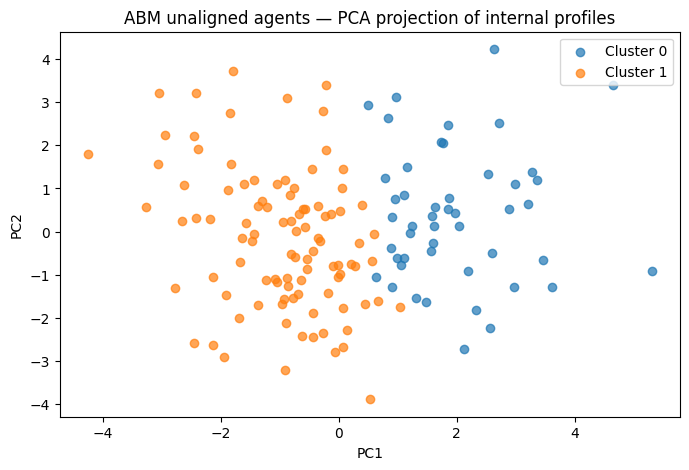

In [ ]:
def analyze_unaligned(k_range: range = range(2, 7)) -> dict[str, Any]:
    subset = AGENTS.loc[AGENTS['current_state_norm'].eq('Unaligned')].copy()
    print(f'ABM unaligned agents: {len(subset)} ({len(subset)/len(AGENTS):.1%})')
    destination = subset['llm_final_state_norm'].value_counts().reindex(STATE_ORDER, fill_value=0).rename_axis('llm_destination').reset_index(name='agents')
    destination['share'] = destination['agents'] / len(subset)
    display(destination)

    features = safe_numeric_columns(subset, [
        'confidence', 'uncertainty', 'fatigue', 'mobilisation', 'decision_confidence',
        'state_position', 'state_blank_vote_propensity', 'state_abstention_propensity',
        'total_information_dose', 'misinformation_dose', 'contested_semantic_dose',
        'profile_institutional_trust', 'profile_source_scepticism',
        'profile_economic_vulnerability', 'profile_conflict_memory',
        'profile_order_orientation', 'profile_negotiation_orientation',
        'profile_economic_orientation', 'profile_cultural_progressivism',
    ])
    cluster_output = {}
    if SKLEARN_AVAILABLE and len(features) >= 3:
        X = subset[features].apply(pd.to_numeric, errors='coerce')
        X = X.fillna(X.median())
        Xs = StandardScaler().fit_transform(X)
        candidates = []
        for k in k_range:
            labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(Xs)
            candidates.append((k, silhouette_score(Xs, labels)))
        scores = pd.DataFrame(candidates, columns=['k', 'silhouette']).sort_values('silhouette', ascending=False)
        best_k = int(scores.iloc[0]['k'])
        km = KMeans(n_clusters=best_k, random_state=42, n_init=30)
        subset['cluster'] = km.fit_predict(Xs)
        profile = subset.groupby('cluster')[features].mean().T
        profile['range'] = profile.max(axis=1) - profile.min(axis=1)
        profile = profile.sort_values('range', ascending=False)
        transitions = pd.crosstab(subset['cluster'], subset['llm_final_state_norm'], normalize='index').reindex(columns=STATE_ORDER, fill_value=0)
        coords = PCA(n_components=2, random_state=42).fit_transform(Xs)
        plot_df = pd.DataFrame({'PC1': coords[:,0], 'PC2': coords[:,1], 'cluster': subset['cluster'].astype(str), 'destination': subset['llm_final_state_norm'].values})
        display(Markdown(f'**Number of clusters selected by silhouette: {best_k}**'))
        display(scores)
        display(profile.head(15))
        display(transitions)
        fig, ax = plt.subplots(figsize=(8, 5))
        for name, group in plot_df.groupby('cluster'):
            ax.scatter(group['PC1'], group['PC2'], label=f'Cluster {name}', alpha=.7)
        ax.set_title('ABM unaligned agents — PCA projection of internal profiles')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
        plt.show()
        cluster_output = {'scores': scores, 'profile': profile, 'transitions': transitions, 'plot': plot_df, 'subset': subset}
    return {'destination': destination, **cluster_output}

NONALIGNED_ANALYSIS = analyze_unaligned()

## 10. Q04 — Information entropy, contradiction, and daily pressure

,date,active_signals,new_signals,motif_entropy,source_entropy,direction_entropy,frame_entropy,legal_entropy,candidate_entropy,composite_entropy,contradiction,novelty,volume_normalised,risk,information_pressure
19,2026-06-20,87,20,0.971397,0.920657,0.892352,0.969350,0.793843,0.914905,0.910417,0.423795,0.229885,1.000000,0.191684,0.658487
15,2026-06-16,47,17,0.962628,0.901552,0.908003,0.962628,0.861894,0.887321,0.914004,0.529504,0.361702,0.540230,0.214536,0.637507
17,2026-06-18,74,22,0.971367,0.932489,0.876015,0.969128,0.817138,0.863341,0.904913,0.372235,0.297297,0.850575,0.192977,0.634510
16,2026-06-17,58,16,0.967295,0.922895,0.891241,0.964714,0.853302,0.855844,0.909215,0.401713,0.275862,0.666667,0.212391,0.615406
5,2026-06-06,63,7,0.963870,0.960614,0.911180,0.964087,0.785369,0.862926,0.908008,0.494568,0.111111,0.724138,0.166049,0.613817
18,2026-06-19,71,4,0.971856,0.931626,0.875153,0.968937,0.799604,0.968500,0.919279,0.392372,0.056338,0.816092,0.199009,0.606613
14,2026-06-15,37,8,0.957522,0.878185,0.945612,0.955454,0.874258,0.905732,0.919460,0.525124,0.216216,0.425287,0.167680,0.597777
6,2026-06-07,50,5,0.955480,0.952964,0.905664,0.955480,0.801738,0.874123,0.907575,0.516167,0.100000,0.574713,0.170809,0.595955
12,2026-06-13,36,7,0.957728,0.893574,0.855617,0.957728,0.861779,0.799860,0.887714,0.524435,0.194444,0.413793,0.210653,0.583946
0,2026-06-01,24,18,0.994309,0.788492,0.842736,0.994309,0.791076,0.972753,0.897279,0.234540,0.750000,0.275862,0.125255,0.579911


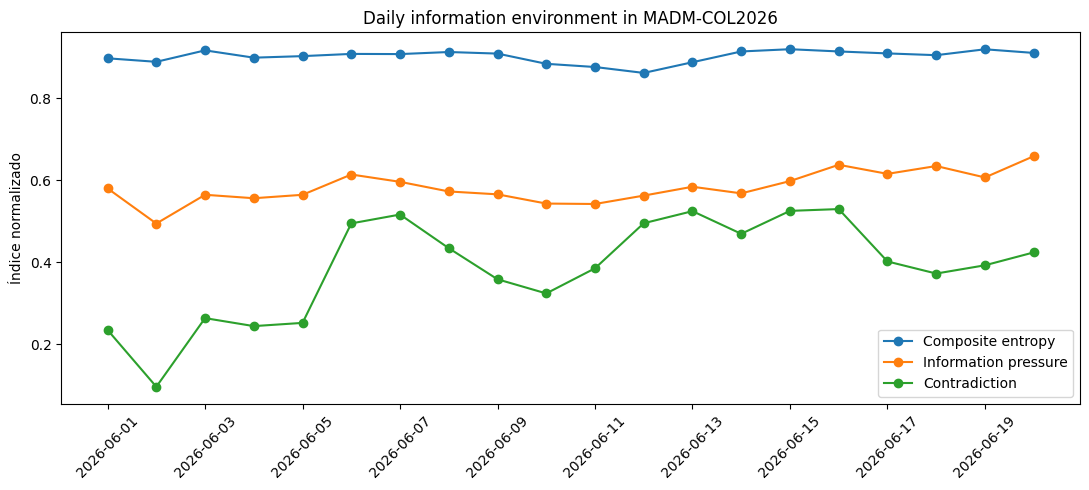

In [ ]:
def weighted_normalised_entropy(values: pd.Series, weights: pd.Series) -> float:
    frame = pd.DataFrame({'value': values.fillna('missing').astype(str), 'weight': pd.to_numeric(weights, errors='coerce').fillna(0.0)})
    grouped = frame.groupby('value')['weight'].sum()
    if grouped.sum() <= 0:
        p = frame['value'].value_counts(normalize=True)
    else:
        p = grouped / grouped.sum()
    if len(p) <= 1:
        return 0.0
    h = -float(np.sum(p * np.log(p)))
    return h / math.log(len(p))


def contradiction_index(active: pd.DataFrame, weight_col: str) -> float:
    directional = active.loc[active['direccion'].isin(['positiva', 'negativa'])]
    scores = []
    for _, group in directional.groupby('candidate_scope'):
        pos = group.loc[group['direccion'].eq('positiva'), weight_col].sum()
        neg = group.loc[group['direccion'].eq('negativa'), weight_col].sum()
        if pos + neg > 0:
            scores.append(2 * min(pos, neg) / (pos + neg))
    return float(np.mean(scores)) if scores else 0.0


def compute_daily_information_environment(window_days: int = ACTIVE_SIGNAL_WINDOW_DAYS) -> pd.DataFrame:
    if 'signals_master' not in DATA:
        raise RuntimeError('signals_master is not loaded.')
    sig = DATA['signals_master'].copy()
    sig['fecha'] = pd.to_datetime(sig['fecha'])
    if 'observation_role' in sig:
        sig = sig.loc[sig['observation_role'].eq('canonical_signal')].copy()
    weight_col = 'model_sampling_weight' if 'model_sampling_weight' in sig else 'intensidad'
    sig[weight_col] = pd.to_numeric(sig[weight_col], errors='coerce').fillna(1.0)
    rows = []
    max_active = 1
    cache = {}
    for date in pd.date_range(SIMULATION_START, SIMULATION_END):
        start = date - pd.Timedelta(days=window_days-1)
        active = sig.loc[sig['fecha'].between(start, date)].copy()
        cache[date] = active
        max_active = max(max_active, len(active))
    for date, active in cache.items():
        dimensions = {
            'motif_entropy': weighted_normalised_entropy(active['motif_primary'], active[weight_col]),
            'source_entropy': weighted_normalised_entropy(active['source_category'], active[weight_col]),
            'direction_entropy': weighted_normalised_entropy(active['direccion'], active[weight_col]),
            'frame_entropy': weighted_normalised_entropy(active['frame'], active[weight_col]),
            'legal_entropy': weighted_normalised_entropy(active['legal_status'], active[weight_col]),
            'candidate_entropy': weighted_normalised_entropy(active['candidate_scope'], active[weight_col]),
        }
        composite = float(np.mean(list(dimensions.values())))
        contradiction = contradiction_index(active, weight_col)
        today_count = int((active['fecha'] == date).sum())
        novelty = today_count / max(len(active), 1)
        volume = len(active) / max_active
        risk = np.average(pd.to_numeric(active['riesgo_desinformacion'], errors='coerce').fillna(0), weights=active[weight_col]) if len(active) else 0.0
        pressure = 0.42*composite + 0.20*contradiction + 0.14*novelty + 0.14*volume + 0.10*risk
        rows.append({'date': date, 'active_signals': len(active), 'new_signals': today_count, **dimensions,
                     'composite_entropy': composite, 'contradiction': contradiction, 'novelty': novelty,
                     'volume_normalised': volume, 'risk': risk, 'information_pressure': pressure})
    return pd.DataFrame(rows)

DAILY_INFORMATION = compute_daily_information_environment()
display(DAILY_INFORMATION.sort_values('information_pressure', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(DAILY_INFORMATION['date'], DAILY_INFORMATION['composite_entropy'], marker='o', label='Composite entropy')
ax.plot(DAILY_INFORMATION['date'], DAILY_INFORMATION['information_pressure'], marker='o', label='Information pressure')
ax.plot(DAILY_INFORMATION['date'], DAILY_INFORMATION['contradiction'], marker='o', label='Contradiction')
ax.set_title('Daily information environment in MADM-COL2026')
ax.set_ylabel('Índice normalizado')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def events_near_entropy_peaks(top_days: int = 5, top_events_per_day: int = 8) -> pd.DataFrame:
    sig = DATA['signals_master'].copy()
    sig['fecha'] = pd.to_datetime(sig['fecha'])
    if 'observation_role' in sig:
        sig = sig.loc[sig['observation_role'].eq('canonical_signal')]
    peaks = DAILY_INFORMATION.nlargest(top_days, 'information_pressure')[['date', 'information_pressure', 'composite_entropy', 'contradiction']]
    rows = []
    for _, peak in peaks.iterrows():
        active_start = peak['date'] - pd.Timedelta(days=ACTIVE_SIGNAL_WINDOW_DAYS-1)
        active = sig.loc[sig['fecha'].between(active_start, peak['date'])].copy()
        active['recency_days'] = (peak['date'] - active['fecha']).dt.days
        active['event_priority'] = (
            pd.to_numeric(active.get('model_sampling_weight', 1), errors='coerce').fillna(1)
            * pd.to_numeric(active['intensidad'], errors='coerce').fillna(0)
            * (1 - pd.to_numeric(active['riesgo_desinformacion'], errors='coerce').fillna(0)*0.25)
            * np.power(0.85, active['recency_days'])
        )
        for _, event in active.nlargest(top_events_per_day, 'event_priority').iterrows():
            rows.append({
                'peak_date': peak['date'], 'information_pressure': peak['information_pressure'],
                'signal_date': event['fecha'], 'signal_id': event['id'], 'title': event['titulo'],
                'source_category': event['source_category'], 'motif': event['motif_primary'],
                'candidate': event['candidate_scope'], 'direction': event['direccion'],
                'misinformation_risk': event['riesgo_desinformacion'], 'event_priority': event['event_priority'],
            })
    result = pd.DataFrame(rows)
    display(result)
    return result

ENTROPY_PEAK_EVENTS = events_near_entropy_peaks()

,peak_date,information_pressure,signal_date,signal_id,title,source_category,motif,candidate,direction,misinformation_risk,event_priority
0,2026-06-20,0.658487,2026-06-20,S184,Todo está listo para elegir presidente entre De la Espriella e Iván Cepeda,regional,alistamiento_electoral,AMBOS,contexto,0.06,2.127600
1,2026-06-20,0.658487,2026-06-20,S199,Así está el ambiente previo a la elección entre Cepeda y De la Espriella,regional,ambiente_preelectoral,AMBOS,contexto,0.12,2.066100
2,2026-06-20,0.658487,2026-06-20,S187,La sombra del paramilitarismo sobre la segunda vuelta presidencial de Colombia,internacional,paramilitarismo_y_memoria,AMBOS,negativa,0.12,1.386407
3,2026-06-20,0.658487,2026-06-20,S189,Perfil de De la Espriella: el showman que promete una ofensiva contra la izquierda,internacional,estilo_confrontativo,De la Espriella,negativa,0.12,1.370471
4,2026-06-20,0.658487,2026-06-20,S188,De la Espriella advierte al Congreso y Cepeda llama a la convivencia antes de la votación,internacional,orden_institucional_y_convivencia,AMBOS,mixta,0.10,1.361518
5,2026-06-20,0.658487,2026-06-20,S186,Colombia 21J: entre la mano de hierro de De la Espriella y la defensa de la paz de Cepeda,internacional,seguridad_vs_paz,AMBOS,mixta,0.10,1.329482
6,2026-06-20,0.658487,2026-06-20,S183,"Segunda vuelta: horarios, ley seca, cómo votar y tarjeta electoral",internacional,reglas_jornada_y_voto_blanco,AMBOS,contexto,0.05,1.281634
7,2026-06-20,0.658487,2026-06-20,S196,Récord de votantes y tensión entre colombianos en España durante la segunda vuelta,internacional,movilizacion_voto_exterior,AMBOS,mixta,0.08,1.271900
8,2026-06-16,0.637507,2026-06-16,S174,El Colombiano verifica una acusación falsa difundida en redes dentro de la campaña presidencial,regional,fake_news_imagenes_falsas,AMBOS,contexto,0.72,2.066400
9,2026-06-16,0.637507,2026-06-14,S175,El Colombiano describe cierres de campaña con discursos duros y acusaciones cruzadas,regional,cierres_buga_soledad,AMBOS,mixta,0.08,1.741803


## 11. Q05 — Multidimensional event ranking: decision, reinforcement, uncertainty, blank vote, and abstention

In [ ]:
def prepare_attribution_log() -> pd.DataFrame:
    if 'decision_attribution_log' not in DATA:
        raise RuntimeError('Load the historical ZIP to access decision_attribution_log.')
    log = DATA['decision_attribution_log'].copy()
    numeric_cols = [
        'position_before','position_after','position_delta','uncertainty_delta','blank_delta',
        'abstention_delta','attribution_score','effect_magnitude'
    ]
    for col in numeric_cols:
        log[col] = pd.to_numeric(log[col], errors='coerce').fillna(0.0)
    log['reinforcement'] = (
        log['position_before'].ne(0)
        & np.sign(log['position_before']).eq(np.sign(log['position_after']))
        & log['position_after'].abs().gt(log['position_before'].abs())
    )
    log['toward_cepeda'] = -log['position_delta']
    log['toward_de_la_espriella'] = log['position_delta']
    log['abs_position_delta'] = log['position_delta'].abs()
    return log

ATTRIBUTIONS = prepare_attribution_log()


def event_ranking(outcome: str = 'overall', top_n: int = 20) -> pd.DataFrame:
    group_cols = ['signal_id','signal_title','source_category','motif_key','issue_family','candidate_affected','narrative_direction']
    agg = ATTRIBUTIONS.groupby(group_cols, dropna=False).agg(
        exposures=('receiver_agent_id','size'),
        unique_agents=('receiver_agent_id','nunique'),
        total_effect=('effect_magnitude','sum'),
        mean_effect=('effect_magnitude','mean'),
        total_abs_position=('abs_position_delta','sum'),
        toward_cepeda=('toward_cepeda','sum'),
        toward_de_la_espriella=('toward_de_la_espriella','sum'),
        uncertainty_gain=('uncertainty_delta','sum'),
        blank_gain=('blank_delta','sum'),
        abstention_gain=('abstention_delta','sum'),
        reinforcement_count=('reinforcement','sum'),
        attribution_score=('attribution_score','sum'),
    ).reset_index()
    outcome_map = {
        'overall': ['unique_agents','total_effect','total_abs_position','attribution_score'],
        'cepeda': ['toward_cepeda','unique_agents','total_effect'],
        'de_la_espriella': ['toward_de_la_espriella','unique_agents','total_effect'],
        'blank': ['blank_gain','unique_agents','total_effect'],
        'abstention': ['abstention_gain','unique_agents','total_effect'],
        'uncertainty': ['uncertainty_gain','unique_agents','total_effect'],
        'reinforcement': ['reinforcement_count','unique_agents','total_abs_position'],
    }
    metrics = outcome_map.get(outcome.lower())
    if metrics is None:
        raise ValueError(f'Unrecognized outcome. Use one of {list(outcome_map)}')
    scores = []
    for metric in metrics:
        values = agg[metric]
        if metric in ['toward_cepeda','toward_de_la_espriella','blank_gain','abstention_gain','uncertainty_gain']:
            values = values.clip(lower=0)
        scores.append(values.rank(pct=True))
    agg['composite_rank_score'] = np.mean(scores, axis=0)
    result = agg.sort_values(['composite_rank_score', metrics[0]], ascending=False).head(top_n)
    display(result)
    return result

RANK_OVERALL = event_ranking('overall', 20)

,signal_id,signal_title,source_category,motif_key,issue_family,candidate_affected,narrative_direction,exposures,unique_agents,total_effect,mean_effect,total_abs_position,toward_cepeda,toward_de_la_espriella,uncertainty_gain,blank_gain,abstention_gain,reinforcement_count,attribution_score,composite_rank_score
12,S014,RTVC reporta respaldo de comunidad K-pop y Army Colombia a Cepeda y Aída Quilcué,medio_publico,kpop_army_movilizion_juvenil,movilizacion,Cepeda,positiva,482,390,0.605312,0.001256,0.362792,0.362792,-0.362792,0.242520,0.0,0.0,173,28.009327,0.988806
166,S169,Petro advierte a Trump sobre injerencia y apoyos extranjeros en la campaña,medio_publico,injerencia_trump,politica_exterior,De la Espriella,negativa,460,379,0.784745,0.001706,0.516448,0.516448,-0.516448,0.268297,0.0,0.0,162,26.713108,0.988806
173,S176,De la Espriella afirma que con Cepeda estaría en riesgo la continuidad de las elecciones,regional,riesgo_continuidad_electoral,instituciones,Cepeda,negativa,481,396,0.433267,0.000901,0.198808,-0.198808,0.198808,0.234458,0.0,0.0,182,28.542221,0.981343
57,S060,Trump respalda públicamente a Abelardo de la Espriella rumbo a la segunda vuelta,internacional,respaldo_trump,politica_exterior,De la Espriella,positiva,334,301,0.405796,0.001215,0.277436,-0.277436,0.277436,0.128360,0.0,0.0,133,19.351676,0.967662
165,S168,Cepeda alerta sobre información de un presunto montaje de autoatentado contra De la Espriella,medio_publico,presunto_autoatentado,seguridad,De la Espriella,negativa,531,426,0.485657,0.000915,0.108938,0.108938,-0.108938,0.376719,0.0,0.0,187,31.663978,0.966418
10,S012,La Silla reporta que Kpopers entran a campaña para impulsar a Cepeda,alternativo_investigativo,kpopers_con_cepeda,movilizacion,Cepeda,positiva,297,260,0.435257,0.001466,0.255244,0.255244,-0.255244,0.180013,0.0,0.0,114,16.859685,0.958955
168,S171,La Silla Vacía analiza las dificultades de Cepeda para conquistar al centro,alternativo_investigativo,dificultad_conquista_centro,otros,Cepeda,negativa,290,250,0.410935,0.001417,0.307870,-0.307870,0.307870,0.103065,0.0,0.0,116,17.096037,0.956468
169,S172,Cuestión Pública investiga un posible mecanismo multinivel y presión sobre contratistas en la campaña de De la Espriella,alternativo_investigativo,red_referidos_y_contratistas,corrupcion,De la Espriella,negativa,324,281,0.426653,0.001317,0.183779,0.183779,-0.183779,0.242874,0.0,0.0,123,19.013592,0.956468
11,S013,AtlasIntel reporta ventaja de De la Espriella sobre Cepeda en segunda vuelta,alternativo_investigativo,ventaja_encuestas,otros,De la Espriella,positiva,307,272,0.323209,0.001053,0.185139,-0.185139,0.185139,0.138069,0.0,0.0,130,18.144634,0.949005
32,S035,AtlasIntel muestra a De la Espriella casi ocho puntos arriba de Cepeda,alternativo_investigativo,atlas_ventaja_ocho_puntos,otros,De la Espriella,positiva,270,241,0.270928,0.001003,0.153610,-0.153610,0.153610,0.117317,0.0,0.0,110,16.696138,0.930348


## 12. Q06 — Ranking of media, source categories, and input channels

In [ ]:
def source_ranking(by: str = 'source_category', top_n: int = 30) -> pd.DataFrame:
    if by not in ATTRIBUTIONS.columns:
        raise KeyError(by)
    result = ATTRIBUTIONS.groupby(by, dropna=False).agg(
        exposures=('receiver_agent_id','size'),
        unique_agents=('receiver_agent_id','nunique'),
        total_effect=('effect_magnitude','sum'),
        mean_effect=('effect_magnitude','mean'),
        total_abs_position=('abs_position_delta','sum'),
        toward_cepeda=('toward_cepeda','sum'),
        toward_de_la_espriella=('toward_de_la_espriella','sum'),
        uncertainty_gain=('uncertainty_delta','sum'),
        blank_gain=('blank_delta','sum'),
        abstention_gain=('abstention_delta','sum'),
        reinforcement_count=('reinforcement','sum'),
    ).reset_index()
    metrics = ['unique_agents','total_effect','total_abs_position','reinforcement_count']
    result['composite_rank_score'] = np.mean([result[m].rank(pct=True) for m in metrics], axis=0)
    result = result.sort_values('composite_rank_score', ascending=False).head(top_n)
    display(result)
    return result

SOURCE_RANKING = source_ranking('source_category')
CHANNEL_RANKING = source_ranking('exposure_channel')

,source_category,exposures,unique_agents,total_effect,mean_effect,total_abs_position,toward_cepeda,toward_de_la_espriella,uncertainty_gain,blank_gain,abstention_gain,reinforcement_count,composite_rank_score
8,television,3460,978,3.214967,0.000929,1.620581,0.451081,-0.451081,1.594386,0.000000,0.00000,660,0.888889
0,alternativo_investigativo,3155,965,3.446046,0.001092,1.346921,-0.468875,0.468875,1.397461,0.478055,0.00000,814,0.833333
5,radio,3216,968,3.098884,0.000964,1.560027,0.191622,-0.191622,1.538856,0.000000,0.00000,630,0.777778
7,social_oficial,2563,948,2.530771,0.000987,1.212876,-0.251352,0.251352,0.812599,0.450806,0.05449,890,0.722222
2,medio_publico,2247,899,4.376924,0.001948,0.988178,0.988178,-0.988178,1.115522,2.273224,0.00000,522,0.666667
3,otro,1836,860,1.535122,0.000836,0.712288,0.396677,-0.396677,0.822834,0.000000,0.00000,432,0.402778
4,prensa_privada,1938,860,1.457262,0.000752,0.543067,0.132184,-0.132184,0.914195,0.000000,0.00000,485,0.375000
1,internacional,1501,785,1.095252,0.000730,0.517137,-0.362265,0.362265,0.578115,0.000000,0.00000,248,0.194444
6,regional,1165,689,1.299273,0.001115,0.198808,-0.198808,0.198808,1.100464,0.000000,0.00000,182,0.138889


,exposure_channel,exposures,unique_agents,total_effect,mean_effect,total_abs_position,toward_cepeda,toward_de_la_espriella,uncertainty_gain,blank_gain,abstention_gain,reinforcement_count,composite_rank_score
0,direct,20899,1000,22.036207,0.001054,8.686078,0.875978,-0.875978,9.871182,3.200867,0.054472,4823,1.0
1,peer,182,162,0.018294,0.000101,0.013805,0.002464,-0.002464,0.003252,0.001219,0.000018,40,0.5


## 13. Q07 — Proposals versus symbols, controversies, actors, and events

In [ ]:
CONTENT_PATTERNS = [
    ('desinformacion', r'fake|falso|desinform|fraude|suplant|ia generativa|documento no verific'),
    ('symbol_identity', r'camiseta|simbol|k.?pop|army|patria|rugido|lema|slogan|seleccion colombia'),
    ('national_international_actor_support', r'trump|milei|petro|respaldo|apoyo internacional|expresidente|presidente'),
    ('propuesta_programatica', r'propuesta|programa|plan de gobierno|reforma|politica publica|empleo|economia|salud|educacion|seguridad|paz negociada|debate program'),
    ('controversia_ataque_escandalo', r'ataque|polemica|escandalo|denuncia|vandal|nazis|incendiar|paramilitar|amenaza|critica'),
    ('institucional_judicial', r'juez|tribunal|procurad|registrad|consejo nacional electoral|decision judicial|orden judicial'),
    ('poll_electoral_result', r'encuesta|intencion de voto|primera vuelta|resultado electoral|mapa departamental'),
    ('movilizacion_campana', r'moviliza|manifestacion|concentracion|evento de campana|voluntarios|referidos'),
]


def classify_content_nature(row: pd.Series) -> str:
    text = normalise_text(' '.join(str(row.get(c,'')) for c in ['signal_title','motif_key','issue_family']))
    risk = float(row.get('misinformation_risk', 0) or 0)
    if risk >= 0.5:
        return 'desinformacion'
    for label, pattern in CONTENT_PATTERNS:
        if re.search(pattern, text):
            return label
    return 'otros_eventos'

ATTRIBUTIONS['content_nature'] = ATTRIBUTIONS.apply(classify_content_nature, axis=1)


def content_nature_ranking() -> pd.DataFrame:
    out = ATTRIBUTIONS.groupby('content_nature').agg(
        exposures=('receiver_agent_id','size'),
        unique_agents=('receiver_agent_id','nunique'),
        total_effect=('effect_magnitude','sum'),
        total_abs_position=('abs_position_delta','sum'),
        reinforcement_count=('reinforcement','sum'),
        uncertainty_gain=('uncertainty_delta','sum'),
        blank_gain=('blank_delta','sum'),
        abstention_gain=('abstention_delta','sum'),
    ).reset_index()
    out['effect_per_exposure'] = out['total_effect'] / out['exposures'].clip(lower=1)
    out = out.sort_values('total_effect', ascending=False)
    display(out)
    return out

CONTENT_NATURE = content_nature_ranking()

,content_nature,exposures,unique_agents,total_effect,total_abs_position,reinforcement_count,uncertainty_gain,blank_gain,abstention_gain,effect_per_exposure
8,symbol_identity,3002,969,5.815566,2.146934,998,1.395408,2.273224,0.000000,0.001937
5,otros_eventos,6099,998,4.957078,2.150515,1180,2.417537,0.165417,0.000000,0.000813
7,propuesta_programatica,4249,990,3.185103,1.191103,859,1.994000,0.000000,0.000000,0.000750
4,national_international_actor_support,2368,918,2.515063,1.416376,711,1.032041,0.040207,0.026439,0.001062
6,poll_electoral_result,1755,828,1.861289,0.442910,275,0.716793,0.701587,0.000000,0.001061
3,movilizacion_campana,2050,883,1.853591,0.989030,566,0.864562,0.000000,0.000000,0.000904
1,desinformacion,728,539,1.170673,0.038650,75,1.082322,0.021650,0.028051,0.001608
0,controversia_ataque_escandalo,646,489,0.621743,0.324367,199,0.297376,0.000000,0.000000,0.000962
2,institucional_judicial,184,172,0.074394,0.000000,0,0.074394,0.000000,0.000000,0.000404


## 14. Q09 — False or unverified information, misinformation risk, and exposure dose

In [ ]:
def misinformation_analysis(threshold: float = 0.30) -> dict[str, Any]:
    sig = DATA['signals_master'].copy()
    sig['riesgo_desinformacion'] = pd.to_numeric(sig['riesgo_desinformacion'], errors='coerce').fillna(0)
    risky = sig.loc[sig['riesgo_desinformacion'] >= threshold].copy()
    risky = risky.sort_values('riesgo_desinformacion', ascending=False)
    log_risky = ATTRIBUTIONS.loc[ATTRIBUTIONS['signal_id'].isin(risky['id'])]
    event = log_risky.groupby(['signal_id','signal_title']).agg(
        exposures=('receiver_agent_id','size'), unique_agents=('receiver_agent_id','nunique'),
        total_effect=('effect_magnitude','sum'), uncertainty_gain=('uncertainty_delta','sum'),
        total_abs_position=('abs_position_delta','sum'),
    ).reset_index().sort_values('uncertainty_gain', ascending=False)
    dose_by_state = pd.DataFrame()
    if 'misinformation_dose' in AGENTS:
        dose_by_state = AGENTS.groupby('llm_final_state_norm')['misinformation_dose'].agg(['count','mean','median','std']).reindex(STATE_ORDER)
    print(f'Signals with risk >= {threshold:.2f}: {len(risky)}')
    display(risky[['id','fecha','titulo','fuente','source_category','riesgo_desinformacion','legal_status']].head(30))
    display(event.head(30))
    display(dose_by_state)
    return {'signals': risky, 'events': event, 'dose_by_state': dose_by_state}

MISINFORMATION = misinformation_analysis()

Signals with risk >= 0.30: 22


,id,fecha,titulo,fuente,source_category,riesgo_desinformacion,legal_status
190,S191,2026-06-20,Verifican que una imagen de la Selección Colombia fue manipulada con IA para darle carga política,Infobae Colombia,prensa_privada,0.94,verificacion_periodistica
189,S190,2026-06-20,Luis Alberto Posada denuncia videos con IA que simulan apoyos políticos,Tropicana,radio,0.92,desmentido_publico
173,S174,2026-06-16,El Colombiano verifica una acusación falsa difundida en redes dentro de la campaña presidencial,El Colombiano,regional,0.72,hecho_reportado
140,S141,2026-06-03,Publicación oficial en X de De la Espriella: Afirma que Petro y Cepeda intentarían cometer fraude electoral.,X oficial — @ABDELAESPRIELLA,social_oficial,0.70,alegacion_no_probada
153,S154,2026-06-17,Publicación oficial en X de De la Espriella: Afirma que Petro habría ordenado cesar operaciones de la fuerza pública y llama a votar masivamente.,X oficial — @ABDELAESPRIELLA,social_oficial,0.68,alegacion_no_probada
167,S168,2026-06-08,Cepeda alerta sobre información de un presunto montaje de autoatentado contra De la Espriella,RTVC Noticias,medio_publico,0.64,alegacion_no_probada
125,S126,2026-06-08,Publicación oficial en X de Cepeda: Anuncia que entregará a autoridades información recibida sobre un supuesto montaje de autoatentado en la campaña rival.,X oficial — @IvanCepedaCast,social_oficial,0.62,alegacion_no_probada
146,S147,2026-06-11,Publicación oficial en X de De la Espriella: Retoma una denuncia pública sobre supuesta narcopolítica.,X oficial — @ABDELAESPRIELLA,social_oficial,0.62,alegacion_no_probada
138,S139,2026-06-02,Publicación oficial en X de De la Espriella: Afirma que circula desinformación y que habría sido modificado un software relacionado con el proceso.,X oficial — @ABDELAESPRIELLA,social_oficial,0.60,alegacion_no_probada
91,S053,2026-06-17,"El País describe clima electoral asfixiante con polarización, ataques e imágenes manipuladas",El País,otro,0.60,analisis_periodistico


,signal_id,signal_title,exposures,unique_agents,total_effect,uncertainty_gain,total_abs_position
18,S174,El Colombiano verifica una acusación falsa difundida en redes dentro de la campaña presidencial,265,243,0.648722,0.648722,0.000000
16,S168,Cepeda alerta sobre información de un presunto montaje de autoatentado contra De la Espriella,531,426,0.485657,0.376719,0.108938
17,S172,Cuestión Pública investiga un posible mecanismo multinivel y presión sobre contratistas en la campaña de De la Espriella,324,281,0.426653,0.242874,0.183779
19,S176,De la Espriella afirma que con Cepeda estaría en riesgo la continuidad de las elecciones,481,396,0.433267,0.234458,0.198808
21,S191,Verifican que una imagen de la Selección Colombia fue manipulada con IA para darle carga política,21,21,0.104669,0.104669,0.000000
0,S027,Shakira desmiente imagen que la vinculaba a campaña de Cepeda y dice que no respalda candidatos,78,75,0.108123,0.082222,0.025901
20,S190,Luis Alberto Posada denuncia videos con IA que simulan apoyos políticos,11,11,0.062196,0.062196,0.000000
10,S141,Publicación oficial en X de De la Espriella: Afirma que Petro y Cepeda intentarían cometer fraude electoral.,104,99,0.067627,0.054879,0.012748
8,S126,Publicación oficial en X de Cepeda: Anuncia que entregará a autoridades información recibida sobre un supuesto montaje de autoatentado en la campaña rival.,100,98,0.063101,0.048716,0.014385
11,S147,Publicación oficial en X de De la Espriella: Retoma una denuncia pública sobre supuesta narcopolítica.,88,85,0.063512,0.048672,0.014840


,count,mean,median,std
llm_final_state_norm,,,,
Cepeda,400,0.156110,0.151474,0.043502
De la Espriella,440,0.157382,0.150670,0.044398
Blank vote,45,0.151273,0.144084,0.043878
Unaligned,23,0.159217,0.156111,0.037658
Abstention,92,0.153483,0.145825,0.047628


## 15. Q10 — Decisive arguments: themes and discriminative vocabulary

In [ ]:
ARGUMENT_THEMES = explode_themes(AGENTS, 'decisive_argument', 'llm_final_state_norm')
display(ARGUMENT_THEMES.groupby('llm_final_state_norm').head(10))


def top_tfidf_terms_by_state(text_col: str = 'decisive_argument', top_n: int = 20) -> dict[str, pd.DataFrame]:
    if not SKLEARN_AVAILABLE:
        raise RuntimeError('scikit-learn is not available.')
    texts = AGENTS[text_col].fillna('').astype(str)
    vectorizer = TfidfVectorizer(
        max_features=5000, ngram_range=(1,2), min_df=3, max_df=.95,
        stop_words=['para','como','pero','porque','esta','este','estos','estas','con','sin','una','uno','unos','unas','que','del','las','los','por','más','muy','fue','son','se','su','sus','al','la','el','en','y','o','de'],
    )
    X = vectorizer.fit_transform(texts)
    terms = np.array(vectorizer.get_feature_names_out())
    outputs = {}
    for state in STATE_ORDER:
        mask = AGENTS['llm_final_state_norm'].eq(state).to_numpy()
        if mask.sum() == 0:
            continue
        group_mean = np.asarray(X[mask].mean(axis=0)).ravel()
        other_mean = np.asarray(X[~mask].mean(axis=0)).ravel()
        contrast = group_mean - other_mean
        idx = np.argsort(contrast)[::-1][:top_n]
        outputs[state] = pd.DataFrame({'term': terms[idx], 'contrast_tfidf': contrast[idx], 'group_mean': group_mean[idx]})
        display(Markdown(f'### {state}'))
        display(outputs[state])
    return outputs

TFIDF_TERMS = top_tfidf_terms_by_state()

,llm_final_state_norm,theme,mentions,share
7,Abstention,uncertainty_evidence,92,0.363636
8,Abstention,voting_participation,92,0.363636
6,Abstention,trust_credibility,45,0.177866
2,Abstention,identity_symbols,8,0.031621
1,Abstention,external_actor,4,0.015810
4,Abstention,rights_welfare,4,0.015810
0,Abstention,corruption_integrity,3,0.011858
5,Abstention,security_order,3,0.011858
3,Abstention,reject_both,2,0.007905
17,Blank vote,uncertainty_evidence,45,0.300000


### Cepeda

,term,contrast_tfidf,group_mean
0,option_a,0.019603,0.061460
1,option_b,0.017808,0.060910
2,negativa,0.017674,0.019244
3,provienen,0.014980,0.023017
4,provienen fuentes,0.014885,0.021410
5,fuentes,0.014762,0.025283
6,34,0.013432,0.013812
7,heurística agente,0.013243,0.018567
8,inicial heurística,0.013166,0.023174
9,posición inicial,0.013068,0.024162


### De la Espriella

,term,contrast_tfidf,group_mean
0,señales negativas,0.022741,0.036108
1,negativas,0.022653,0.036744
2,orden,0.021168,0.026553
3,pequeños,0.019515,0.025531
4,9999,0.019061,0.030488
5,deltas,0.018538,0.028350
6,preferencia,0.017978,0.030994
7,revertir preferencia,0.017740,0.022672
8,posición 9999,0.017481,0.027130
9,negativos,0.017397,0.018010


...

,term,contrast_tfidf,group_mean
0,blanco,0.080464,0.102241
1,voto blanco,0.079130,0.100848
2,voto,0.076528,0.099485
3,supera,0.066378,0.069958
4,incertidumbre,0.054688,0.071218
5,cualquier,0.050658,0.052195
6,supera confianza,0.050097,0.050097
7,alta incertidumbre,0.049625,0.056403
8,confianza cualquier,0.045930,0.047102
9,fatiga,0.045679,0.057448


### Unaligned

,term,contrast_tfidf,group_mean
0,prácticamente,0.087041,0.093532
1,es prácticamente,0.086515,0.091464
2,prácticamente neutral,0.086094,0.091081
3,posición agente,0.076399,0.086698
4,ninguna,0.072184,0.080852
5,neutral,0.068408,0.078354
6,agente es,0.059419,0.072001
7,fatiga elevada,0.055645,0.062152
8,fatiga,0.054335,0.066910
9,incertidumbre,0.054026,0.071775


### Abstention

,term,contrast_tfidf,group_mean
0,propensión abstención,0.093207,0.095176
1,abstención,0.084964,0.094814
2,fatiga,0.059698,0.068031
3,incertidumbre,0.057752,0.071430
4,débiles,0.054970,0.056611
5,presenta,0.054238,0.056192
6,agente presenta,0.053815,0.055659
7,elevada,0.048017,0.055968
8,ningún,0.047208,0.049091
9,neutral,0.047144,0.054325


## 16. Q11 — Structured emotion, tone, and local lexical sentiment

,agents,mean_lexical_sentiment,median_lexical_sentiment,mean_decision_confidence,mean_uncertainty
llm_final_state_norm,,,,,
Cepeda,400,0.000284,0.0,0.674798,0.462880
De la Espriella,440,0.009225,0.0,0.686884,0.455946
Blank vote,45,-0.007342,0.0,0.333778,0.708166
Unaligned,23,-0.023052,0.0,0.244130,0.719753
Abstention,92,0.017195,0.0,0.224239,0.749917


dominant_emotion,acusacion,alarma,alerta,alivio,apertura,autoridad,cercania,certeza,confianza,confianza_cautela,confianza_cautelosa,confrontacion,controversia,conviccion,convicción,definicion,desaprobacion,desconfianza,determinacion,determinación,duda,entusiasmo,esperanza,euforia,evaluacion,expectativa,fatiga,firmeza,identidad,incertidumbre,indignacion,miedo,moderacion,movilizacion,movilización,pragmatismo,presion,sospecha,temor,tension,urgencia,validacion,validacion_judicial
llm_final_state_norm,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cepeda,0.000000,0.012500,0.045000,0.000000,0.0025,0.000000,0.0025,0.197500,0.160000,0.002500,0.0025,0.000000,0.000000,0.020000,0.007500,0.007500,0.000000,0.020000,0.010000,0.002500,0.005000,0.000000,0.165000,0.000000,0.030000,0.012500,0.002500,0.002500,0.000000,0.097500,0.017500,0.000000,0.0025,0.020,0.002500,0.000000,0.05,0.040000,0.005000,0.005000,0.017500,0.032500,0.000000
De la Espriella,0.002273,0.000000,0.034091,0.002273,0.0000,0.004545,0.0000,0.227273,0.302273,0.004545,0.0000,0.006818,0.002273,0.004545,0.002273,0.009091,0.004545,0.013636,0.009091,0.006818,0.002273,0.002273,0.009091,0.002273,0.068182,0.018182,0.000000,0.009091,0.004545,0.084091,0.020455,0.004545,0.0000,0.025,0.002273,0.002273,0.00,0.022727,0.002273,0.002273,0.006818,0.072727,0.002273
Blank vote,0.000000,0.000000,0.044444,0.000000,0.0000,0.000000,0.0000,0.022222,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.088889,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.711111,0.000000,0.000000,0.0000,0.000,0.000000,0.000000,0.00,0.022222,0.000000,0.000000,0.000000,0.000000,0.000000
Unaligned,0.000000,0.000000,0.086957,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043478,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.826087,0.043478,0.000000,0.0000,0.000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Abstention,0.000000,0.021739,0.032609,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043478,0.086957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076087,0.000000,0.000000,0.739130,0.000000,0.000000,0.0000,0.000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


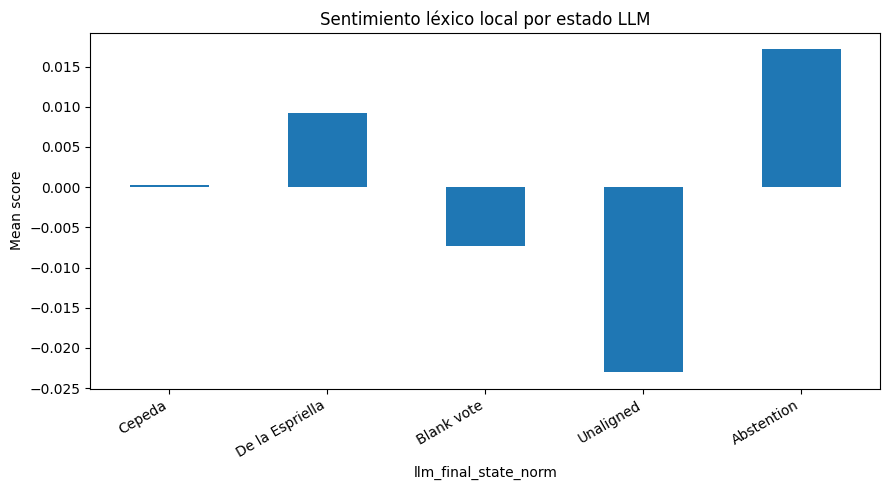

In [ ]:
POSITIVE_WORDS = set(normalise_text(x) for x in "confianza esperanza tranquilidad certeza progreso bienestar paz oportunidad responsable coherencia convincente seguro estable transparencia".split())
NEGATIVE_WORDS = set(normalise_text(x) for x in "miedo incertidumbre rechazo rabia enojo frustracion desconfianza escandalo corrupcion violencia amenaza confuso manipulacion cansancio".split())
INTENSIFIERS = {'muy', 'demasiado', 'totalmente', 'realmente', 'bastante'}


def lexical_sentiment(text: Any) -> float:
    tokens = re.findall(r'[a-záéíóúñü]+', normalise_text(text))
    score = 0.0
    for i, token in enumerate(tokens):
        multiplier = 1.5 if i > 0 and tokens[i-1] in INTENSIFIERS else 1.0
        if token in POSITIVE_WORDS:
            score += multiplier
        if token in NEGATIVE_WORDS:
            score -= multiplier
    return score / max(math.sqrt(len(tokens)), 1)

AGENTS['lexical_sentiment'] = AGENTS['social_media_post'].map(lexical_sentiment)
SENTIMENT_PROFILE = AGENTS.groupby('llm_final_state_norm').agg(
    agents=('agent_id','size'),
    mean_lexical_sentiment=('lexical_sentiment','mean'),
    median_lexical_sentiment=('lexical_sentiment','median'),
    mean_decision_confidence=('decision_confidence','mean'),
    mean_uncertainty=('uncertainty','mean'),
).reindex(STATE_ORDER)
EMOTION_PROFILE = pd.crosstab(AGENTS['llm_final_state_norm'], AGENTS['dominant_emotion'], normalize='index').reindex(STATE_ORDER)
display(SENTIMENT_PROFILE)
display(EMOTION_PROFILE)

fig, ax = plt.subplots(figsize=(9, 5))
SENTIMENT_PROFILE['mean_lexical_sentiment'].dropna().plot(kind='bar', ax=ax)
ax.set_title('Sentimiento léxico local por estado LLM')
ax.set_ylabel('Mean score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 17. Q12 — National and international actors

In [ ]:
ACTOR_PATTERNS = {
    'Gustavo Petro': r'\bpetro\b|presidente petro',
    'Donald Trump': r'\btrump\b',
    'Javier Milei': r'\bmilei\b',
    'Iván Cepeda': r'\bivan cepeda\b|\bcepeda\b',
    'Abelardo de la Espriella': r'abelardo|de la espriella',
    'Gobierno nacional': r'gobierno nacional|ministro|ministra|funcionario|presidencia',
    'Congreso y partidos': r'congreso|senador|representante|partido|pacto historico|centro democratico',
    'Armed actors': r'eln|farc|disidencia|guerrilla|paramilitar',
}


def actor_tags(text: Any) -> list[str]:
    t = normalise_text(text)
    return [actor for actor, pattern in ACTOR_PATTERNS.items() if re.search(pattern, t)]


def actor_influence_ranking() -> pd.DataFrame:
    rows = []
    for _, row in ATTRIBUTIONS.iterrows():
        text = f"{row.get('signal_title','')} {row.get('motif_key','')}"
        for actor in actor_tags(text):
            rows.append({
                'actor': actor, 'receiver_agent_id': row['receiver_agent_id'],
                'effect_magnitude': row['effect_magnitude'], 'position_delta': row['position_delta'],
                'uncertainty_delta': row['uncertainty_delta'], 'reinforcement': row['reinforcement'],
                'signal_id': row['signal_id'], 'final_state': row['final_state'],
            })
    tagged = pd.DataFrame(rows)
    if tagged.empty:
        return tagged
    ranking = tagged.groupby('actor').agg(
        exposures=('receiver_agent_id','size'), unique_agents=('receiver_agent_id','nunique'),
        signals=('signal_id','nunique'), total_effect=('effect_magnitude','sum'),
        net_position_delta=('position_delta','sum'), uncertainty_gain=('uncertainty_delta','sum'),
        reinforcement_count=('reinforcement','sum'),
    ).reset_index().sort_values('total_effect', ascending=False)
    display(ranking)
    return ranking

ACTOR_RANKING = actor_influence_ranking()

,actor,exposures,unique_agents,signals,total_effect,net_position_delta,uncertainty_gain,reinforcement_count
0,Abelardo de la Espriella,9910,1000,95,9.513078,1.916459,4.505826,3048
6,Iván Cepeda,8993,1000,83,8.451537,-1.563655,4.086179,2706
3,Donald Trump,1550,806,8,1.769682,0.044742,0.658464,496
5,Gustavo Petro,1137,704,8,1.179467,-0.465378,0.545302,268
4,Gobierno nacional,1390,771,9,1.177017,-0.055546,1.121471,9
1,Armed actors,1039,649,9,0.782237,-0.324190,0.458047,103
7,Javier Milei,63,63,2,0.093338,0.060340,0.032998,24
2,Congreso y partidos,283,246,3,0.089329,0.000000,0.089329,0


## 18. Q13 — Synthetic demographic and systemic profiles by state

In [ ]:
def demographic_state_profile(engine: str = 'LLM') -> dict[str, Any]:
    state_col = 'llm_final_state_norm' if engine.upper() == 'LLM' else 'current_state_norm'
    categorical = [
        'macro_region','department','generation_cohort','residential_stratum',
        'profile_sex_gender','profile_education_level','profile_occupation',
        'profile_employment_sector','profile_rurality','profile_digital_connectivity',
    ]
    numeric = safe_numeric_columns(AGENTS, [
        'profile_age','profile_institutional_trust','profile_source_scepticism',
        'profile_economic_vulnerability','profile_conflict_memory','profile_order_orientation',
        'profile_negotiation_orientation','profile_economic_orientation',
        'profile_cultural_progressivism','confidence','uncertainty','fatigue','mobilisation',
        'total_information_dose','misinformation_dose','decision_confidence',
    ])
    numeric_profile = AGENTS.groupby(state_col)[numeric].mean().reindex(STATE_ORDER).T
    categorical_profile_tables = {}
    for col in categorical:
        if col in AGENTS:
            categorical_profile_tables[col] = pd.crosstab(AGENTS[state_col], AGENTS[col], normalize='index').reindex(STATE_ORDER)
    display(Markdown('### Variables continuas'))
    display(numeric_profile)
    for col, table in categorical_profile_tables.items():
        display(Markdown(f'### {col}'))
        display(table)
    return {'numeric': numeric_profile, 'categorical': categorical_profile_tables}

DEMOGRAPHIC_PROFILE = demographic_state_profile('LLM')

### Variables continuas

llm_final_state_norm,Cepeda,De la Espriella,Blank vote,Unaligned,Abstention
profile_age,45.855000,46.290909,44.155556,44.173913,46.663043
profile_institutional_trust,0.459544,0.446506,0.415145,0.462791,0.403730
profile_source_scepticism,0.513886,0.489592,0.514532,0.443979,0.500319
profile_economic_vulnerability,0.559821,0.571001,0.602428,0.561489,0.590557
profile_conflict_memory,0.370479,0.390120,0.439529,0.335548,0.434085
profile_order_orientation,0.533004,0.547175,0.520894,0.511949,0.506678
profile_negotiation_orientation,0.474013,0.490610,0.460721,0.510200,0.462532
profile_economic_orientation,0.498755,0.503865,0.465880,0.515275,0.501386
profile_cultural_progressivism,0.492561,0.465398,0.448976,0.354890,0.472040
confidence,0.672165,0.683039,0.256729,0.245249,0.213624


### macro_region

macro_region,Antioquia_EjeCafetero,Bogota_Cundinamarca,Boyaca_Tolima_Huila,Caribe,Llanos_Orinoquia,Pacifico,Santanderes,Sur_Amazonia
llm_final_state_norm,,,,,,,,
Cepeda,0.192500,0.207500,0.085000,0.185000,0.057500,0.147500,0.075000,0.050000
De la Espriella,0.113636,0.218182,0.120455,0.163636,0.061364,0.140909,0.109091,0.072727
Blank vote,0.133333,0.066667,0.200000,0.200000,0.066667,0.155556,0.155556,0.022222
Unaligned,0.130435,0.347826,0.130435,0.173913,0.043478,0.130435,0.043478,0.000000
Abstention,0.076087,0.173913,0.097826,0.217391,0.065217,0.184783,0.130435,0.054348


### department

...

profile_employment_sector,cuidador,desempleado,estudiante,independiente_emprendimiento,pensionado,sector_informal,sector_privado_formal,sector_publico
llm_final_state_norm,,,,,,,,
Cepeda,0.040000,0.042500,0.065000,0.207500,0.040000,0.225000,0.272500,0.107500
De la Espriella,0.043182,0.027273,0.070455,0.204545,0.040909,0.265909,0.218182,0.129545
Blank vote,0.133333,0.044444,0.044444,0.177778,0.022222,0.200000,0.200000,0.177778
Unaligned,0.000000,0.000000,0.043478,0.173913,0.086957,0.130435,0.391304,0.173913
Abstention,0.086957,0.010870,0.097826,0.141304,0.032609,0.282609,0.250000,0.097826


### profile_rurality

profile_rurality,periferia_urbana,rural,urbano
llm_final_state_norm,,,
Cepeda,0.182500,0.140000,0.677500
De la Espriella,0.161364,0.150000,0.688636
Blank vote,0.244444,0.288889,0.466667
Unaligned,0.260870,0.173913,0.565217
Abstention,0.173913,0.239130,0.586957


### profile_digital_connectivity

profile_digital_connectivity,0.000000,0.026247,0.032549,0.033266,0.044770,0.045784,0.065324,0.074867,0.096315,0.107186,0.116711,0.131374,0.159949,0.161420,0.163026,0.181936,0.183024,0.185910,0.188466,0.191773,0.193307,0.195276,0.198297,0.201082,0.203208,0.205266,0.216776,0.217559,0.222178,0.224141,0.226013,0.226946,0.227651,0.227729,0.229179,0.229300,0.238424,0.239524,0.240367,0.244637,0.248489,0.249072,0.251236,0.257009,0.259374,0.263031,0.265484,0.270582,0.271636,0.271956,0.273592,0.273870,0.274676,0.275128,0.276587,0.278994,0.279288,0.281952,0.282359,0.286049,...,0.916066,0.917199,0.917256,0.923237,0.924796,0.924853,0.925228,0.926196,0.927120,0.927477,0.928349,0.929063,0.929558,0.930460,0.932346,0.933936,0.934285,0.934946,0.935226,0.937137,0.937277,0.940116,0.940445,0.941559,0.942454,0.943085,0.944189,0.944586,0.944955,0.947765,0.948423,0.948970,0.948983,0.949679,0.950252,0.953324,0.954179,0.957037,0.957661,0.957797,0.962497,0.963436,0.963491,0.967619,0.967883,0.968929,0.969595,0.970277,0.970647,0.977046,0.977241,0.978446,0.980169,0.981938,0.983274,0.995103,0.995532,0.996324,0.996551,1.000000
llm_final_state_norm,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cepeda,0.0025,0.000000,0.000000,0.000000,0.00000,0.0025,0.000000,0.0025,0.0025,0.000000,0.000000,0.0025,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0025,0.000000,0.0025,0.00000,0.000000,0.000000,0.000000,0.00000,0.0025,0.000000,0.000000,0.00000,0.0025,0.00000,0.000000,0.000000,0.000000,0.00000,0.0025,0.000000,0.0025,0.000000,0.0025,0.0025,0.00000,0.0025,0.000000,0.0025,0.00000,0.0025,0.00000,0.00000,0.000000,0.0025,0.000000,0.0025,0.000000,0.0025,0.00000,0.000000,0.0025,...,0.00000,0.0025,0.000000,0.000000,0.000000,0.0025,0.0025,0.000000,0.000000,0.000000,0.0025,0.00000,0.0025,0.0025,0.000000,0.0025,0.000000,0.000000,0.0025,0.0025,0.000000,0.0025,0.0025,0.000000,0.0025,0.0025,0.0025,0.000000,0.000000,0.0025,0.00000,0.0025,0.000000,0.000000,0.0025,0.0025,0.0025,0.0025,0.000000,0.00000,0.00000,0.000000,0.0025,0.0025,0.0025,0.000000,0.00000,0.0025,0.00000,0.000000,0.0025,0.0025,0.000000,0.0025,0.000000,0.000000,0.000000,0.0025,0.0025,0.040000
De la Espriella,0.0000,0.002273,0.002273,0.002273,0.00000,0.0000,0.002273,0.0000,0.0000,0.002273,0.002273,0.0000,0.00000,0.002273,0.002273,0.00000,0.000000,0.00000,0.000000,0.0000,0.002273,0.0000,0.00000,0.002273,0.002273,0.000000,0.00000,0.0000,0.000000,0.002273,0.00000,0.0000,0.00000,0.000000,0.002273,0.000000,0.00000,0.0000,0.002273,0.0000,0.002273,0.0000,0.0000,0.00000,0.0000,0.002273,0.0000,0.00000,0.0000,0.00000,0.00000,0.002273,0.0000,0.002273,0.0000,0.002273,0.0000,0.00000,0.002273,0.0000,...,0.00000,0.0000,0.002273,0.002273,0.002273,0.0000,0.0000,0.002273,0.002273,0.002273,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.002273,0.000000,0.0000,0.0000,0.000000,0.0000,0.0000,0.002273,0.0000,0.0000,0.0000,0.002273,0.002273,0.0000,0.00000,0.0000,0.002273,0.002273,0.0000,0.0000,0.0000,0.0000,0.002273,0.00000,0.00000,0.002273,0.0000,0.0000,0.0000,0.002273,0.00000,0.0000,0.00000,0.002273,0.0000,0.0000,0.000000,0.0000,0.002273,0.002273,0.002273,0.0000,0.0000,0.034091
Blank vote,0.0000,0.000000,0.000000,0.000000,0.00000,0.0000,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.00000,0.000000,0.000000,0.00000,0.022222,0.00000,0.022222,0.0000,0.000000,0.0000,0.00000,0.000000,0.000000,0.022222,0.00000,0.0000,0.022222,0.000000,0.00000,0.0000,0.00000,0.022222,0.000000,0.022222,0.00000,0.0000,0.000000,0.0000,0.000000,0.0000,0.0000,0.00000,0.0000,0.000000,0.0000,0.00000,0.0000,0.00000,0.00000,0.000000,0.0000,0.000000,0.0000,0.000000,0.0000,0.00000,0.000000,0.0000,...,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.022222,0.0000,0.0000,0.000000,0.0000,0.0000,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.0000,0.00000,0.0000,0.000000,0.000000,0.0000,0.0000,0.0000

## 19. Q08 — Synthetic-network analysis, homophily, interaction, and cascades

In [ ]:
def synthetic_network_analysis() -> dict[str, Any]:
    if 'social_interaction_log' not in DATA or not NETWORKX_AVAILABLE:
        print('social_interaction_log and networkx are required.')
        return {}
    interactions = DATA['social_interaction_log'].copy()
    state_map_abm = AGENTS.set_index('agent_id')['current_state_norm'].to_dict()
    state_map_llm = AGENTS.set_index('agent_id')['llm_final_state_norm'].to_dict()
    layer_outputs = {}
    for layer, group in interactions.groupby('layer'):
        edge = group.groupby(['first_id','second_id']).agg(
            interactions=('date','size'),
            mean_trust=('trust_after','mean'),
            repulsions=('interaction_type', lambda s: int((s=='repulsion').sum())),
            convergences=('interaction_type', lambda s: int((s=='convergence').sum())),
        ).reset_index()
        G = nx.Graph()
        for _, r in edge.iterrows():
            G.add_edge(r['first_id'], r['second_id'], weight=float(r['interactions']), trust=float(r['mean_trust']))
        degree = dict(G.degree())
        weighted_degree = dict(G.degree(weight='weight'))
        pagerank = nx.pagerank(G, weight='weight') if G.number_of_nodes() else {}
        nodes = pd.DataFrame({
            'agent_id': list(G.nodes()),
            'degree': [degree[n] for n in G.nodes()],
            'weighted_degree': [weighted_degree[n] for n in G.nodes()],
            'pagerank': [pagerank.get(n, 0) for n in G.nodes()],
            'abm_state': [state_map_abm.get(n) for n in G.nodes()],
            'llm_state': [state_map_llm.get(n) for n in G.nodes()],
        })
        edge['abm_same_state'] = edge.apply(lambda r: state_map_abm.get(r['first_id']) == state_map_abm.get(r['second_id']), axis=1)
        edge['llm_same_state'] = edge.apply(lambda r: state_map_llm.get(r['first_id']) == state_map_llm.get(r['second_id']), axis=1)
        summary = {
            'layer': layer, 'nodes': G.number_of_nodes(), 'edges': G.number_of_edges(),
            'mean_degree': np.mean(list(degree.values())) if degree else 0,
            'abm_edge_agreement': edge['abm_same_state'].mean(),
            'llm_edge_agreement': edge['llm_same_state'].mean(),
            'mean_interactions_per_edge': edge['interactions'].mean(),
            'mean_trust': edge['mean_trust'].mean(),
        }
        layer_outputs[layer] = {'summary': summary, 'nodes': nodes, 'edges': edge, 'graph': G}
    summary_df = pd.DataFrame([v['summary'] for v in layer_outputs.values()])
    display(summary_df)

    cascades = pd.DataFrame()
    if 'peer_transmission_log' in DATA:
        peer = DATA['peer_transmission_log'].copy()
        cascades = peer.groupby(['cascade_id','signal_id','signal_title','layer']).agg(
            transmissions=('receiver_id','size'), unique_receivers=('receiver_id','nunique'),
            max_depth=('depth','max'), mean_trust=('trust','mean'), total_peer_effect=('peer_effect','sum'),
            start=('date','min'), end=('date','max'),
        ).reset_index().sort_values(['transmissions','total_peer_effect'], ascending=False)
        display(Markdown('### Main synthetic cascades'))
        display(cascades.head(25))
    return {'layers': layer_outputs, 'summary': summary_df, 'cascades': cascades}

SYNTHETIC_NETWORK = synthetic_network_analysis()

,layer,nodes,edges,mean_degree,abm_edge_agreement,llm_edge_agreement,mean_interactions_per_edge,mean_trust
0,close_ties,990,1782,3.600000,0.300786,0.375421,5.016835,0.806404
1,community,995,2240,4.502513,0.321429,0.383036,5.008929,0.595600
2,digital,958,3189,6.657620,0.930072,0.835372,5.017247,0.522874
3,workplace,810,1656,4.088889,0.323671,0.393116,5.012077,0.670509


### Main synthetic cascades

,cascade_id,signal_id,signal_title,layer,transmissions,unique_receivers,max_depth,mean_trust,total_peer_effect,start,end
37,CAS_20260603_S018_A00793_989381,S018,Infobae reporta error en redes de Cepeda que habría dejado expuesta procedencia de mensajes sobre kpopers,close_ties,2,2,1,0.843863,0.000416,2026-06-03,2026-06-03
95,CAS_20260609_S105_A00274_005251,S105,Caracol Radio reporta pedido de Paloma Valencia de auditar votación en zonas PDET afectadas por violencia,close_ties,2,2,1,0.860590,0.000154,2026-06-09,2026-06-09
0,CAS_20260601_S003_A00266_464920,S003,Noticias RCN reporta que ninguno alcanzó el 50%+1 y que la segunda vuelta será el 21 de junio,close_ties,1,1,1,0.887852,0.000987,2026-06-01,2026-06-01
14,CAS_20260601_S109_A00629_957860,S109,"Caracol Radio reporta delitos electorales y noticias criminales en Bogotá, Caquetá, Chocó, Nariño, Risaralda y Sucre",close_ties,1,1,1,0.810819,0.000832,2026-06-01,2026-06-01
152,CAS_20260616_S204_A00883_093335,S204,Registraduría aclara que el voto en blanco en segunda vuelta tiene efecto simbólico,close_ties,1,1,1,0.870606,0.000820,2026-06-16,2026-06-16
48,CAS_20260604_S020_A00318_975306,S020,Juez prohíbe a De la Espriella usar camiseta de la Selección Colombia en campaña,close_ties,1,1,1,0.861414,0.000793,2026-06-04,2026-06-04
10,CAS_20260601_S100_A00724_620148,S100,"Caracol Pasto reporta triunfo de Cepeda en Nariño, tranquilidad electoral y capturas aisladas",close_ties,1,1,1,0.763847,0.000736,2026-06-01,2026-06-01
42,CAS_20260604_S001_A00478_517255,S001,De la Espriella e Iván Cepeda pasan a segunda vuelta presidencial,close_ties,1,1,1,0.849530,0.000677,2026-06-04,2026-06-04
16,CAS_20260601_S162_A00274_343848,S162,"Caracol Radio compara seguridad, reformas y planes de gobierno de los dos candidatos",close_ties,1,1,1,0.776188,0.000673,2026-06-01,2026-06-01
15,CAS_20260601_S109_A00978_328267,S109,"Caracol Radio reporta delitos electorales y noticias criminales en Bogotá, Caquetá, Chocó, Nariño, Risaralda y Sucre",close_ties,1,1,1,0.746089,0.000628,2026-06-01,2026-06-01


## 20. Q14 — Initial states and observable transfers

In [ ]:
def initial_state_transitions() -> dict[str, pd.DataFrame]:
    if 'initial_state_norm' not in AGENTS:
        print('The initial_state variable is available only after loading cognitive_dossiers.jsonl.')
        return {}
    initial_abm = pd.crosstab(AGENTS['initial_state_norm'], AGENTS['current_state_norm'], margins=True)
    initial_llm = pd.crosstab(AGENTS['initial_state_norm'], AGENTS['llm_final_state_norm'], margins=True)
    triplets = AGENTS.groupby(['initial_state_norm','current_state_norm','llm_final_state_norm']).size().rename('agents').reset_index().sort_values('agents', ascending=False)
    display(Markdown('### Initial → ABM'))
    display(initial_abm)
    display(Markdown('### Initial → LLM'))
    display(initial_llm)
    display(Markdown('### Complete trajectories'))
    display(triplets.head(40))
    display(Markdown('> **Limitation:** the model does not preserve the specific eliminated first-round candidate. These categories cannot attribute transfers to a real first-round candidate.'))
    return {'initial_abm': initial_abm, 'initial_llm': initial_llm, 'triplets': triplets}

INITIAL_TRANSITIONS = initial_state_transitions()

### Initial → ABM

current_state_norm,Abstention,Blank vote,Cepeda,De la Espriella,Unaligned,All
initial_state_norm,,,,,,
Abstention,64,0,0,0,1,65
Blank vote,15,2,0,0,51,68
Cepeda,0,0,342,0,0,342
De la Espriella,0,0,0,386,0,386
Unaligned,45,0,0,0,94,139
All,124,2,342,386,146,1000


### Initial → LLM

llm_final_state_norm,Abstention,Blank vote,Cepeda,De la Espriella,Unaligned,All
initial_state_norm,,,,,,
Abstention,50,0,5,10,0,65
Blank vote,7,36,14,11,0,68
Cepeda,0,0,342,0,0,342
De la Espriella,0,0,0,386,0,386
Unaligned,35,9,39,33,23,139
All,92,45,400,440,23,1000


### Complete trajectories

,initial_state_norm,current_state_norm,llm_final_state_norm,agents
12,De la Espriella,De la Espriella,De la Espriella,386
11,Cepeda,Cepeda,Cepeda,342
0,Abstention,Abstention,Abstention,50
13,Unaligned,Abstention,Abstention,34
18,Unaligned,Unaligned,Cepeda,33
8,Blank vote,Unaligned,Blank vote,28
19,Unaligned,Unaligned,De la Espriella,28
20,Unaligned,Unaligned,Unaligned,23
9,Blank vote,Unaligned,Cepeda,12
10,Blank vote,Unaligned,De la Espriella,11


> **Limitation:** the model does not preserve the specific eliminated first-round candidate. These categories cannot attribute transfers to a real first-round candidate.

## 21. Q15 — Integrated systemic profile

In [ ]:
def systemic_profile() -> pd.DataFrame:
    rows = []
    rows.append(('Inputs', 'Canonical signals', int((DATA['signals_master']['observation_role']=='canonical_signal').sum()) if 'signals_master' in DATA else np.nan, 'Audited corpus'))
    rows.append(('Inputs', 'Source categories', DATA['signals_master']['source_category'].nunique() if 'signals_master' in DATA else np.nan, 'Functional diversity'))
    rows.append(('Information environment', 'Peak information pressure', DAILY_INFORMATION['information_pressure'].max(), str(DAILY_INFORMATION.loc[DAILY_INFORMATION['information_pressure'].idxmax(),'date'].date())))
    rows.append(('Information environment', 'Mean composite entropy', DAILY_INFORMATION['composite_entropy'].mean(), 'Six-day active window'))
    rows.append(('Agent mechanisms', 'Recorded exposures', len(ATTRIBUTIONS), 'Direct and peer records in attribution log'))
    rows.append(('Agent mechanisms', 'ABM→LLM change', AGENTS['decision_changed'].mean(), 'Sensitivity to decision architecture'))
    rows.append(('Network', 'Social interactions', len(DATA.get('social_interaction_log', [])), 'Synthetic multiplex network'))
    rows.append(('Network', 'Peer transmissions', len(DATA.get('peer_transmission_log', [])), 'Traceable cascades'))
    for state in STATE_ORDER:
        rows.append(('LLM emergence', state, int(AGENTS['llm_final_state_norm'].eq(state).sum()), f'{AGENTS["llm_final_state_norm"].eq(state).mean():.1%}'))
    out = pd.DataFrame(rows, columns=['system_level','indicator','value','interpretation'])
    display(out)
    return out

SYSTEMIC_PROFILE = systemic_profile()

,system_level,indicator,value,interpretation
0,Inputs,Canonical signals,201.000000,Audited corpus
1,Inputs,Source categories,9.000000,Functional diversity
2,Information environment,Peak information pressure,0.658487,2026-06-20
3,Information environment,Mean composite entropy,0.902074,Six-day active window
4,Agent mechanisms,Recorded exposures,21081.000000,Direct and peer records in attribution log
5,Agent mechanisms,ABM→LLM change,0.156000,Sensitivity to decision architecture
6,Network,Social interactions,44460.000000,Synthetic multiplex network
7,Network,Peer transmissions,182.000000,Traceable cascades
8,LLM emergence,Cepeda,400.000000,40.0%
9,LLM emergence,De la Espriella,440.000000,44.0%


## 22. Q00 — Macroscopic outcomes that were not directly programmed

The model specifies local mechanisms—attention, exposure, trust adaptation, memory decay, bounded-confidence interaction, thresholds, and network topology—but it does not directly prescribe the final aggregate distribution.

This section performs an **emergence audit**. It separates:

- **aggregate emergence:** a macro distribution produced by local rules;
- **architecture-sensitive emergence:** a pattern that changes when the decision engine changes;
- **input-conditioned emergence:** an aggregate shaped by the observed signal corpus;
- **structurally constrained pattern:** a result partly induced by an initialization or topology choice.

The audit does not claim that every aggregate outcome is strongly emergent in the philosophical sense. It documents which macro patterns were not entered as target values and identifies the mechanisms and structural constraints that may have produced them.

In [ ]:
def _state_distribution(column: str) -> pd.Series:
    return AGENTS[column].value_counts(normalize=True).reindex(STATE_ORDER, fill_value=0.0)


def _normalised_shannon_from_shares(shares: pd.Series) -> float:
    p = pd.to_numeric(shares, errors='coerce').fillna(0.0)
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def macro_emergence_audit() -> dict[str, pd.DataFrame]:
    """Audit aggregate patterns that were not directly hard-coded as target outcomes."""
    abm = _state_distribution('current_state_norm')
    llm = _state_distribution('llm_final_state_norm')
    transition = pd.crosstab(
        AGENTS['current_state_norm'],
        AGENTS['llm_final_state_norm'],
        normalize='index',
    ).reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0.0)

    rows = []
    rows.append({
        'macro_outcome': 'Final ABM state distribution',
        'emergence_type': 'Aggregate emergence',
        'evidence': '; '.join(f'{state}: {share:.1%}' for state, share in abm.items()),
        'why_not_directly_programmed': 'The model did not assign a target final share to any state.',
        'candidate_mechanisms': 'Heterogeneous exposure, trust, memory, fatigue, decision scores, and network interaction.',
        'interpretation_limit': 'Conditional on one synthetic population, one seed, one corpus, and fixed parameters.',
    })
    rows.append({
        'macro_outcome': 'ABM→LLM reclassification pattern',
        'emergence_type': 'Architecture-sensitive emergence',
        'evidence': f"{AGENTS['decision_changed'].mean():.1%} changed state; unaligned share {abm['Unaligned']:.1%}→{llm['Unaligned']:.1%}; blank vote {abm['Blank vote']:.1%}→{llm['Blank vote']:.1%}.",
        'why_not_directly_programmed': 'No transition quota was imposed between the two engines.',
        'candidate_mechanisms': 'Heuristic thresholding versus structured linguistic resolution of ambiguity.',
        'interpretation_limit': 'Measures sensitivity to decision architecture, not human deliberative superiority.',
    })
    rows.append({
        'macro_outcome': 'Decision-distribution entropy change',
        'emergence_type': 'Architecture-sensitive emergence',
        'evidence': f"Normalized state entropy ABM={_normalised_shannon_from_shares(abm):.3f}; LLM={_normalised_shannon_from_shares(llm):.3f}.",
        'why_not_directly_programmed': 'The entropy values follow from the realized state shares.',
        'candidate_mechanisms': 'Concentration or dispersion of classifications across five states.',
        'interpretation_limit': 'Decision entropy is not identical to daily information entropy.',
    })

    dose_table = pd.DataFrame()
    if 'total_information_dose' in AGENTS.columns:
        dose = pd.to_numeric(AGENTS['total_information_dose'], errors='coerce')
        valid = dose.notna()
        if valid.sum() >= 20:
            q = pd.qcut(dose[valid], 5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop')
            dose_table = AGENTS.loc[valid].assign(dose_quintile=q.values).groupby('dose_quintile', observed=False).agg(
                agents=('agent_id','size'),
                mean_dose=('total_information_dose','mean'),
                state_change_rate=('decision_changed','mean'),
            ).reset_index()
            monotonic = dose_table['state_change_rate'].is_monotonic_increasing or dose_table['state_change_rate'].is_monotonic_decreasing
            rows.append({
                'macro_outcome': 'Dose–change relationship',
                'emergence_type': 'Input-conditioned emergence',
                'evidence': 'Change rates by quintile: ' + ', '.join(f"{r.dose_quintile}={r.state_change_rate:.1%}" for r in dose_table.itertuples()),
                'why_not_directly_programmed': 'The model did not impose a monotonic dose-response curve.',
                'candidate_mechanisms': 'Signal composition, prior state, trust, fatigue, contradiction, and thresholds.',
                'interpretation_limit': 'Association within one run; no causal dose effect.',
            })

    regional = pd.DataFrame()
    region_col = next((c for c in ['macro_region','profile_macro_region','region_macro'] if c in AGENTS.columns), None)
    if region_col:
        regional = pd.crosstab(AGENTS[region_col], AGENTS['llm_final_state_norm'], normalize='index').reindex(columns=STATE_ORDER, fill_value=0.0)
        dispersion = regional.max(axis=0) - regional.min(axis=0)
        rows.append({
            'macro_outcome': 'Regional heterogeneity of final states',
            'emergence_type': 'Structurally constrained aggregate emergence',
            'evidence': 'Maximum between-region share range: ' + ', '.join(f'{k}={v:.1%}' for k,v in dispersion.sort_values(ascending=False).head(3).items()),
            'why_not_directly_programmed': 'No regional final-state targets were specified.',
            'candidate_mechanisms': 'Synthetic regional composition, channel access, profile heterogeneity, and network mixing.',
            'interpretation_limit': 'Not a regional poll; patterns depend on synthetic initialization.',
        })

    network_summary = pd.DataFrame()
    if isinstance(SYNTHETIC_NETWORK, dict) and isinstance(SYNTHETIC_NETWORK.get('summary'), pd.DataFrame):
        network_summary = SYNTHETIC_NETWORK['summary'].copy()
        if not network_summary.empty and 'abm_edge_agreement' in network_summary:
            top = network_summary.sort_values('abm_edge_agreement', ascending=False).iloc[0]
            rows.append({
                'macro_outcome': 'Layer-specific agreement and digital echo structure',
                'emergence_type': 'Structurally constrained pattern',
                'evidence': f"Highest ABM edge agreement: {top['layer']}={top['abm_edge_agreement']:.3f}; corresponding LLM agreement={top['llm_edge_agreement']:.3f}.",
                'why_not_directly_programmed': 'The exact realized agreement values were not target values.',
                'candidate_mechanisms': 'Layer topology, homophily, repeated interaction, trust, and state updating.',
                'interpretation_limit': 'Initial digital homophily was a design choice, so this is not purely spontaneous emergence.',
            })

    if 'content_nature_ranking' in globals():
        try:
            content = content_nature_ranking()
            if isinstance(content, pd.DataFrame) and not content.empty:
                top = content.iloc[0]
                rows.append({
                    'macro_outcome': 'Dominant content nature in modeled attribution',
                    'emergence_type': 'Input-conditioned emergence',
                    'evidence': f"Top classified content category: {top.get('content_nature', 'unknown')}; total absolute effect={top.get('absolute_effect', np.nan):.4f}.",
                    'why_not_directly_programmed': 'The winning category followed from corpus composition and agent-level attribution.',
                    'candidate_mechanisms': 'Signal prevalence, relevance, trust, intensity, recency, and agent heterogeneity.',
                    'interpretation_limit': 'Not a causal estimate of real media persuasion.',
                })
        except Exception:
            pass

    audit = pd.DataFrame(rows)
    display(Markdown('### Emergence audit'))
    display(audit)
    display(Markdown('### ABM→LLM transition matrix (row-normalized)'))
    display(transition)
    if not dose_table.empty:
        display(Markdown('### Information-dose quintiles'))
        display(dose_table)
    if not regional.empty:
        display(Markdown('### Regional final-state shares'))
        display(regional)
    if not network_summary.empty:
        display(Markdown('### Network-layer summary'))
        display(network_summary)
    return {
        'audit': audit,
        'abm_distribution': abm.rename('share').reset_index(names='state'),
        'llm_distribution': llm.rename('share').reset_index(names='state'),
        'transition_matrix': transition,
        'dose_quintiles': dose_table,
        'regional_shares': regional,
        'network_summary': network_summary,
    }


MACRO_EMERGENCE = macro_emergence_audit()

,content_nature,exposures,unique_agents,total_effect,total_abs_position,reinforcement_count,uncertainty_gain,blank_gain,abstention_gain,effect_per_exposure
8,symbol_identity,3002,969,5.815566,2.146934,998,1.395408,2.273224,0.000000,0.001937
5,otros_eventos,6099,998,4.957078,2.150515,1180,2.417537,0.165417,0.000000,0.000813
7,propuesta_programatica,4249,990,3.185103,1.191103,859,1.994000,0.000000,0.000000,0.000750
4,national_international_actor_support,2368,918,2.515063,1.416376,711,1.032041,0.040207,0.026439,0.001062
6,poll_electoral_result,1755,828,1.861289,0.442910,275,0.716793,0.701587,0.000000,0.001061
3,movilizacion_campana,2050,883,1.853591,0.989030,566,0.864562,0.000000,0.000000,0.000904
1,desinformacion,728,539,1.170673,0.038650,75,1.082322,0.021650,0.028051,0.001608
0,controversia_ataque_escandalo,646,489,0.621743,0.324367,199,0.297376,0.000000,0.000000,0.000962
2,institucional_judicial,184,172,0.074394,0.000000,0,0.074394,0.000000,0.000000,0.000404


### Emergence audit

,macro_outcome,emergence_type,evidence,why_not_directly_programmed,candidate_mechanisms,interpretation_limit
0,Final ABM state distribution,Aggregate emergence,Cepeda: 34.2%; De la Espriella: 38.6%; Blank vote: 0.2%; Unaligned: 14.6%; Abstention: 12.4%,The model did not assign a target final share to any state.,"Heterogeneous exposure, trust, memory, fatigue, decision scores, and network interaction.","Conditional on one synthetic population, one seed, one corpus, and fixed parameters."
1,ABM→LLM reclassification pattern,Architecture-sensitive emergence,15.6% changed state; unaligned share 14.6%→2.3%; blank vote 0.2%→4.5%.,No transition quota was imposed between the two engines.,Heuristic thresholding versus structured linguistic resolution of ambiguity.,"Measures sensitivity to decision architecture, not human deliberative superiority."
2,Decision-distribution entropy change,Architecture-sensitive emergence,Normalized state entropy ABM=0.799; LLM=0.729.,The entropy values follow from the realized state shares.,Concentration or dispersion of classifications across five states.,Decision entropy is not identical to daily information entropy.
3,Dose–change relationship,Input-conditioned emergence,"Change rates by quintile: Q1=13.5%, Q2=18.5%, Q3=16.5%, Q4=14.0%, Q5=15.5%",The model did not impose a monotonic dose-response curve.,"Signal composition, prior state, trust, fatigue, contradiction, and thresholds.",Association within one run; no causal dose effect.
4,Regional heterogeneity of final states,Structurally constrained aggregate emergence,"Maximum between-region share range: Cepeda=23.2%, De la Espriella=20.2%, Abstention=7.3%",No regional final-state targets were specified.,"Synthetic regional composition, channel access, profile heterogeneity, and network mixing.",Not a regional poll; patterns depend on synthetic initialization.
5,Layer-specific agreement and digital echo structure,Structurally constrained pattern,Highest ABM edge agreement: digital=0.930; corresponding LLM agreement=0.835.,The exact realized agreement values were not target values.,"Layer topology, homophily, repeated interaction, trust, and state updating.","Initial digital homophily was a design choice, so this is not purely spontaneous emergence."
6,Dominant content nature in modeled attribution,Input-conditioned emergence,Top classified content category: symbol_identity; total absolute effect=nan.,The winning category followed from corpus composition and agent-level attribution.,"Signal prevalence, relevance, trust, intensity, recency, and agent heterogeneity.",Not a causal estimate of real media persuasion.


### ABM→LLM transition matrix (row-normalized)

llm_final_state_norm,Cepeda,De la Espriella,Blank vote,Unaligned,Abstention
current_state_norm,,,,,
Cepeda,1.000000,0.000000,0.000000,0.000000,0.000000
De la Espriella,0.000000,1.000000,0.000000,0.000000,0.000000
Blank vote,0.000000,0.000000,1.000000,0.000000,0.000000
Unaligned,0.315068,0.267123,0.253425,0.157534,0.006849
Abstention,0.096774,0.120968,0.048387,0.000000,0.733871


...

### Regional final-state shares

llm_final_state_norm,Cepeda,De la Espriella,Blank vote,Unaligned,Abstention
macro_region,,,,,
Antioquia_EjeCafetero,0.538462,0.349650,0.041958,0.020979,0.048951
Bogota_Cundinamarca,0.402913,0.466019,0.014563,0.038835,0.077670
Boyaca_Tolima_Huila,0.314815,0.490741,0.083333,0.027778,0.083333
Caribe,0.413408,0.402235,0.050279,0.022346,0.111732
Llanos_Orinoquia,0.383333,0.450000,0.050000,0.016667,0.100000
Pacifico,0.398649,0.418919,0.047297,0.020270,0.114865
Santanderes,0.306122,0.489796,0.071429,0.010204,0.122449
Sur_Amazonia,0.344828,0.551724,0.017241,0.000000,0.086207


### Network-layer summary

,layer,nodes,edges,mean_degree,abm_edge_agreement,llm_edge_agreement,mean_interactions_per_edge,mean_trust
0,close_ties,990,1782,3.600000,0.300786,0.375421,5.016835,0.806404
1,community,995,2240,4.502513,0.321429,0.383036,5.008929,0.595600
2,digital,958,3189,6.657620,0.930072,0.835372,5.017247,0.522874
3,workplace,810,1656,4.088889,0.323671,0.393116,5.012077,0.670509


TypeError: Series.reset_index() got an unexpected keyword argument 'names'

## Core project research questions — explicit analytical modules

The following six modules directly operationalize the research questions stated in the MADM-COL2026 project design. English is the publication language; each research question is also preserved in Spanish for traceability to the original project.

These analyses use only the frozen ABM run, the stored LLM deliberations, and the audited signal corpus. They do not call a generative model and do not establish causal effects on real voters.


In [ ]:

CORE_PROJECT_RESEARCH_QUESTIONS = pd.DataFrame([
    (
        'CORE-RQ1',
        'How does information entropy evolve during the twenty-day critical window, and how does it modify the environment perceived by agents?',
        '¿Cómo evoluciona la entropía informacional durante los veinte días de la ventana crítica y cómo modifica el entorno percibido por los agentes?',
        'Daily information environment joined to observed agent-state deltas, same-day associations, and one-day lag associations.',
    ),
    (
        'CORE-RQ2',
        'How do strategic signals interact with trust, memory, fatigue, territorial relevance, and each agent’s prior position?',
        '¿Cómo interactúan las señales estratégicas con la confianza, la memoria, la fatiga, la relevancia territorial y la posición previa de cada agente?',
        'Exposure-level interaction audit across source trust, memory match, fatigue, territorial scope, and prior-position congruence.',
    ),
    (
        'CORE-RQ3',
        'What patterns emerge from narrative diffusion and interaction in close-tie, workplace, community, and digital networks?',
        '¿Qué patrones emergen de la difusión narrativa y de la interacción en redes cercanas, laborales, comunitarias y digitales?',
        'Layer-specific narrative diffusion, cascade structure, trust change, convergence, repulsion, and homophily.',
    ),
    (
        'CORE-RQ4',
        'How does the BDI-lite engine mediate the transition from information exposure to belief updating and intention formation?',
        '¿Cómo media el motor BDI-lite la transición entre exposición informativa, actualización de creencias y formación de intenciones?',
        'Mechanistic process tracing from exposures to belief-state deltas, desire orientations, intention proxies, and heuristic state.',
    ),
    (
        'CORE-RQ5',
        'Which dynamics produce reinforcement, rejection, blank vote, unalignment, abstention, and mobilisation?',
        '¿Qué dinámicas producen refuerzo, rechazo, voto en blanco, no alineación, abstención y movilización?',
        'Integrated state-dynamics audit combining reinforcement, reactance, weakening, conversion, intention shifts, and final states.',
    ),
    (
        'CORE-RQ6',
        'What differences appear between the heuristic multi-agent decision and the contextualized deliberation of the LLM layer?',
        '¿Qué diferencias aparecen entre la decisión heurística del sistema multiagente y la deliberación contextualizada de la capa LLM?',
        'Dedicated ABM–LLM comparison: agreement, transitions, entropy, confidence, arguments, emotions, and network agreement.',
    ),
], columns=['id', 'question_en', 'question_es', 'analytical_strategy'])

CORE_RESEARCH_COVERAGE = pd.DataFrame([
    ('CORE-RQ1', 'Implemented', 'signals_master; decision_attribution_log', 'Daily entropy, pressure, agent-state shifts, lag associations'),
    ('CORE-RQ2', 'Implemented', 'decision_attribution_log; dossiers; signals_master; agents', 'Trust, memory, fatigue, territory, and prior-position interaction tables'),
    ('CORE-RQ3', 'Implemented', 'peer_transmission_log; social_interaction_log; network_emergence; llm_network_emergence', 'Narrative-by-layer and interaction-by-layer patterns'),
    ('CORE-RQ4', 'Implemented', 'decision_attribution_log; dossiers; agents', 'Exposure → beliefs → desires → intentions → heuristic state process trace'),
    ('CORE-RQ5', 'Implemented', 'decision_attribution_log; agents', 'Reinforcement, reactance, weakening, conversion, blank, unaligned, abstention, mobilisation'),
    ('CORE-RQ6', 'Implemented', 'agent_opinions; abm_llm_comparison; llm_network_emergence', 'Dedicated heuristic-versus-deliberative comparison'),
], columns=['id', 'status', 'data_sources', 'output'])

display(CORE_PROJECT_RESEARCH_QUESTIONS)
display(CORE_RESEARCH_COVERAGE)


,id,question_en,question_es,analytical_strategy
0,CORE-RQ1,"How does information entropy evolve during the twenty-day critical window, and how does it modify the environment perceived by agents?",¿Cómo evoluciona la entropía informacional durante los veinte días de la ventana crítica y cómo modifica el entorno percibido por los agentes?,"Daily information environment joined to observed agent-state deltas, same-day associations, and one-day lag associations."
1,CORE-RQ2,"How do strategic signals interact with trust, memory, fatigue, territorial relevance, and each agent’s prior position?","¿Cómo interactúan las señales estratégicas con la confianza, la memoria, la fatiga, la relevancia territorial y la posición previa de cada agente?","Exposure-level interaction audit across source trust, memory match, fatigue, territorial scope, and prior-position congruence."
2,CORE-RQ3,"What patterns emerge from narrative diffusion and interaction in close-tie, workplace, community, and digital networks?","¿Qué patrones emergen de la difusión narrativa y de la interacción en redes cercanas, laborales, comunitarias y digitales?","Layer-specific narrative diffusion, cascade structure, trust change, convergence, repulsion, and homophily."
3,CORE-RQ4,How does the BDI-lite engine mediate the transition from information exposure to belief updating and intention formation?,"¿Cómo media el motor BDI-lite la transición entre exposición informativa, actualización de creencias y formación de intenciones?","Mechanistic process tracing from exposures to belief-state deltas, desire orientations, intention proxies, and heuristic state."
4,CORE-RQ5,"Which dynamics produce reinforcement, rejection, blank vote, unalignment, abstention, and mobilisation?","¿Qué dinámicas producen refuerzo, rechazo, voto en blanco, no alineación, abstención y movilización?","Integrated state-dynamics audit combining reinforcement, reactance, weakening, conversion, intention shifts, and final states."
5,CORE-RQ6,What differences appear between the heuristic multi-agent decision and the contextualized deliberation of the LLM layer?,¿Qué diferencias aparecen entre la decisión heurística del sistema multiagente y la deliberación contextualizada de la capa LLM?,"Dedicated ABM–LLM comparison: agreement, transitions, entropy, confidence, arguments, emotions, and network agreement."


,id,status,data_sources,output
0,CORE-RQ1,Implemented,signals_master; decision_attribution_log,"Daily entropy, pressure, agent-state shifts, lag associations"
1,CORE-RQ2,Implemented,decision_attribution_log; dossiers; signals_master; agents,"Trust, memory, fatigue, territory, and prior-position interaction tables"
2,CORE-RQ3,Implemented,peer_transmission_log; social_interaction_log; network_emergence; llm_network_emergence,Narrative-by-layer and interaction-by-layer patterns
3,CORE-RQ4,Implemented,decision_attribution_log; dossiers; agents,Exposure → beliefs → desires → intentions → heuristic state process trace
4,CORE-RQ5,Implemented,decision_attribution_log; agents,"Reinforcement, reactance, weakening, conversion, blank, unaligned, abstention, mobilisation"
5,CORE-RQ6,Implemented,agent_opinions; abm_llm_comparison; llm_network_emergence,Dedicated heuristic-versus-deliberative comparison


In [ ]:

def _require_tables(*table_names: str) -> None:
    missing = [name for name in table_names if name not in DATA]
    if missing:
        raise RuntimeError(
            'The following frozen tables are required for this analysis: '
            + ', '.join(missing)
            + '. Load the extended history ZIP before running the module.'
        )


def _normalised_category(value: Any) -> str:
    return normalise_text(value).replace(' ', '_')


def _signal_direction_sign(candidate: Any, direction: Any) -> int:
    """Map a candidate-targeted signal to the signed ABM position axis.

    Positive values point toward De la Espriella; negative values point toward Cepeda.
    """
    candidate_text = normalise_text(candidate)
    direction_text = normalise_text(direction)
    if direction_text not in {'positiva', 'positive', 'negativa', 'negative'}:
        return 0
    if 'espriella' in candidate_text or candidate_text in {'option_a', 'a'}:
        base = 1
    elif 'cepeda' in candidate_text or candidate_text in {'option_b', 'b'}:
        base = -1
    else:
        return 0
    return base if direction_text in {'positiva', 'positive'} else -base


REGION_KEYWORDS = {
    'Bogota_Cundinamarca': ['bogota', 'cundinamarca', 'soacha'],
    'Caribe': ['caribe', 'atlantico', 'barranquilla', 'bolivar', 'cartagena', 'magdalena', 'cesar', 'cordoba', 'sucre', 'guajira'],
    'Pacifico': ['pacifico', 'cauca', 'valle', 'nariño', 'narino', 'choco', 'cali', 'popayan', 'pasto'],
    'Antioquia_EjeCafetero': ['antioquia', 'medellin', 'eje cafetero', 'caldas', 'risaralda', 'quindio', 'armenia', 'pereira', 'manizales'],
    'Boyaca_Tolima_Huila': ['boyaca', 'tolima', 'huila', 'tunja', 'ibague', 'neiva'],
    'Santanderes': ['santander', 'norte de santander', 'bucaramanga', 'cucuta'],
    'Llanos_Orinoquia': ['llanos', 'orinoquia', 'meta', 'villavicencio', 'casanare', 'arauca', 'vichada'],
    'Sur_Amazonia': ['amazonia', 'amazonas', 'putumayo', 'caqueta', 'guaviare', 'guainia', 'vaupes', 'leticia', 'florencia'],
}


def _territorial_relevance_class(signal_region: Any, agent_region: Any) -> str:
    signal_text = normalise_text(signal_region)
    agent_key = str(agent_region)
    keywords = REGION_KEYWORDS.get(agent_key, [])
    if any(keyword in signal_text for keyword in keywords):
        return 'explicit_match'
    if any(token in signal_text for token in ['nacional', 'digital', 'internacional', 'exterior', 'todos']):
        return 'broad_scope'
    if not signal_text or signal_text in {'nan', 'none'}:
        return 'unknown'
    return 'explicit_nonmatch'


def _source_trust_long() -> pd.DataFrame:
    if 'source_trust_json' not in AGENTS.columns:
        return pd.DataFrame(columns=['agent_id', 'source_category_key', 'source_trust'])
    rows = []
    for row in AGENTS[['agent_id', 'source_trust_json']].dropna().itertuples(index=False):
        try:
            values = json.loads(row.source_trust_json)
        except Exception:
            continue
        for item in values:
            rows.append({
                'agent_id': row.agent_id,
                'source_category_key': _normalised_category(item.get('source_category')),
                'source_trust': pd.to_numeric(item.get('trust'), errors='coerce'),
            })
    return pd.DataFrame(rows)


def _safe_qcut(series: pd.Series, labels: list[str]) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    try:
        return pd.qcut(numeric, len(labels), labels=labels, duplicates='drop')
    except Exception:
        return pd.Series('Unavailable', index=series.index, dtype='object')


def _cohen_kappa_from_labels(a: pd.Series, b: pd.Series) -> float:
    frame = pd.DataFrame({'a': a, 'b': b}).dropna()
    if frame.empty:
        return np.nan
    observed = float((frame['a'] == frame['b']).mean())
    labels = sorted(set(frame['a']).union(frame['b']))
    pa = frame['a'].value_counts(normalize=True).reindex(labels, fill_value=0)
    pb = frame['b'].value_counts(normalize=True).reindex(labels, fill_value=0)
    expected = float((pa * pb).sum())
    return (observed - expected) / (1 - expected) if expected < 1 else np.nan


## CORE-RQ1 — Entropy evolution and the agent-perceived environment

**English:** How does information entropy evolve during the twenty-day critical window, and how does it modify the environment perceived by agents?

**Español:** ¿Cómo evoluciona la entropía informacional durante los veinte días de la ventana crítica y cómo modifica el entorno percibido por los agentes?

The *information environment* is measured from the active signal corpus. The *agent-perceived environment* is operationalized through the state changes recorded after exposure: position movement, uncertainty, blank-vote propensity, abstention propensity, and reinforcement. This is a within-run association analysis, not a causal estimate.


In [ ]:

def analyze_core_rq1_entropy_and_perceived_environment(top_days: int = 6) -> dict[str, pd.DataFrame]:
    _require_tables('decision_attribution_log')
    daily = DAILY_INFORMATION.copy()
    log = ATTRIBUTIONS.copy()
    log['date'] = pd.to_datetime(log['date'])
    log['abs_position_delta'] = pd.to_numeric(log['position_delta'], errors='coerce').abs()
    log['reinforcement'] = (
        log['position_before'].ne(0)
        & np.sign(log['position_before']).eq(np.sign(log['position_after']))
        & log['position_after'].abs().gt(log['position_before'].abs())
    )

    perceived = log.groupby('date').agg(
        exposures=('receiver_agent_id', 'size'),
        exposed_agents=('receiver_agent_id', 'nunique'),
        direct_exposures=('exposure_channel', lambda s: int((s == 'direct').sum())),
        peer_exposures=('exposure_channel', lambda s: int((s != 'direct').sum())),
        mean_absolute_position_shift=('abs_position_delta', 'mean'),
        total_absolute_position_shift=('abs_position_delta', 'sum'),
        mean_uncertainty_shift=('uncertainty_delta', 'mean'),
        total_uncertainty_shift=('uncertainty_delta', 'sum'),
        mean_blank_propensity_shift=('blank_delta', 'mean'),
        mean_abstention_propensity_shift=('abstention_delta', 'mean'),
        reinforcement_rate=('reinforcement', 'mean'),
    ).reset_index()

    joined = daily.merge(perceived, on='date', how='left').fillna(0)
    environment_variables = ['composite_entropy', 'contradiction', 'information_pressure', 'risk', 'novelty']
    response_variables = [
        'exposed_agents', 'mean_absolute_position_shift', 'mean_uncertainty_shift',
        'mean_blank_propensity_shift', 'mean_abstention_propensity_shift', 'reinforcement_rate',
    ]
    correlation_rows = []
    for environment_variable in environment_variables:
        for response_variable in response_variables:
            same_day = joined[environment_variable].corr(joined[response_variable], method='spearman')
            next_day = joined[environment_variable].corr(joined[response_variable].shift(-1), method='spearman')
            correlation_rows.append({
                'environment_variable': environment_variable,
                'agent_response_variable': response_variable,
                'same_day_spearman': same_day,
                'next_day_spearman': next_day,
            })
    correlations = pd.DataFrame(correlation_rows)
    peak_days = joined.nlargest(top_days, 'information_pressure').copy()

    operationalisation = pd.DataFrame([
        ('Information entropy', 'Diversity of motifs, sources, directions, frames, legal status, and candidate scope in the active corpus.'),
        ('Information pressure', 'Composite index combining entropy, contradiction, novelty, volume, and misinformation risk.'),
        ('Perceived uncertainty', 'Mean and total uncertainty deltas recorded after exposure on each day.'),
        ('Perceived decisional movement', 'Absolute position movement recorded after exposure.'),
        ('Perceived participation response', 'Blank-vote and abstention propensity shifts recorded after exposure.'),
        ('Reinforcement', 'Share of exposures after which an agent moved farther in the direction of its prior position.'),
    ], columns=['construct', 'operational_measure'])

    display(Markdown('### Twenty-day information and perceived-environment series'))
    display(joined)
    display(Markdown('### Highest-pressure days'))
    display(peak_days)
    display(Markdown('### Same-day and one-day-lag associations'))
    display(correlations.sort_values('same_day_spearman', key=lambda s: s.abs(), ascending=False).head(20))
    display(operationalisation)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(joined['date'], joined['composite_entropy'], marker='o', label='Composite entropy')
    ax.plot(joined['date'], joined['information_pressure'], marker='o', label='Information pressure')
    ax.plot(joined['date'], joined['contradiction'], marker='o', label='Contradiction')
    ax.set_title('Information environment across the twenty-day critical window')
    ax.set_ylabel('Normalized index')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return {
        'daily_joined': joined,
        'peak_days': peak_days,
        'correlations': correlations,
        'operationalisation': operationalisation,
    }


### Twenty-day information and perceived-environment series

,date,active_signals,new_signals,motif_entropy,source_entropy,direction_entropy,frame_entropy,legal_entropy,candidate_entropy,composite_entropy,contradiction,novelty,volume_normalised,risk,information_pressure,exposures,exposed_agents,direct_exposures,peer_exposures,mean_absolute_position_shift,total_absolute_position_shift,mean_uncertainty_shift,total_uncertainty_shift,mean_blank_propensity_shift,mean_abstention_propensity_shift,reinforcement_rate
0,2026-06-01,24,18,0.994309,0.788492,0.842736,0.994309,0.791076,0.972753,0.897279,0.234540,0.750000,0.275862,0.125255,0.579911,1358,900,1340,18,0.000665,0.902429,0.000814,1.104778,0.000000,0.000000e+00,0.021355
1,2026-06-02,32,8,0.962988,0.877824,0.783848,0.957791,0.751479,0.998310,0.888707,0.096090,0.250000,0.367816,0.152291,0.494198,1321,882,1307,14,0.000565,0.746798,0.000459,0.606335,0.000007,8.680915e-06,0.220288
2,2026-06-03,44,12,0.960228,0.953300,0.841034,0.957551,0.791063,0.996702,0.916647,0.263495,0.272727,0.505747,0.177011,0.564378,1255,858,1244,11,0.000530,0.665024,0.000498,0.624670,0.000003,4.482367e-06,0.298805
3,2026-06-04,54,10,0.963380,0.942420,0.875935,0.961299,0.778951,0.870987,0.898829,0.244016,0.185185,0.620690,0.168209,0.555955,1229,851,1218,11,0.000589,0.724253,0.000481,0.591437,-0.000047,4.747536e-06,0.282343
4,2026-06-05,62,8,0.966863,0.931316,0.903089,0.964795,0.783494,0.865964,0.902587,0.251882,0.129032,0.712644,0.170265,0.564324,1175,822,1165,10,0.000344,0.403768,0.000444,0.521756,-0.000062,2.326358e-06,0.230638
5,2026-06-06,63,7,0.963870,0.960614,0.911180,0.964087,0.785369,0.862926,0.908008,0.494568,0.111111,0.724138,0.166049,0.613817,1181,823,1168,13,0.000333,0.392703,0.000336,0.397289,-0.000024,1.043133e-06,0.214225
6,2026-06-07,50,5,0.955480,0.952964,0.905664,0.955480,0.801738,0.874123,0.907575,0.516167,0.100000,0.574713,0.170809,0.595955,1143,792,1136,7,0.000326,0.372060,0.000316,0.361485,-0.000019,5.165405e-07,0.233596
7,2026-06-08,45,3,0.952082,0.948823,0.942515,0.952082,0.807855,0.872364,0.912620,0.434100,0.066667,0.517241,0.206053,0.572473,1108,791,1099,9,0.000266,0.294245,0.000336,0.372454,-0.000016,5.121646e-07,0.276173
8,2026-06-09,41,8,0.961639,0.929880,0.958600,0.961639,0.804753,0.836143,0.908776,0.358237,0.195122,0.471264,0.188295,0.565457,1096,748,1086,10,0.000329,0.360782,0.000309,0.338941,-0.000009,0.000000e+00,0.281934
9,2026-06-10,38,7,0.951105,0.935108,0.917994,0.951105,0.787939,0.759887,0.883856,0.323730,0.184211,0.436782,0.200507,0.542955,1052,744,1044,8,0.000638,0.671249,0.000502,0.527865,0.000133,0.000000e+00,0.277567


### Highest-pressure days

,date,active_signals,new_signals,motif_entropy,source_entropy,direction_entropy,frame_entropy,legal_entropy,candidate_entropy,composite_entropy,contradiction,novelty,volume_normalised,risk,information_pressure,exposures,exposed_agents,direct_exposures,peer_exposures,mean_absolute_position_shift,total_absolute_position_shift,mean_uncertainty_shift,total_uncertainty_shift,mean_blank_propensity_shift,mean_abstention_propensity_shift,reinforcement_rate
19,2026-06-20,87,20,0.971397,0.920657,0.892352,0.969350,0.793843,0.914905,0.910417,0.423795,0.229885,1.000000,0.191684,0.658487,815,591,807,8,0.000232,0.188888,0.000774,0.630965,0.000000,0.000000,0.122699
15,2026-06-16,47,17,0.962628,0.901552,0.908003,0.962628,0.861894,0.887321,0.914004,0.529504,0.361702,0.540230,0.214536,0.637507,926,666,918,8,0.000243,0.225462,0.000737,0.682677,0.000285,0.000015,0.203024
17,2026-06-18,74,22,0.971367,0.932489,0.876015,0.969128,0.817138,0.863341,0.904913,0.372235,0.297297,0.850575,0.192977,0.634510,839,625,830,9,0.000292,0.244827,0.000436,0.365755,0.000054,0.000003,0.183552
16,2026-06-17,58,16,0.967295,0.922895,0.891241,0.964714,0.853302,0.855844,0.909215,0.401713,0.275862,0.666667,0.212391,0.615406,888,654,884,4,0.000227,0.201891,0.000476,0.422420,0.000143,0.000008,0.193694
5,2026-06-06,63,7,0.963870,0.960614,0.911180,0.964087,0.785369,0.862926,0.908008,0.494568,0.111111,0.724138,0.166049,0.613817,1181,823,1168,13,0.000333,0.392703,0.000336,0.397289,-0.000024,0.000001,0.214225
18,2026-06-19,71,4,0.971856,0.931626,0.875153,0.968937,0.799604,0.968500,0.919279,0.392372,0.056338,0.816092,0.199009,0.606613,843,620,837,6,0.000199,0.167545,0.000371,0.312970,0.000057,0.000003,0.158956


### Same-day and one-day-lag associations

,environment_variable,agent_response_variable,same_day_spearman,next_day_spearman
13,information_pressure,mean_absolute_position_shift,-0.783459,-0.807018
1,composite_entropy,mean_absolute_position_shift,-0.775940,-0.552632
17,information_pressure,reinforcement_rate,-0.705263,-0.756140
26,novelty,mean_uncertainty_shift,0.603008,0.456140
12,information_pressure,exposed_agents,-0.598496,-0.552632
6,contradiction,exposed_agents,-0.533835,-0.580702
18,risk,exposed_agents,-0.533835,-0.556140
7,contradiction,mean_absolute_position_shift,-0.488722,-0.591228
9,contradiction,mean_blank_propensity_shift,0.431741,0.521053
8,contradiction,mean_uncertainty_shift,-0.380451,-0.149123


,construct,operational_measure
0,Information entropy,"Diversity of motifs, sources, directions, frames, legal status, and candidate scope in the active corpus."
1,Information pressure,"Composite index combining entropy, contradiction, novelty, volume, and misinformation risk."
2,Perceived uncertainty,Mean and total uncertainty deltas recorded after exposure on each day.
3,Perceived decisional movement,Absolute position movement recorded after exposure.
4,Perceived participation response,Blank-vote and abstention propensity shifts recorded after exposure.
5,Reinforcement,Share of exposures after which an agent moved farther in the direction of its prior position.


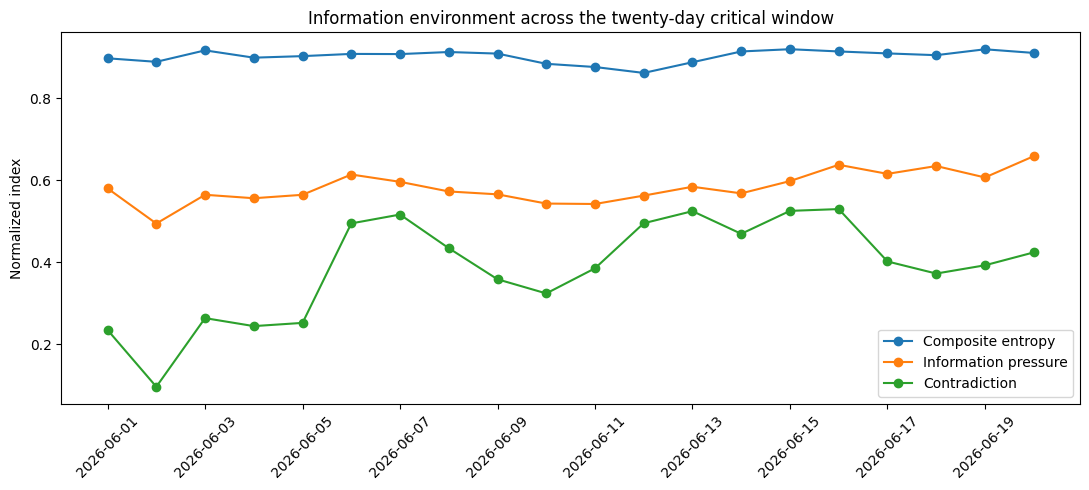

dict_keys(['daily_joined', 'peak_days', 'correlations', 'operationalisation'])

In [ ]:
core_rq1_result = (
    analyze_core_rq1_entropy_and_perceived_environment()
)

core_rq1_result.keys()

## CORE-RQ2 — Interaction between strategic signals and agent conditions

**English:** How do strategic signals interact with trust, memory, fatigue, territorial relevance, and each agent’s prior position?

**Español:** ¿Cómo interactúan las señales estratégicas con la confianza, la memoria, la fatiga, la relevancia territorial y la posición previa de cada agente?

The analysis compares exposure-level effects across source-trust quartiles, motif-memory matches, fatigue quartiles, territorial relevance classes, and congruence with the prior position. These are conditional associations within the frozen run.


In [ ]:

def analyze_core_rq2_signal_agent_interactions() -> dict[str, pd.DataFrame]:
    _require_tables('decision_attribution_log', 'signals_master')
    log = ATTRIBUTIONS.copy()
    signals = DATA['signals_master'].copy()
    signals = signals.rename(columns={'id': 'signal_id'})
    available_signal_columns = [
        column for column in [
            'signal_id', 'region', 'perfiles_relevantes', 'geographic_scope',
            'source_category', 'motif_primary', 'candidate_scope', 'direccion',
        ] if column in signals.columns
    ]
    log = log.merge(signals[available_signal_columns].drop_duplicates('signal_id'), on='signal_id', how='left', suffixes=('', '_signal'))

    agent_columns = [
        column for column in [
            'agent_id', 'macro_region', 'state_fatigue', 'fatigue', 'dominant_memory_motif',
            'motif_memory_strength_sum', 'state_confidence', 'state_uncertainty',
            'profile_institutional_trust', 'profile_source_scepticism',
        ] if column in AGENTS.columns
    ]
    agent_frame = AGENTS[agent_columns].rename(columns={'agent_id': 'receiver_agent_id'})
    log = log.merge(agent_frame, on='receiver_agent_id', how='left')

    trust_long = _source_trust_long()
    if not trust_long.empty:
        log['source_category_key'] = log['source_category'].map(_normalised_category)
        trust_long = trust_long.rename(columns={'agent_id': 'receiver_agent_id'})
        log = log.merge(trust_long, on=['receiver_agent_id', 'source_category_key'], how='left')
    else:
        log['source_trust'] = np.nan

    fatigue_column = 'state_fatigue' if 'state_fatigue' in log.columns else 'fatigue'
    log['fatigue_value'] = pd.to_numeric(log.get(fatigue_column), errors='coerce')
    log['trust_quartile'] = _safe_qcut(log['source_trust'], ['Q1 low', 'Q2', 'Q3', 'Q4 high'])
    log['fatigue_quartile'] = _safe_qcut(log['fatigue_value'], ['Q1 low', 'Q2', 'Q3', 'Q4 high'])
    log['prior_position_strength'] = pd.to_numeric(log['position_before'], errors='coerce').abs()
    log['prior_position_band'] = _safe_qcut(log['prior_position_strength'], ['Q1 weak', 'Q2', 'Q3', 'Q4 strong'])

    candidate_column = 'candidate_scope' if 'candidate_scope' in log.columns else 'candidate_affected'
    direction_column = 'direccion' if 'direccion' in log.columns else 'narrative_direction'
    log['signal_direction_sign'] = [
        _signal_direction_sign(candidate, direction)
        for candidate, direction in zip(log[candidate_column], log[direction_column])
    ]
    prior_sign = np.sign(pd.to_numeric(log['position_before'], errors='coerce').fillna(0))
    signal_sign = pd.Series(log['signal_direction_sign'], index=log.index)
    log['prior_position_relation'] = np.select(
        [
            signal_sign.eq(0),
            prior_sign.eq(0),
            (prior_sign * signal_sign).gt(0),
            (prior_sign * signal_sign).lt(0),
        ],
        ['non_directional', 'neutral_prior', 'congruent', 'cross_cutting'],
        default='other',
    )
    log['reactance'] = (signal_sign.ne(0) & (pd.to_numeric(log['position_delta'], errors='coerce') * signal_sign).lt(0))
    log['memory_match'] = (
        log['dominant_memory_motif'].map(normalise_text)
        == log['motif_key'].map(normalise_text)
    )
    log['territorial_relevance'] = [
        _territorial_relevance_class(signal_region, agent_region)
        for signal_region, agent_region in zip(log.get('region'), log.get('macro_region'))
    ]

    def summarize(group_column: str) -> pd.DataFrame:
        return log.groupby(group_column, dropna=False).agg(
            exposures=('receiver_agent_id', 'size'),
            agents=('receiver_agent_id', 'nunique'),
            mean_source_trust=('source_trust', 'mean'),
            mean_effect=('effect_magnitude', 'mean'),
            total_effect=('effect_magnitude', 'sum'),
            mean_absolute_position_shift=('position_delta', lambda s: pd.to_numeric(s, errors='coerce').abs().mean()),
            mean_uncertainty_shift=('uncertainty_delta', 'mean'),
            mean_blank_shift=('blank_delta', 'mean'),
            mean_abstention_shift=('abstention_delta', 'mean'),
            reinforcement_rate=('reinforcement', 'mean'),
            reactance_rate=('reactance', 'mean'),
        ).reset_index()

    outputs = {
        'source_trust': summarize('trust_quartile'),
        'memory_match': summarize('memory_match'),
        'fatigue': summarize('fatigue_quartile'),
        'territorial_relevance': summarize('territorial_relevance'),
        'prior_position': summarize('prior_position_relation'),
        'prior_position_strength': summarize('prior_position_band'),
    }
    for title, table in outputs.items():
        display(Markdown(f'### {title.replace("_", " ").title()}'))
        display(table)
    return {'exposure_level_data': log, **outputs}


In [ ]:
core_rq2_result = (
    analyze_core_rq2_signal_agent_interactions()
)

core_rq2_result.keys()

/tmp/ipykernel_10015/2229658879.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return log.groupby(group_column, dropna=False).agg(
/tmp/ipykernel_10015/2229658879.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return log.groupby(group_column, dropna=False).agg(
/tmp/ipykernel_10015/2229658879.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return log.groupby(group_column, dropna=False).agg(


### Source Trust

,trust_quartile,exposures,agents,mean_source_trust,mean_effect,total_effect,mean_absolute_position_shift,mean_uncertainty_shift,mean_blank_shift,mean_abstention_shift,reinforcement_rate,reactance_rate
0,Q1 low,5277,869,0.462461,0.000776,4.094913,0.000353,0.000352,0.000060,7.702810e-06,0.264165,0.0
1,Q2,5264,901,0.553492,0.000905,4.762435,0.000378,0.000443,0.000074,2.253678e-06,0.228913,0.0
2,Q3,5271,877,0.611184,0.001059,5.580976,0.000410,0.000509,0.000126,2.309277e-07,0.215709,0.0
3,Q4 high,5269,732,0.690741,0.001445,7.616177,0.000510,0.000570,0.000348,1.445889e-07,0.213893,0.0


### Memory Match

,memory_match,exposures,agents,mean_source_trust,mean_effect,total_effect,mean_absolute_position_shift,mean_uncertainty_shift,mean_blank_shift,mean_abstention_shift,reinforcement_rate,reactance_rate
0,False,19911,1000,0.578252,0.000982,19.545490,0.000422,0.000442,0.000104,2.695419e-06,0.238813,0.0
1,True,1170,1000,0.599554,0.002144,2.509011,0.000263,0.000912,0.000969,7.022805e-07,0.092308,0.0


...

### Prior Position

,prior_position_relation,exposures,agents,mean_source_trust,mean_effect,total_effect,mean_absolute_position_shift,mean_uncertainty_shift,mean_blank_shift,mean_abstention_shift,reinforcement_rate,reactance_rate
0,congruent,6310,998,0.571714,0.000825,5.208172,0.000376,0.000449,0.000000,0.000000,0.769255,0.0
1,cross_cutting,6100,999,0.576398,0.001420,8.658991,0.000971,0.000449,0.000000,0.000000,0.000000,0.0
2,neutral_prior,156,156,0.572572,0.003027,0.472173,0.002226,0.000801,0.000000,0.000000,0.000000,0.0
3,non_directional,8515,1000,0.587457,0.000906,7.715165,0.000007,0.000491,0.000376,0.000006,0.001057,0.0


### Prior Position Strength

,prior_position_band,exposures,agents,mean_source_trust,mean_effect,total_effect,mean_absolute_position_shift,mean_uncertainty_shift,mean_blank_shift,mean_abstention_shift,reinforcement_rate,reactance_rate
0,Q1 weak,5272,272,0.579889,0.001207,6.362518,0.000568,0.000479,0.000147,0.000003,0.277314,0.0
1,Q2,5269,757,0.581915,0.001116,5.879065,0.000501,0.000441,0.000159,0.000002,0.309926,0.0
2,Q3,5270,713,0.575823,0.000913,4.813149,0.000271,0.000448,0.000179,0.000003,0.307400,0.0
3,Q4 strong,5270,727,0.580112,0.000949,4.999769,0.000310,0.000506,0.000123,0.000002,0.028083,0.0


dict_keys(['exposure_level_data', 'source_trust', 'memory_match', 'fatigue', 'territorial_relevance', 'prior_position', 'prior_position_strength'])

## CORE-RQ3 — Narrative diffusion and interaction across multiplex network layers

**English:** What patterns emerge from narrative diffusion and interaction in close-tie, workplace, community, and digital networks?

**Español:** ¿Qué patrones emergen de la difusión narrativa y de la interacción en redes cercanas, laborales, comunitarias y digitales?

This module separates narrative transmission from ordinary social interaction and compares the four layers in terms of cascade structure, trust, convergence, repulsion, agreement, and dominant motifs.


In [ ]:

def analyze_core_rq3_narrative_diffusion_and_network_layers(top_motifs_per_layer: int = 8) -> dict[str, pd.DataFrame]:
    _require_tables('peer_transmission_log', 'social_interaction_log')
    peer = DATA['peer_transmission_log'].copy()
    interaction = DATA['social_interaction_log'].copy()

    numeric_peer = ['depth', 'trust', 'peer_effect', 'position_before', 'position_after', 'position_delta',
                    'uncertainty_delta', 'blank_delta', 'abstention_delta']
    for column in numeric_peer:
        if column in peer.columns:
            peer[column] = pd.to_numeric(peer[column], errors='coerce')
    peer['reinforcement'] = (
        peer['position_before'].ne(0)
        & np.sign(peer['position_before']).eq(np.sign(peer['position_after']))
        & peer['position_after'].abs().gt(peer['position_before'].abs())
    )

    layer_diffusion = peer.groupby('layer').agg(
        transmissions=('receiver_id', 'size'),
        cascades=('cascade_id', 'nunique'),
        receivers=('receiver_id', 'nunique'),
        signals=('signal_id', 'nunique'),
        motifs=('motif_key', 'nunique'),
        mean_depth=('depth', 'mean'),
        maximum_depth=('depth', 'max'),
        mean_trust=('trust', 'mean'),
        total_peer_effect=('peer_effect', 'sum'),
        mean_absolute_position_shift=('position_delta', lambda s: s.abs().mean()),
        mean_uncertainty_shift=('uncertainty_delta', 'mean'),
        reinforcement_rate=('reinforcement', 'mean'),
    ).reset_index()

    narrative_layer = peer.groupby(['layer', 'motif_key'], dropna=False).agg(
        transmissions=('receiver_id', 'size'),
        receivers=('receiver_id', 'nunique'),
        cascades=('cascade_id', 'nunique'),
        maximum_depth=('depth', 'max'),
        total_peer_effect=('peer_effect', 'sum'),
        mean_trust=('trust', 'mean'),
    ).reset_index()
    narrative_layer['within_layer_rank'] = narrative_layer.groupby('layer')['transmissions'].rank(method='first', ascending=False)
    top_narratives = narrative_layer.loc[narrative_layer['within_layer_rank'] <= top_motifs_per_layer].sort_values(
        ['layer', 'within_layer_rank']
    )

    numeric_interaction = [
        'distance_before', 'trust_before', 'trust_after',
        'first_position_before', 'first_position_after',
        'second_position_before', 'second_position_after',
    ]
    for column in numeric_interaction:
        interaction[column] = pd.to_numeric(interaction[column], errors='coerce')
    interaction['trust_change'] = interaction['trust_after'] - interaction['trust_before']
    interaction['first_movement'] = (interaction['first_position_after'] - interaction['first_position_before']).abs()
    interaction['second_movement'] = (interaction['second_position_after'] - interaction['second_position_before']).abs()
    interaction_layer = interaction.groupby('layer').agg(
        interactions=('date', 'size'),
        dyads=('first_id', 'size'),
        convergence_rate=('interaction_type', lambda s: float((s == 'convergence').mean())),
        repulsion_rate=('interaction_type', lambda s: float((s == 'repulsion').mean())),
        no_change_rate=('interaction_type', lambda s: float((s == 'no_change').mean())),
        mean_distance=('distance_before', 'mean'),
        mean_trust_before=('trust_before', 'mean'),
        mean_trust_after=('trust_after', 'mean'),
        mean_trust_change=('trust_change', 'mean'),
        mean_first_movement=('first_movement', 'mean'),
        mean_second_movement=('second_movement', 'mean'),
    ).reset_index()

    network_summary = DATA.get('network_emergence', pd.DataFrame()).copy()
    llm_network_summary = DATA.get('llm_network_emergence', pd.DataFrame()).copy()
    if not network_summary.empty:
        interaction_layer = interaction_layer.merge(network_summary, on='layer', how='left')
    if not llm_network_summary.empty:
        interaction_layer = interaction_layer.merge(llm_network_summary, on='layer', how='left', suffixes=('', '_llm'))

    display(Markdown('### Narrative diffusion by layer'))
    display(layer_diffusion)
    display(Markdown('### Dominant narratives within each layer'))
    display(top_narratives)
    display(Markdown('### Social-interaction patterns by layer'))
    display(interaction_layer)

    return {
        'layer_diffusion': layer_diffusion,
        'narrative_layer': narrative_layer,
        'top_narratives': top_narratives,
        'interaction_layer': interaction_layer,
    }


In [ ]:
core_rq3_result = (
    analyze_core_rq3_narrative_diffusion_and_network_layers()
)

core_rq3_result.keys()

### Narrative diffusion by layer

,layer,transmissions,cascades,receivers,signals,motifs,mean_depth,maximum_depth,mean_trust,total_peer_effect,mean_absolute_position_shift,mean_uncertainty_shift,reinforcement_rate
0,close_ties,113,111,106,72,72,1.0,1,0.815669,0.032783,0.000087,0.000022,0.176991
1,community,21,21,21,18,18,1.0,1,0.699749,0.003700,0.000059,0.000012,0.333333
2,digital,7,7,7,7,7,1.0,1,0.638349,0.000961,0.000108,0.000015,0.428571
3,workplace,41,41,40,32,32,1.0,1,0.720351,0.005988,0.000047,0.000011,0.243902


### Dominant narratives within each layer

,layer,motif_key,transmissions,receivers,cascades,maximum_depth,total_peer_effect,mean_trust,within_layer_rank
44,close_ties,injerencia_trump,5,5,5,1,0.001706,0.806388,1.0
26,close_ties,debate_condicionado,4,4,4,1,0.001228,0.806640,2.0
48,close_ties,kpopers_con_cepeda,4,4,4,1,0.001205,0.760958,3.0
63,close_ties,segunda_vuelta_confirmada,4,4,4,1,0.002188,0.843007,4.0
10,close_ties,auditoria_votos_pdet,3,3,2,1,0.000292,0.847258,5.0
27,close_ties,debate_inravision,3,3,3,1,0.001121,0.787297,6.0
35,close_ties,entrevista_6amw_abelardo,3,3,3,1,0.000429,0.760143,7.0
54,close_ties,presunto_autoatentado,3,3,3,1,0.000199,0.852999,8.0
77,community,debate_condicionado,2,2,2,1,0.000521,0.708714,1.0
78,community,debate_inravision,2,2,2,1,0.000296,0.737718,2.0


### Social-interaction patterns by layer

,layer,interactions,dyads,convergence_rate,repulsion_rate,no_change_rate,mean_distance,mean_trust_before,mean_trust_after,mean_trust_change,mean_first_movement,mean_second_movement,nodes,edges,mean_degree,state_edge_agreement,state_assortativity,mean_trust,abm_edge_agreement,llm_edge_agreement,abm_assortativity,llm_assortativity
0,close_ties,8940,8940,0.329418,0.256488,0.0,0.927128,0.807970,0.805498,-0.002471,0.000084,0.000085,1000,1788,3.576,0.300336,-0.001754,0.801421,0.300336,0.375280,-0.001754,0.011569
1,community,11220,11220,0.363636,0.263904,0.0,0.900433,0.597741,0.595864,-0.001876,0.000054,0.000057,1000,2245,4.490,0.322494,0.023368,0.592009,0.322494,0.383964,0.023368,0.019554
2,digital,16000,16000,1.000000,0.000000,0.0,0.001061,0.515118,0.527118,0.012000,0.000010,0.000010,1000,3199,6.398,0.930291,0.898016,0.546839,0.930291,0.835886,0.898016,0.733904
3,workplace,8300,8300,0.363976,0.260964,0.0,0.897123,0.672813,0.670983,-0.001830,0.000065,0.000071,1000,1660,3.320,0.323494,0.020457,0.666944,0.323494,0.393373,0.020457,0.027440


dict_keys(['layer_diffusion', 'narrative_layer', 'top_narratives', 'interaction_layer'])

## CORE-RQ4 — BDI-lite mediation from exposure to intentions

**English:** How does the BDI-lite engine mediate the transition from information exposure to belief updating and intention formation?

**Español:** ¿Cómo media el motor BDI-lite la transición entre exposición informativa, actualización de creencias y formación de intenciones?

This is a mechanistic process-tracing analysis, not a formal causal mediation model. It maps recorded exposures to belief-state changes, relates them to stable desire orientations, and then examines candidate, blank-vote, abstention, and mobilisation intentions before the heuristic classification.


In [ ]:

def analyze_core_rq4_bdi_lite_mediation() -> dict[str, pd.DataFrame]:
    _require_tables('decision_attribution_log')
    log = ATTRIBUTIONS.copy()
    log['absolute_position_delta'] = pd.to_numeric(log['position_delta'], errors='coerce').abs()
    log['reinforcement'] = (
        log['position_before'].ne(0)
        & np.sign(log['position_before']).eq(np.sign(log['position_after']))
        & log['position_after'].abs().gt(log['position_before'].abs())
    )

    agent_updates = log.groupby('receiver_agent_id').agg(
        exposures=('signal_id', 'size'),
        unique_signals=('signal_id', 'nunique'),
        unique_motifs=('motif_key', 'nunique'),
        direct_exposures=('exposure_channel', lambda s: int((s == 'direct').sum())),
        peer_exposures=('exposure_channel', lambda s: int((s != 'direct').sum())),
        net_position_delta=('position_delta', 'sum'),
        total_absolute_position_delta=('absolute_position_delta', 'sum'),
        net_uncertainty_delta=('uncertainty_delta', 'sum'),
        net_blank_delta=('blank_delta', 'sum'),
        net_abstention_delta=('abstention_delta', 'sum'),
        reinforcement_events=('reinforcement', 'sum'),
    ).reset_index().rename(columns={'receiver_agent_id': 'agent_id'})

    required_agent_columns = [
        'agent_id', 'initial_state_norm', 'current_state_norm', 'llm_final_state_norm',
        'state_position', 'state_confidence', 'state_uncertainty', 'state_fatigue',
        'state_mobilisation', 'state_blank_vote_propensity', 'state_abstention_propensity',
        'profile_order_orientation', 'profile_negotiation_orientation',
        'profile_economic_orientation', 'profile_cultural_progressivism',
    ]
    available_agent_columns = [column for column in required_agent_columns if column in AGENTS.columns]
    process = AGENTS[available_agent_columns].merge(agent_updates, on='agent_id', how='left')
    update_columns = [
        'exposures', 'unique_signals', 'unique_motifs', 'direct_exposures', 'peer_exposures',
        'net_position_delta', 'total_absolute_position_delta', 'net_uncertainty_delta',
        'net_blank_delta', 'net_abstention_delta', 'reinforcement_events',
    ]
    for column in update_columns:
        if column in process.columns:
            process[column] = pd.to_numeric(process[column], errors='coerce').fillna(0)

    desire_columns = {
        'Order and security': 'profile_order_orientation',
        'Negotiation and peace': 'profile_negotiation_orientation',
        'Economic orientation': 'profile_economic_orientation',
        'Cultural progressivism': 'profile_cultural_progressivism',
    }
    available_desires = {label: column for label, column in desire_columns.items() if column in process.columns}
    if available_desires:
        desire_frame = process[list(available_desires.values())].apply(pd.to_numeric, errors='coerce')
        reverse_desires = {column: label for label, column in available_desires.items()}
        process['dominant_desire_orientation'] = desire_frame.idxmax(axis=1).map(reverse_desires)
    else:
        process['dominant_desire_orientation'] = 'Unavailable'

    mechanism_columns = {
        'Candidate-position belief update': 'net_position_delta',
        'Uncertainty belief update': 'net_uncertainty_delta',
        'Blank-vote intention update': 'net_blank_delta',
        'Abstention intention update': 'net_abstention_delta',
    }
    magnitude = pd.DataFrame({
        label: pd.to_numeric(process[column], errors='coerce').abs()
        for label, column in mechanism_columns.items()
    })
    process['dominant_recorded_update'] = magnitude.idxmax(axis=1)

    stage_contract = pd.DataFrame([
        ('Exposure', 'Signals and peer transmissions', 'signal_id, source_category, motif_key, exposure_channel'),
        ('Beliefs', 'Position, source trust, uncertainty, and memory', 'position_delta, uncertainty_delta, source_trust, motif memory'),
        ('Desires', 'Relatively stable priority orientations', 'order, negotiation, economic, and cultural orientations'),
        ('Intentions', 'Candidate support, blank vote, abstention, and mobilisation', 'position, blank_vote_propensity, abstention_propensity, mobilisation'),
        ('Heuristic action state', 'Threshold-based ABM classification', 'current_state_norm'),
        ('Contextualized deliberation', 'Frozen LLM classification after the ABM', 'llm_final_state_norm'),
    ], columns=['stage', 'operational_role', 'variables'])

    initial_transition = pd.crosstab(
        process.get('initial_state_norm', pd.Series('Unavailable', index=process.index)),
        process['current_state_norm'],
        margins=True,
    )
    update_by_state = process.groupby('current_state_norm').agg(
        agents=('agent_id', 'size'),
        mean_exposures=('exposures', 'mean'),
        mean_absolute_position_update=('total_absolute_position_delta', 'mean'),
        mean_net_uncertainty_update=('net_uncertainty_delta', 'mean'),
        mean_net_blank_update=('net_blank_delta', 'mean'),
        mean_net_abstention_update=('net_abstention_delta', 'mean'),
        mean_reinforcement_events=('reinforcement_events', 'mean'),
        mean_final_confidence=('state_confidence', 'mean'),
        mean_final_uncertainty=('state_uncertainty', 'mean'),
        mean_final_mobilisation=('state_mobilisation', 'mean'),
    ).reset_index()
    paths = process.groupby(
        ['initial_state_norm', 'dominant_desire_orientation', 'dominant_recorded_update', 'current_state_norm'],
        dropna=False,
    ).size().rename('agents').reset_index().sort_values('agents', ascending=False)

    display(stage_contract)
    display(Markdown('### Initial state to heuristic ABM state'))
    display(initial_transition)
    display(Markdown('### Recorded BDI-lite updates by final heuristic state'))
    display(update_by_state)
    display(Markdown('### Most frequent process paths'))
    display(paths.head(30))

    return {
        'stage_contract': stage_contract,
        'agent_process': process,
        'initial_transition': initial_transition,
        'update_by_state': update_by_state,
        'paths': paths,
    }


In [ ]:
core_rq4_result = analyze_core_rq4_bdi_lite_mediation()

print("CORE-RQ4 completed.")
print("Available outputs:")
for key in core_rq4_result:
    print(f"- {key}")

,stage,operational_role,variables
0,Exposure,Signals and peer transmissions,"signal_id, source_category, motif_key, exposure_channel"
1,Beliefs,"Position, source trust, uncertainty, and memory","position_delta, uncertainty_delta, source_trust, motif memory"
2,Desires,Relatively stable priority orientations,"order, negotiation, economic, and cultural orientations"
3,Intentions,"Candidate support, blank vote, abstention, and mobilisation","position, blank_vote_propensity, abstention_propensity, mobilisation"
4,Heuristic action state,Threshold-based ABM classification,current_state_norm
5,Contextualized deliberation,Frozen LLM classification after the ABM,llm_final_state_norm


### Initial state to heuristic ABM state

current_state_norm,Abstention,Blank vote,Cepeda,De la Espriella,Unaligned,All
initial_state_norm,,,,,,
Abstention,64,0,0,0,1,65
Blank vote,15,2,0,0,51,68
Cepeda,0,0,342,0,0,342
De la Espriella,0,0,0,386,0,386
Unaligned,45,0,0,0,94,139
All,124,2,342,386,146,1000


### Recorded BDI-lite updates by final heuristic state

,current_state_norm,agents,mean_exposures,mean_absolute_position_update,mean_net_uncertainty_update,mean_net_blank_update,mean_net_abstention_update,mean_reinforcement_events,mean_final_confidence,mean_final_uncertainty,mean_final_mobilisation
0,Abstention,124,20.822581,0.013083,0.009845,0.003522,0.000043,5.766129,0.215750,0.747917,0.083552
1,Blank vote,2,16.500000,0.015356,0.007903,0.005292,0.000000,5.500000,0.348278,0.620681,0.140888
2,Cepeda,342,21.192982,0.006340,0.009778,0.002986,0.000044,4.345029,0.741557,0.422130,0.722528
3,De la Espriella,386,21.349741,0.008373,0.009954,0.003349,0.000059,4.722798,0.743171,0.420145,0.711559
4,Unaligned,146,20.390411,0.011278,0.009942,0.003019,0.000078,5.671233,0.262496,0.703115,0.129894


### Most frequent process paths

,initial_state_norm,dominant_desire_orientation,dominant_recorded_update,current_state_norm,agents
48,De la Espriella,Order and security,Uncertainty belief update,De la Espriella,103
36,Cepeda,Order and security,Uncertainty belief update,Cepeda,85
30,Cepeda,Economic orientation,Uncertainty belief update,Cepeda,72
27,Cepeda,Cultural progressivism,Uncertainty belief update,Cepeda,70
45,De la Espriella,Negotiation and peace,Uncertainty belief update,De la Espriella,68
42,De la Espriella,Economic orientation,Uncertainty belief update,De la Espriella,66
33,Cepeda,Negotiation and peace,Uncertainty belief update,Cepeda,56
39,De la Espriella,Cultural progressivism,Uncertainty belief update,De la Espriella,54
67,Unaligned,Order and security,Uncertainty belief update,Unaligned,32
62,Unaligned,Negotiation and peace,Uncertainty belief update,Unaligned,20


CORE-RQ4 completed.
Available outputs:
- stage_contract
- agent_process
- initial_transition
- update_by_state
- paths


## CORE-RQ5 — Dynamics producing reinforcement, rejection, blank vote, unalignment, abstention, and mobilisation

**English:** Which dynamics produce reinforcement, rejection, blank vote, unalignment, abstention, and mobilisation?

**Español:** ¿Qué dinámicas producen refuerzo, rechazo, voto en blanco, no alineación, abstención y movilización?

“Rejection” is operationalized as *reactance*: movement opposite to the directional implication of an exposure. The module also distinguishes weakening, conversion, and reinforcement. Final-state patterns remain conditional on the model’s thresholds and parameters.


In [ ]:

def analyze_core_rq5_state_dynamics(top_events: int = 15) -> dict[str, pd.DataFrame]:
    _require_tables('decision_attribution_log')
    log = ATTRIBUTIONS.copy()
    log['signal_direction_sign'] = [
        _signal_direction_sign(candidate, direction)
        for candidate, direction in zip(log['candidate_affected'], log['narrative_direction'])
    ]
    signal_sign = pd.Series(log['signal_direction_sign'], index=log.index)
    before = pd.to_numeric(log['position_before'], errors='coerce').fillna(0)
    after = pd.to_numeric(log['position_after'], errors='coerce').fillna(0)
    delta = pd.to_numeric(log['position_delta'], errors='coerce').fillna(0)

    log['reinforcement_event'] = before.ne(0) & np.sign(before).eq(np.sign(after)) & after.abs().gt(before.abs())
    log['weakening_event'] = before.ne(0) & np.sign(before).eq(np.sign(after)) & after.abs().lt(before.abs())
    log['conversion_event'] = (before * after).lt(0)
    log['reactance_event'] = signal_sign.ne(0) & (delta * signal_sign).lt(0)

    agent_dynamics = log.groupby('receiver_agent_id').agg(
        exposures=('signal_id', 'size'),
        reinforcement_events=('reinforcement_event', 'sum'),
        reactance_events=('reactance_event', 'sum'),
        weakening_events=('weakening_event', 'sum'),
        conversion_events=('conversion_event', 'sum'),
        cumulative_absolute_position_shift=('position_delta', lambda s: pd.to_numeric(s, errors='coerce').abs().sum()),
        cumulative_uncertainty_shift=('uncertainty_delta', 'sum'),
        cumulative_blank_shift=('blank_delta', 'sum'),
        cumulative_abstention_shift=('abstention_delta', 'sum'),
    ).reset_index().rename(columns={'receiver_agent_id': 'agent_id'})

    columns = [
        'agent_id', 'current_state_norm', 'llm_final_state_norm', 'state_confidence',
        'state_uncertainty', 'state_fatigue', 'state_mobilisation',
        'state_blank_vote_propensity', 'state_abstention_propensity',
    ]
    columns = [column for column in columns if column in AGENTS.columns]
    merged = AGENTS[columns].merge(agent_dynamics, on='agent_id', how='left')
    for column in agent_dynamics.columns:
        if column != 'agent_id':
            merged[column] = pd.to_numeric(merged[column], errors='coerce').fillna(0)

    mobilisation = pd.to_numeric(merged.get('state_mobilisation'), errors='coerce')
    mobilisation_threshold = mobilisation.quantile(0.75)
    merged['high_mobilisation'] = mobilisation.ge(mobilisation_threshold)

    state_mechanisms = merged.groupby('current_state_norm').agg(
        agents=('agent_id', 'size'),
        mean_reinforcement_events=('reinforcement_events', 'mean'),
        mean_reactance_events=('reactance_events', 'mean'),
        mean_weakening_events=('weakening_events', 'mean'),
        mean_conversion_events=('conversion_events', 'mean'),
        mean_uncertainty_shift=('cumulative_uncertainty_shift', 'mean'),
        mean_blank_shift=('cumulative_blank_shift', 'mean'),
        mean_abstention_shift=('cumulative_abstention_shift', 'mean'),
        mean_confidence=('state_confidence', 'mean'),
        mean_uncertainty=('state_uncertainty', 'mean'),
        mean_fatigue=('state_fatigue', 'mean'),
        mean_mobilisation=('state_mobilisation', 'mean'),
        high_mobilisation_share=('high_mobilisation', 'mean'),
    ).reset_index()

    event_dynamics = log.groupby(['signal_id', 'signal_title', 'source_category', 'motif_key'], dropna=False).agg(
        exposures=('receiver_agent_id', 'size'),
        agents=('receiver_agent_id', 'nunique'),
        reinforcement_events=('reinforcement_event', 'sum'),
        reactance_events=('reactance_event', 'sum'),
        weakening_events=('weakening_event', 'sum'),
        conversion_events=('conversion_event', 'sum'),
        total_absolute_position_shift=('position_delta', lambda s: pd.to_numeric(s, errors='coerce').abs().sum()),
        uncertainty_shift=('uncertainty_delta', 'sum'),
        blank_shift=('blank_delta', 'sum'),
        abstention_shift=('abstention_delta', 'sum'),
    ).reset_index()
    event_dynamics['reinforcement_rate'] = event_dynamics['reinforcement_events'] / event_dynamics['exposures']
    event_dynamics['reactance_rate'] = event_dynamics['reactance_events'] / event_dynamics['exposures']

    top_reinforcement = event_dynamics.sort_values(
        ['reinforcement_events', 'total_absolute_position_shift'], ascending=False
    ).head(top_events)
    top_reactance = event_dynamics.sort_values(
        ['reactance_events', 'total_absolute_position_shift'], ascending=False
    ).head(top_events)

    dynamics_contract = pd.DataFrame([
        ('Reinforcement', 'Position moves farther in the same direction as the prior position.', 'reinforcement_event'),
        ('Rejection / reactance', 'Position moves opposite to the directional implication of the signal.', 'reactance_event'),
        ('Weakening', 'Position remains on the same side but moves closer to the centre.', 'weakening_event'),
        ('Conversion', 'Position crosses the signed candidate axis.', 'conversion_event'),
        ('Blank vote', 'Blank-vote propensity and the final threshold-based state.', 'blank_delta; state_blank_vote_propensity'),
        ('Unalignment', 'No decision score exceeds the heuristic threshold.', 'current_state_norm == Unaligned'),
        ('Abstention', 'Abstention propensity, fatigue, mobilisation, and the final state.', 'abstention_delta; state_abstention_propensity'),
        ('Mobilisation', 'Final mobilisation intensity; the top quartile is used for profiling.', 'state_mobilisation'),
    ], columns=['dynamic', 'operational_definition', 'variables'])

    display(dynamics_contract)
    display(Markdown('### State-level dynamics'))
    display(state_mechanisms)
    display(Markdown('### Events with the most reinforcement'))
    display(top_reinforcement)
    display(Markdown('### Events with the most reactance'))
    display(top_reactance)

    return {
        'dynamics_contract': dynamics_contract,
        'agent_dynamics': merged,
        'state_mechanisms': state_mechanisms,
        'event_dynamics': event_dynamics,
        'top_reinforcement': top_reinforcement,
        'top_reactance': top_reactance,
    }


In [ ]:
core_rq5_result = analyze_core_rq5_state_dynamics(
    top_events=15
)

print("CORE-RQ5 completed.")
print("Available outputs:")
for key in core_rq5_result:
    print(f"- {key}")

,dynamic,operational_definition,variables
0,Reinforcement,Position moves farther in the same direction as the prior position.,reinforcement_event
1,Rejection / reactance,Position moves opposite to the directional implication of the signal.,reactance_event
2,Weakening,Position remains on the same side but moves closer to the centre.,weakening_event
3,Conversion,Position crosses the signed candidate axis.,conversion_event
4,Blank vote,Blank-vote propensity and the final threshold-based state.,blank_delta; state_blank_vote_propensity
5,Unalignment,No decision score exceeds the heuristic threshold.,current_state_norm == Unaligned
6,Abstention,"Abstention propensity, fatigue, mobilisation, and the final state.",abstention_delta; state_abstention_propensity
7,Mobilisation,Final mobilisation intensity; the top quartile is used for profiling.,state_mobilisation


### State-level dynamics

,current_state_norm,agents,mean_reinforcement_events,mean_reactance_events,mean_weakening_events,mean_conversion_events,mean_uncertainty_shift,mean_blank_shift,mean_abstention_shift,mean_confidence,mean_uncertainty,mean_fatigue,mean_mobilisation,high_mobilisation_share
0,Abstention,124,5.766129,0.0,4.346774,1.491935,0.009845,0.003522,0.000043,0.215750,0.747917,0.697517,0.083552,0.000000
1,Blank vote,2,5.500000,0.0,3.000000,0.500000,0.007903,0.005292,0.000000,0.348278,0.620681,0.616891,0.140888,0.000000
2,Cepeda,342,4.345029,0.0,6.029240,0.000000,0.009778,0.002986,0.000044,0.741557,0.422130,0.697842,0.722528,0.359649
3,De la Espriella,386,4.722798,0.0,6.448187,0.000000,0.009954,0.003349,0.000059,0.743171,0.420145,0.700205,0.711559,0.329016
4,Unaligned,146,5.671233,0.0,4.130137,1.602740,0.009942,0.003019,0.000078,0.262496,0.703115,0.666395,0.129894,0.000000


### Events with the most reinforcement

,signal_id,signal_title,source_category,motif_key,exposures,agents,reinforcement_events,reactance_events,weakening_events,conversion_events,total_absolute_position_shift,uncertainty_shift,blank_shift,abstention_shift,reinforcement_rate,reactance_rate
165,S168,Cepeda alerta sobre información de un presunto montaje de autoatentado contra De la Espriella,medio_publico,presunto_autoatentado,531,426,187,0,298,6,0.108938,0.376719,0.0,0.0,0.352166,0.0
173,S176,De la Espriella afirma que con Cepeda estaría en riesgo la continuidad de las elecciones,regional,riesgo_continuidad_electoral,481,396,182,0,244,13,0.198808,0.234458,0.0,0.0,0.378378,0.0
12,S014,RTVC reporta respaldo de comunidad K-pop y Army Colombia a Cepeda y Aída Quilcué,medio_publico,kpop_army_movilizion_juvenil,482,390,173,0,222,25,0.362792,0.242520,0.0,0.0,0.358921,0.0
166,S169,Petro advierte a Trump sobre injerencia y apoyos extranjeros en la campaña,medio_publico,injerencia_trump,460,379,162,0,232,14,0.516448,0.268297,0.0,0.0,0.352174,0.0
57,S060,Trump respalda públicamente a Abelardo de la Espriella rumbo a la segunda vuelta,internacional,respaldo_trump,334,301,133,0,151,13,0.277436,0.128360,0.0,0.0,0.398204,0.0
11,S013,AtlasIntel reporta ventaja de De la Espriella sobre Cepeda en segunda vuelta,alternativo_investigativo,ventaja_encuestas,307,272,130,0,122,15,0.185139,0.138069,0.0,0.0,0.423453,0.0
169,S172,Cuestión Pública investiga un posible mecanismo multinivel y presión sobre contratistas en la campaña de De la Espriella,alternativo_investigativo,red_referidos_y_contratistas,324,281,123,0,158,4,0.183779,0.242874,0.0,0.0,0.379630,0.0
168,S171,La Silla Vacía analiza las dificultades de Cepeda para conquistar al centro,alternativo_investigativo,dificultad_conquista_centro,290,250,116,0,149,11,0.307870,0.103065,0.0,0.0,0.400000,0.0
10,S012,La Silla reporta que Kpopers entran a campaña para impulsar a Cepeda,alternativo_investigativo,kpopers_con_cepeda,297,260,114,0,130,15,0.255244,0.180013,0.0,0.0,0.383838,0.0
17,S019,La Silla analiza voto puesto a puesto y sostiene que Abelardo se ganó la clase media,alternativo_investigativo,clase_media_de_la_espriella,256,234,113,0,112,9,0.148037,0.100917,0.0,0.0,0.441406,0.0


### Events with the most reactance

,signal_id,signal_title,source_category,motif_key,exposures,agents,reinforcement_events,reactance_events,weakening_events,conversion_events,total_absolute_position_shift,uncertainty_shift,blank_shift,abstention_shift,reinforcement_rate,reactance_rate
166,S169,Petro advierte a Trump sobre injerencia y apoyos extranjeros en la campaña,medio_publico,injerencia_trump,460,379,162,0,232,14,0.516448,0.268297,0.0,0.0,0.352174,0.0
12,S014,RTVC reporta respaldo de comunidad K-pop y Army Colombia a Cepeda y Aída Quilcué,medio_publico,kpop_army_movilizion_juvenil,482,390,173,0,222,25,0.362792,0.242520,0.0,0.0,0.358921,0.0
168,S171,La Silla Vacía analiza las dificultades de Cepeda para conquistar al centro,alternativo_investigativo,dificultad_conquista_centro,290,250,116,0,149,11,0.307870,0.103065,0.0,0.0,0.400000,0.0
57,S060,Trump respalda públicamente a Abelardo de la Espriella rumbo a la segunda vuelta,internacional,respaldo_trump,334,301,133,0,151,13,0.277436,0.128360,0.0,0.0,0.398204,0.0
10,S012,La Silla reporta que Kpopers entran a campaña para impulsar a Cepeda,alternativo_investigativo,kpopers_con_cepeda,297,260,114,0,130,15,0.255244,0.180013,0.0,0.0,0.383838,0.0
97,S100,"Caracol Pasto reporta triunfo de Cepeda en Nariño, tranquilidad electoral y capturas aisladas",radio,narino_cepeda_tranquilidad_eln,187,172,50,0,78,6,0.241232,0.139770,0.0,0.0,0.267380,0.0
173,S176,De la Espriella afirma que con Cepeda estaría en riesgo la continuidad de las elecciones,regional,riesgo_continuidad_electoral,481,396,182,0,244,13,0.198808,0.234458,0.0,0.0,0.378378,0.0
18,S020,Juez prohíbe a De la Espriella usar camiseta de la Selección Colombia en campaña,television,prohibicion_camiseta_seleccion,119,116,45,0,50,15,0.188317,0.070704,0.0,0.0,0.378151,0.0
4,S006,Federación Colombiana de Fútbol se refiere al uso de la camiseta de la Selección en campaña,television,camiseta_seleccion,132,120,31,0,62,3,0.186918,0.102071,0.0,0.0,0.234848,0.0
29,S032,Juez ordena retirar publicidad de De la Espriella con bandera y frases de patria,television,simbolos_patrios_firmes_patria,123,119,46,0,58,8,0.186836,0.072401,0.0,0.0,0.373984,0.0


CORE-RQ5 completed.
Available outputs:
- dynamics_contract
- agent_dynamics
- state_mechanisms
- event_dynamics
- top_reinforcement
- top_reactance


## CORE-RQ6 — Heuristic ABM decision versus contextualized LLM deliberation

**English:** What differences appear between the heuristic multi-agent decision and the contextualized deliberation of the LLM layer?

**Español:** ¿Qué diferencias aparecen entre la decisión heurística del sistema multiagente y la deliberación contextualizada de la capa LLM?

The comparison treats both engines as alternative decision architectures applied to the same frozen synthetic population. Agreement does not validate either engine against real human cognition.


In [ ]:

def analyze_core_rq6_abm_llm_differences() -> dict[str, pd.DataFrame | float]:
    abm_share = AGENTS['current_state_norm'].value_counts(normalize=True).reindex(STATE_ORDER, fill_value=0)
    llm_share = AGENTS['llm_final_state_norm'].value_counts(normalize=True).reindex(STATE_ORDER, fill_value=0)
    shares = pd.DataFrame({
        'state': STATE_ORDER,
        'abm_share': [abm_share[state] for state in STATE_ORDER],
        'llm_share': [llm_share[state] for state in STATE_ORDER],
    })
    shares['difference_percentage_points'] = 100 * (shares['llm_share'] - shares['abm_share'])

    transition_counts = pd.crosstab(
        AGENTS['current_state_norm'], AGENTS['llm_final_state_norm']
    ).reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)
    transition_rates = pd.crosstab(
        AGENTS['current_state_norm'], AGENTS['llm_final_state_norm'], normalize='index'
    ).reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)

    agreement = float((AGENTS['current_state_norm'] == AGENTS['llm_final_state_norm']).mean())
    kappa = _cohen_kappa_from_labels(AGENTS['current_state_norm'], AGENTS['llm_final_state_norm'])
    entropy_comparison = pd.DataFrame([
        ('ABM heuristic', _normalised_shannon_from_shares(abm_share)),
        ('LLM deliberation', _normalised_shannon_from_shares(llm_share)),
    ], columns=['engine', 'normalised_state_entropy'])

    changed_mask = AGENTS['decision_changed'].astype(bool)
    comparison_variables = safe_numeric_columns(AGENTS, [
        'confidence', 'uncertainty', 'fatigue', 'mobilisation', 'decision_confidence',
        'total_information_dose', 'misinformation_dose', 'contested_semantic_dose',
        'state_confidence', 'state_uncertainty', 'state_fatigue', 'state_mobilisation',
        'state_blank_vote_propensity', 'state_abstention_propensity',
    ])
    changed_profile = compare_binary_group(AGENTS, changed_mask, comparison_variables)

    argument_by_change = explode_themes(
        AGENTS.assign(change_group=np.where(changed_mask, 'Changed', 'Stable')),
        'decisive_argument',
        'change_group',
    )
    emotion_by_change = pd.crosstab(
        AGENTS['dominant_emotion'],
        np.where(changed_mask, 'Changed', 'Stable'),
        normalize='columns',
    )

    network_comparison = DATA.get('llm_network_emergence', pd.DataFrame()).copy()
    summary = pd.DataFrame([
        ('Agreement rate', agreement),
        ('Cohen kappa', kappa),
        ('State-change rate', float(changed_mask.mean())),
        ('Mean LLM decision confidence', pd.to_numeric(AGENTS['decision_confidence'], errors='coerce').mean()),
    ], columns=['metric', 'value'])

    display(Markdown('### Aggregate state shares'))
    display(shares)
    display(Markdown('### Transition counts'))
    display(transition_counts)
    display(Markdown('### Row-normalized transition rates'))
    display(transition_rates)
    display(Markdown('### Agreement and architecture sensitivity'))
    display(summary)
    display(entropy_comparison)
    display(Markdown('### Variables distinguishing changed and stable agents'))
    display(changed_profile.head(20))
    display(Markdown('### Argument themes by change status'))
    display(argument_by_change)
    display(Markdown('### Emotions by change status'))
    display(emotion_by_change)
    if not network_comparison.empty:
        display(Markdown('### Network agreement under the two decision engines'))
        display(network_comparison)

    return {
        'shares': shares,
        'transition_counts': transition_counts,
        'transition_rates': transition_rates,
        'agreement': agreement,
        'kappa': kappa,
        'summary': summary,
        'entropy_comparison': entropy_comparison,
        'changed_profile': changed_profile,
        'argument_by_change': argument_by_change,
        'emotion_by_change': emotion_by_change,
        'network_comparison': network_comparison,
    }


In [ ]:
core_rq6_result = analyze_core_rq6_abm_llm_differences()

print("CORE-RQ6 completed.")
print("Available outputs:")
for key in core_rq6_result:
    print(f"- {key}")

### Aggregate state shares

,state,abm_share,llm_share,difference_percentage_points
0,Cepeda,0.342,0.400,5.8
1,De la Espriella,0.386,0.440,5.4
2,Blank vote,0.002,0.045,4.3
3,Unaligned,0.146,0.023,-12.3
4,Abstention,0.124,0.092,-3.2


### Transition counts

llm_final_state_norm,Cepeda,De la Espriella,Blank vote,Unaligned,Abstention
current_state_norm,,,,,
Cepeda,342,0,0,0,0
De la Espriella,0,386,0,0,0
Blank vote,0,0,2,0,0
Unaligned,46,39,37,23,1
Abstention,12,15,6,0,91


### Row-normalized transition rates

...

### Emotions by change status

col_0,Changed,Stable
dominant_emotion,,
acusacion,0.000000,0.001185
alarma,0.006410,0.007109
alerta,0.025641,0.042654
alivio,0.000000,0.001185
apertura,0.006410,0.000000
autoridad,0.006410,0.001185
cercania,0.000000,0.001185
certeza,0.000000,0.213270
confianza,0.019231,0.229858


### Network agreement under the two decision engines

,layer,abm_edge_agreement,llm_edge_agreement,abm_assortativity,llm_assortativity
0,close_ties,0.300336,0.375280,-0.001754,0.011569
1,workplace,0.323494,0.393373,0.020457,0.027440
2,community,0.322494,0.383964,0.023368,0.019554
3,digital,0.930291,0.835886,0.898016,0.733904


CORE-RQ6 completed.
Available outputs:
- shares
- transition_counts
- transition_rates
- agreement
- kappa
- summary
- entropy_comparison
- changed_profile
- argument_by_change
- emotion_by_change
- network_comparison


## Local interface — Local “Ask the Model” interface

In [ ]:

CORE_QUESTION_ROUTER = [
    (
        r'entropy.*perceived|information entropy.*twenty|evoluciona.*entrop|entorno percibido',
        analyze_core_rq1_entropy_and_perceived_environment,
    ),
    (
        r'strategic signal.*trust|trust.*memory.*fatigue|senales estrategicas.*confianza|señales estrategicas.*confianza|relevancia territorial|prior position|posicion previa|posición previa',
        analyze_core_rq2_signal_agent_interactions,
    ),
    (
        r'narrative diffusion|diffusion.*close|workplace.*community.*digital|difusion narrativa|difusión narrativa|redes cercanas|laborales.*comunitarias.*digitales',
        analyze_core_rq3_narrative_diffusion_and_network_layers,
    ),
    (
        r'bdi.?lite|belief updating.*intention|exposure.*belief.*intention|motor bdi|actualizacion de creencias|actualización de creencias|formacion de intenciones|formación de intenciones',
        analyze_core_rq4_bdi_lite_mediation,
    ),
    (
        r'reinforcement.*rejection.*blank|refuerzo.*rechazo.*blanco|unalignment.*abstention.*mobilisation|no alineacion.*abstencion.*movilizacion|no alineación.*abstención.*movilización',
        analyze_core_rq5_state_dynamics,
    ),
    (
        r'heuristic.*llm|abm.*llm.*difference|decision heuristica.*llm|decisión heurística.*llm|deliberacion contextualizada|deliberación contextualizada',
        analyze_core_rq6_abm_llm_differences,
    ),
]

QUESTION_ROUTER = CORE_QUESTION_ROUTER + [
    (r'macro|emerg|macroscopic|macroscopico|macroscópico|no programad|not directly programmed', macro_emergence_audit),
    (r'blank vote|voto en blanco|\bblanco\b', lambda: analyze_blank_vote('LLM')),
    (r'abstain|abstention|absten', lambda: analyze_abstention('LLM')),
    (r'unaligned|nonaligned|no aline|indecis', analyze_unaligned),
    (r'entrop|information pressure|presion inform|presión inform', analyze_core_rq1_entropy_and_perceived_environment),
    (r'event|evento|reinforcement|refuerzo|decision power|poder de decision|poder de decisión', lambda: event_ranking('overall')),
    (r'media|medium|source|channel|input|medio|fuente|canal', lambda: source_ranking('source_category')),
    (r'proposal|symbol|controvers|propuesta|simbolo|símbolo|controvers', content_nature_ranking),
    (r'misinform|disinform|fake|false|fals|desinform', misinformation_analysis),
    (r'argument|argumento', lambda: ARGUMENT_THEMES),
    (r'emotion|sentiment|tone|emocion|emoción|sentim|tono', lambda: {'sentiment': SENTIMENT_PROFILE, 'emotion': EMOTION_PROFILE}),
    (r'trump|petro|milei|actor|politic|polític', actor_influence_ranking),
    (r'demograph|profile|demograf|perfil', lambda: demographic_state_profile('LLM')),
    (r'network|homophily|cascade|centrality|red|homofilia|cascada|centralidad', analyze_core_rq3_narrative_diffusion_and_network_layers),
    (r'first round|initial state|transfer|primera vuelta|estado inicial', initial_state_transitions),
    (r'systemic|integrated|sistemic|sistémic|integrado', systemic_profile),
]


def ask_the_model(question: str) -> Any:
    """Route an English or Spanish research question to a deterministic analysis module."""
    q = normalise_text(question)
    for pattern, fn in QUESTION_ROUTER:
        if re.search(pattern, q):
            display(Markdown(f'### Question\n> {question}'))
            result = fn()
            display(Markdown('**Required interpretation:** internal result of a synthetic run; neither causality nor forecast.'))
            return result
    display(Markdown('No automatic module was identified. Review `CORE_PROJECT_RESEARCH_QUESTIONS`, `RESEARCH_QUESTIONS`, or run a specific function.'))
    return None

# Core project questions in English:
# ask_the_model('How does information entropy evolve during the twenty-day critical window, and how does it modify the environment perceived by agents?')
# ask_the_model('How do strategic signals interact with trust, memory, fatigue, territorial relevance, and each agent’s prior position?')
# ask_the_model('What patterns emerge from narrative diffusion and interaction in close-tie, workplace, community, and digital networks?')
# ask_the_model('How does the BDI-lite engine mediate the transition from information exposure to belief updating and intention formation?')
# ask_the_model('Which dynamics produce reinforcement, rejection, blank vote, unalignment, abstention, and mobilisation?')
# ask_the_model('What differences appear between the heuristic multi-agent decision and the contextualized deliberation of the LLM layer?')

# Core project questions in Spanish:
# ask_the_model('¿Cómo evoluciona la entropía informacional durante los veinte días de la ventana crítica y cómo modifica el entorno percibido por los agentes?')
# ask_the_model('¿Cómo interactúan las señales estratégicas con la confianza, la memoria, la fatiga, la relevancia territorial y la posición previa de cada agente?')
# ask_the_model('¿Qué patrones emergen de la difusión narrativa y de la interacción en redes cercanas, laborales, comunitarias y digitales?')
# ask_the_model('¿Cómo media el motor BDI-lite la transición entre exposición informativa, actualización de creencias y formación de intenciones?')
# ask_the_model('¿Qué dinámicas producen refuerzo, rechazo, voto en blanco, no alineación, abstención y movilización?')
# ask_the_model('¿Qué diferencias aparecen entre la decisión heurística del sistema multiagente y la deliberación contextualizada de la capa LLM?')


## 24. Reproducible export

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil

import pandas as pd


# ---------------------------------------------------------------------
# Research output package configuration
# ---------------------------------------------------------------------

OUTPUT_DIR = Path("/content/MADM_COL2026_Offline_Research_Outputs")
ZIP_PATH = Path("/content/MADM_COL2026_Offline_Research_Outputs.zip")


def _to_dataframe(value):
    """Convert supported analytical objects to a DataFrame."""
    if isinstance(value, pd.DataFrame):
        return value.copy()

    if isinstance(value, pd.Series):
        return value.rename("value").reset_index()

    if isinstance(value, dict):
        try:
            return pd.DataFrame(value)
        except ValueError:
            return pd.DataFrame(
                [{"key": key, "value": val} for key, val in value.items()]
            )

    return None


def _prepare_dataframe(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Preserve meaningful indexes while avoiding duplicate RangeIndex columns."""
    dataframe = dataframe.copy()

    has_meaningful_index = (
        dataframe.index.name is not None
        or not isinstance(dataframe.index, pd.RangeIndex)
    )

    if has_meaningful_index:
        dataframe = dataframe.reset_index()

    return dataframe


def export_research_outputs(
    download: bool = True,
    clean_output_directory: bool = True,
) -> Path:
    """
    Export all available offline research outputs, generate a manifest,
    compress the package, and optionally download it in Google Colab.
    """

    # -----------------------------------------------------------------
    # 1. Create a clean output directory
    # -----------------------------------------------------------------

    if clean_output_directory and OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    outputs = {}

    def add_output(filename: str, value) -> None:
        dataframe = _to_dataframe(value)

        if dataframe is not None:
            outputs[filename] = _prepare_dataframe(dataframe)
        else:
            print(f"Skipped unavailable or unsupported object: {filename}")

    # -----------------------------------------------------------------
    # 2. General analytical outputs
    # -----------------------------------------------------------------

    general_output_map = {
        "validation.csv": "VALIDATION",
        "research_question_registry.csv": "RESEARCH_QUESTIONS",
        "core_project_research_questions.csv":
            "CORE_PROJECT_RESEARCH_QUESTIONS",
        "core_research_coverage.csv": "CORE_RESEARCH_COVERAGE",
        "daily_information_environment.csv": "DAILY_INFORMATION",
        "entropy_peak_events.csv": "ENTROPY_PEAK_EVENTS",
        "event_ranking_overall.csv": "RANK_OVERALL",
        "source_ranking.csv": "SOURCE_RANKING",
        "channel_ranking.csv": "CHANNEL_RANKING",
        "content_nature_ranking.csv": "CONTENT_NATURE",
        "argument_themes.csv": "ARGUMENT_THEMES",
        "sentiment_profile.csv": "SENTIMENT_PROFILE",
        "emotion_profile.csv": "EMOTION_PROFILE",
        "actor_ranking.csv": "ACTOR_RANKING",
        "systemic_profile.csv": "SYSTEMIC_PROFILE",
    }

    for filename, variable_name in general_output_map.items():
        value = globals().get(variable_name)

        if value is not None:
            add_output(filename, value)
        else:
            print(f"Not available: {variable_name}")

    # -----------------------------------------------------------------
    # 3. Macro-emergence audit
    # -----------------------------------------------------------------

    macro_emergence = globals().get("MACRO_EMERGENCE")

    if isinstance(macro_emergence, dict):
        add_output(
            "macro_emergence_audit.csv",
            macro_emergence.get("audit"),
        )

    # -----------------------------------------------------------------
    # 4. Non-aligned population analysis
    # -----------------------------------------------------------------

    nonaligned_analysis = globals().get("NONALIGNED_ANALYSIS")

    if isinstance(nonaligned_analysis, dict):
        add_output(
            "nonaligned_destinations.csv",
            nonaligned_analysis.get("destination"),
        )
        add_output(
            "nonaligned_cluster_profile.csv",
            nonaligned_analysis.get("profile"),
        )

    # -----------------------------------------------------------------
    # 5. Core research-question outputs
    # -----------------------------------------------------------------

    core_export_map = {
        "core_rq1_daily_joined.csv":
            ("CORE-RQ1", "daily_joined"),
        "core_rq1_correlations.csv":
            ("CORE-RQ1", "correlations"),
        "core_rq1_peak_days.csv":
            ("CORE-RQ1", "peak_days"),
        "core_rq1_peak_day_events.csv":
            ("CORE-RQ1", "peak_day_events"),

        "core_rq2_source_trust.csv":
            ("CORE-RQ2", "source_trust"),
        "core_rq2_memory_match.csv":
            ("CORE-RQ2", "memory_match"),
        "core_rq2_fatigue.csv":
            ("CORE-RQ2", "fatigue"),
        "core_rq2_territorial_relevance.csv":
            ("CORE-RQ2", "territorial_relevance"),
        "core_rq2_prior_position.csv":
            ("CORE-RQ2", "prior_position"),

        "core_rq3_layer_diffusion.csv":
            ("CORE-RQ3", "layer_diffusion"),
        "core_rq3_top_narratives.csv":
            ("CORE-RQ3", "top_narratives"),
        "core_rq3_interaction_layer.csv":
            ("CORE-RQ3", "interaction_layer"),

        "core_rq4_stage_contract.csv":
            ("CORE-RQ4", "stage_contract"),
        "core_rq4_agent_process.csv":
            ("CORE-RQ4", "agent_process"),
        "core_rq4_initial_transition.csv":
            ("CORE-RQ4", "initial_transition"),
        "core_rq4_update_by_state.csv":
            ("CORE-RQ4", "update_by_state"),
        "core_rq4_process_paths.csv":
            ("CORE-RQ4", "paths"),

        "core_rq5_dynamics_contract.csv":
            ("CORE-RQ5", "dynamics_contract"),
        "core_rq5_agent_dynamics.csv":
            ("CORE-RQ5", "agent_dynamics"),
        "core_rq5_state_mechanisms.csv":
            ("CORE-RQ5", "state_mechanisms"),
        "core_rq5_event_dynamics.csv":
            ("CORE-RQ5", "event_dynamics"),
        "core_rq5_top_reinforcement.csv":
            ("CORE-RQ5", "top_reinforcement"),
        "core_rq5_top_reactance.csv":
            ("CORE-RQ5", "top_reactance"),

        "core_rq6_shares.csv":
            ("CORE-RQ6", "shares"),
        "core_rq6_transition_counts.csv":
            ("CORE-RQ6", "transition_counts"),
        "core_rq6_transition_rates.csv":
            ("CORE-RQ6", "transition_rates"),
        "core_rq6_summary.csv":
            ("CORE-RQ6", "summary"),
        "core_rq6_entropy_comparison.csv":
            ("CORE-RQ6", "entropy_comparison"),
        "core_rq6_changed_profile.csv":
            ("CORE-RQ6", "changed_profile"),
        "core_rq6_argument_by_change.csv":
            ("CORE-RQ6", "argument_by_change"),
        "core_rq6_emotion_by_change.csv":
            ("CORE-RQ6", "emotion_by_change"),
        "core_rq6_network_comparison.csv":
            ("CORE-RQ6", "network_comparison"),
    }

    core_results = globals().get("CORE_RQ_RESULTS", {})

    if isinstance(core_results, dict):
        for filename, (question_id, result_key) in core_export_map.items():
            question_result = core_results.get(question_id, {})

            if isinstance(question_result, dict):
                value = question_result.get(result_key)

                if value is not None:
                    add_output(filename, value)

    # -----------------------------------------------------------------
    # 6. Write CSV files
    # -----------------------------------------------------------------

    exported_files = []

    for filename, dataframe in outputs.items():
        output_path = OUTPUT_DIR / filename
        dataframe.to_csv(output_path, index=False)
        exported_files.append(output_path)

    # -----------------------------------------------------------------
    # 7. Add package metadata
    # -----------------------------------------------------------------

    metadata = {
        "project": "MADM-COL2026",
        "package_type": "Offline post-simulation research outputs",
        "generated_at_utc":
            datetime.now(timezone.utc).isoformat(),
        "exported_csv_files": len(exported_files),
        "contains_new_llm_calls": False,
        "contains_new_abm_runs": False,
        "evidence_boundary": [
            "Frozen ABM outputs",
            "Stored LLM deliberations",
            "Agent trajectories",
            "Exposure and attribution logs",
            "Synthetic network interactions",
            "Audited signal corpus",
        ],
        "interpretation_warning": (
            "Results describe internal behaviour of a synthetic system. "
            "They are not polling estimates, electoral forecasts, "
            "causal media effects, or measurements of real voter cognition."
        ),
    }

    metadata_path = OUTPUT_DIR / "PACKAGE_METADATA.json"

    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    # -----------------------------------------------------------------
    # 8. Add a package README
    # -----------------------------------------------------------------

    readme_text = """# MADM-COL2026 Offline Research Outputs

This package contains analytical outputs generated from the completed
MADM-COL2026 hybrid ABM–LLM study.

## Evidence boundary

The files use the frozen ABM run and stored LLM deliberations. No new
LLM calls or ABM executions were performed during this export.

## Interpretation

The outputs describe behaviour internal to a synthetic multi-agent
system. They are not polling estimates, electoral forecasts, causal
media-effect estimates, or measurements of real voter cognition.

## Contents

- validation tables;
- research-question registries;
- information-entropy analyses;
- event, source, and channel rankings;
- content-nature comparisons;
- argument, sentiment, and emotion profiles;
- actor rankings;
- non-aligned population analyses;
- macro-emergence audit;
- CORE-RQ1 to CORE-RQ6 analytical results;
- SHA-256 manifest.
"""

    (OUTPUT_DIR / "README.md").write_text(
        readme_text,
        encoding="utf-8",
    )

    # -----------------------------------------------------------------
    # 9. Generate SHA-256 manifest
    # -----------------------------------------------------------------

    manifest_rows = []

    for path in sorted(OUTPUT_DIR.glob("*")):
        if path.is_file() and path.name != "MANIFEST.csv":
            manifest_rows.append({
                "file": path.name,
                "bytes": path.stat().st_size,
                "sha256":
                    hashlib.sha256(path.read_bytes()).hexdigest(),
            })

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(OUTPUT_DIR / "MANIFEST.csv", index=False)

    # -----------------------------------------------------------------
    # 10. Create the ZIP package
    # -----------------------------------------------------------------

    if ZIP_PATH.exists():
        ZIP_PATH.unlink()

    created_archive = shutil.make_archive(
        base_name=str(ZIP_PATH.with_suffix("")),
        format="zip",
        root_dir=OUTPUT_DIR.parent,
        base_dir=OUTPUT_DIR.name,
    )

    created_archive = Path(created_archive)

    print("\nResearch package created successfully.")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"CSV files exported: {len(exported_files)}")
    print(f"ZIP package: {created_archive}")
    print(
        f"ZIP size: "
        f"{created_archive.stat().st_size / 1_000_000:.2f} MB"
    )

    # -----------------------------------------------------------------
    # 11. Download automatically in Google Colab
    # -----------------------------------------------------------------

    if download:
        try:
            from google.colab import files

            files.download(str(created_archive))

        except ImportError:
            print(
                "Automatic download is only available in Google Colab. "
                f"Retrieve the ZIP manually from: {created_archive}"
            )

    return created_archive


In [ ]:
research_package_path = export_research_outputs(
    download=True,
    clean_output_directory=True,
)


Research package created successfully.
Output directory: /content/MADM_COL2026_Offline_Research_Outputs
CSV files exported: 48
ZIP package: /content/MADM_COL2026_Offline_Research_Outputs.zip
ZIP size: 0.29 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Operational conclusion

This notebook extends the research without generating new deliberations. Counterfactual questions—such as removing a political actor, disabling the digital layer, changing the seed, or deleting a class of events—remain outside scope until a new ABM scenario is executed with a distinct `run_id`.

## High-level dashboard — one tab per core research question

This section converts `CORE_RQ_RESULTS` into a standalone interactive HTML dashboard.

The dashboard contains one tab for each of the six core research questions:

1. Entropy and the perceived information environment.
2. Signal interactions with trust, memory, fatigue, territory, and prior position.
3. Narrative diffusion across multiplex network layers.
4. BDI-lite process mediation.
5. Reinforcement, rejection, blank vote, unalignment, abstention, and mobilisation.
6. Heuristic ABM decisions versus contextualized LLM deliberation.

The dashboard summarizes one frozen synthetic run and does not make causal claims
about real voters.

In [67]:

from pathlib import Path
from html import escape
import json
import math
import subprocess
import sys

import numpy as np
import pandas as pd

try:
    import plotly.graph_objects as go
    import plotly.io as pio
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "plotly"])
    import plotly.graph_objects as go
    import plotly.io as pio


def _clean_frame(frame):
    if not isinstance(frame, pd.DataFrame):
        return pd.DataFrame()
    result = frame.copy()
    result = result.loc[:, ~result.columns.astype(str).str.startswith("Unnamed:")]
    return result


def _number(value, decimals=2):
    try:
        value = float(value)
    except Exception:
        return "—"
    if not np.isfinite(value):
        return "—"
    return f"{value:,.{decimals}f}"


def _percent(value, decimals=1):
    try:
        value = float(value)
    except Exception:
        return "—"
    if not np.isfinite(value):
        return "—"
    return f"{100 * value:.{decimals}f}%"


def _metric_value(summary, metric):
    if not isinstance(summary, pd.DataFrame) or summary.empty:
        return np.nan
    match = summary.loc[summary["metric"].eq(metric), "value"]
    return float(match.iloc[0]) if not match.empty else np.nan


def _html_table(frame, columns=None, max_rows=12):
    frame = _clean_frame(frame)
    if frame.empty:
        return '<div class="empty">No table was available for this output.</div>'
    if columns:
        columns = [column for column in columns if column in frame.columns]
        frame = frame[columns]
    frame = frame.head(max_rows).copy()

    for column in frame.columns:
        if pd.api.types.is_numeric_dtype(frame[column]):
            frame[column] = frame[column].map(
                lambda value: "" if pd.isna(value) else (
                    f"{value:,.4f}" if abs(float(value)) < 1 else f"{value:,.2f}"
                )
            )

    return frame.to_html(
        index=False,
        border=0,
        classes="data-table",
        escape=True,
    )


def _kpi(label, value, note=""):
    return f"""
    <div class="kpi-card">
        <div class="kpi-label">{escape(str(label))}</div>
        <div class="kpi-value">{escape(str(value))}</div>
        <div class="kpi-note">{escape(str(note))}</div>
    </div>
    """


def _insight(title, text, level="finding"):
    return f"""
    <div class="insight {escape(level)}">
        <div class="insight-title">{escape(title)}</div>
        <div class="insight-text">{escape(text)}</div>
    </div>
    """


def _question_header(question_en, question_es, method):
    return f"""
    <div class="question-header">
        <div class="question-en">{escape(question_en)}</div>
        <div class="question-es">{escape(question_es)}</div>
        <div class="method-note">{escape(method)}</div>
    </div>
    """


def _figure_div(fig, include_plotlyjs=False):
    fig.update_layout(
        template="plotly_white",
        margin=dict(l=55, r=35, t=70, b=55),
        height=430,
        legend_title_text="",
    )
    return pio.to_html(
        fig,
        full_html=False,
        include_plotlyjs="inline" if include_plotlyjs else False,
        config={
            "displaylogo": False,
            "responsive": True,
            "modeBarButtonsToRemove": ["lasso2d", "select2d"],
        },
    )


def _transition_frame(frame):
    frame = frame.copy()
    if frame.empty:
        return frame, []
    index_column = None
    for candidate in ["index", "current_state_norm", "Unnamed: 0"]:
        if candidate in frame.columns:
            index_column = candidate
            break
    if index_column is not None:
        labels = frame[index_column].astype(str).tolist()
        matrix = frame.drop(columns=[index_column])
    else:
        labels = frame.index.astype(str).tolist()
        matrix = frame.copy()
    matrix = matrix.apply(pd.to_numeric, errors="coerce").fillna(0)
    return matrix, labels


def _build_rq1(result, question):
    daily = _clean_frame(result.get("daily_joined"))
    correlations = _clean_frame(result.get("correlations"))
    peak_days = _clean_frame(result.get("peak_days"))

    daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
    peak = daily.sort_values("information_pressure", ascending=False).iloc[0]
    entropy_peak = daily.sort_values("composite_entropy", ascending=False).iloc[0]

    corr = correlations.copy()
    corr["absolute_same_day"] = pd.to_numeric(
        corr["same_day_spearman"], errors="coerce"
    ).abs()
    strongest = corr.sort_values("absolute_same_day", ascending=False).iloc[0]

    kpis = "".join([
        _kpi(
            "Peak pressure day",
            peak["date"].strftime("%d %b 2026"),
            f"Pressure index {_number(peak['information_pressure'], 3)}",
        ),
        _kpi(
            "Highest entropy",
            _number(entropy_peak["composite_entropy"], 3),
            entropy_peak["date"].strftime("%d %b 2026"),
        ),
        _kpi(
            "Peak active signals",
            int(daily["active_signals"].max()),
            "Six-day active window",
        ),
        _kpi(
            "Strongest same-day association",
            _number(strongest["same_day_spearman"], 3),
            f"{strongest['environment_variable']} → "
            f"{strongest['agent_response_variable']}",
        ),
    ])

    fig1 = go.Figure()
    for column, label in [
        ("composite_entropy", "Composite entropy"),
        ("information_pressure", "Information pressure"),
        ("contradiction", "Contradiction"),
    ]:
        fig1.add_trace(
            go.Scatter(
                x=daily["date"],
                y=daily[column],
                mode="lines+markers",
                name=label,
            )
        )
    fig1.update_layout(
        title="Twenty-day information environment",
        xaxis_title="Simulation date",
        yaxis_title="Normalized index",
    )

    top_corr = corr.sort_values("absolute_same_day", ascending=False).head(8)
    top_corr["relationship"] = (
        top_corr["environment_variable"].astype(str)
        + " → "
        + top_corr["agent_response_variable"].astype(str)
    )
    fig2 = go.Figure(
        go.Bar(
            x=top_corr["same_day_spearman"],
            y=top_corr["relationship"],
            orientation="h",
        )
    )
    fig2.update_layout(
        title="Strongest same-day Spearman associations",
        xaxis_title="Spearman correlation",
        yaxis_title="",
        yaxis=dict(autorange="reversed"),
    )

    fig3 = go.Figure()
    fig3.add_trace(
        go.Bar(
            x=daily["date"],
            y=daily["exposed_agents"],
            name="Exposed agents",
        )
    )
    fig3.add_trace(
        go.Scatter(
            x=daily["date"],
            y=daily["mean_absolute_position_shift"],
            mode="lines+markers",
            name="Mean absolute position shift",
            yaxis="y2",
        )
    )
    fig3.update_layout(
        title="Exposure reach and recorded position movement",
        xaxis_title="Simulation date",
        yaxis_title="Exposed agents",
        yaxis2=dict(
            title="Mean absolute position shift",
            overlaying="y",
            side="right",
        ),
    )

    finding = (
        f"Information pressure peaked on {peak['date'].strftime('%d %B')}. "
        f"The strongest same-day association was "
        f"{strongest['same_day_spearman']:.3f} between "
        f"{strongest['environment_variable']} and "
        f"{strongest['agent_response_variable']}."
    )
    caution = (
        "The associations are descriptive within one synthetic run. "
        "A negative correlation does not mean that information pressure "
        "caused less movement; saturation, threshold effects, and the timing "
        "of the signal window may also produce the pattern."
    )

    details = _html_table(
        peak_days,
        columns=[
            "date",
            "active_signals",
            "new_signals",
            "composite_entropy",
            "contradiction",
            "risk",
            "information_pressure",
            "exposed_agents",
            "mean_absolute_position_shift",
            "reinforcement_rate",
        ],
        max_rows=6,
    )

    return (
        _question_header(
            question["question_en"],
            question["question_es"],
            question["analytical_strategy"],
        )
        + f'<div class="kpi-grid">{kpis}</div>'
        + _insight("High-level interpretation", finding)
        + _insight("Interpretation boundary", caution, "caution")
        + f'<div class="chart-grid">{_figure_div(fig1, True)}{_figure_div(fig2)}{_figure_div(fig3)}</div>'
        + f"<details><summary>Peak-day evidence table</summary>{details}</details>"
    )


def _build_rq2(result, question):
    trust = _clean_frame(result.get("source_trust"))
    memory = _clean_frame(result.get("memory_match"))
    fatigue = _clean_frame(result.get("fatigue"))
    territory = _clean_frame(result.get("territorial_relevance"))
    prior = _clean_frame(result.get("prior_position"))

    low = trust.iloc[0]
    high = trust.iloc[-1]
    trust_ratio = (
        high["mean_effect"] / low["mean_effect"]
        if low["mean_effect"] != 0 else np.nan
    )

    congruent = prior.loc[prior["prior_position_relation"].eq("congruent")]
    cross = prior.loc[prior["prior_position_relation"].eq("cross_cutting")]
    cross_ratio = (
        float(cross["mean_absolute_position_shift"].iloc[0])
        / float(congruent["mean_absolute_position_shift"].iloc[0])
        if not congruent.empty and not cross.empty
        else np.nan
    )

    matched = memory.loc[memory["memory_match"].astype(str).eq("True")]
    unmatched = memory.loc[memory["memory_match"].astype(str).eq("False")]
    memory_effect_ratio = (
        float(matched["mean_effect"].iloc[0])
        / float(unmatched["mean_effect"].iloc[0])
        if not matched.empty and not unmatched.empty
        else np.nan
    )

    fatigue_spread = (
        fatigue["mean_effect"].max() - fatigue["mean_effect"].min()
    )

    kpis = "".join([
        _kpi(
            "High- versus low-trust mean effect",
            f"{_number(trust_ratio, 2)}×",
            "Q4 trust / Q1 trust",
        ),
        _kpi(
            "Cross-cutting movement",
            f"{_number(cross_ratio, 2)}×",
            "Compared with congruent signals",
        ),
        _kpi(
            "Memory-match mean effect",
            f"{_number(memory_effect_ratio, 2)}×",
            "Matched / unmatched motifs",
        ),
        _kpi(
            "Fatigue effect spread",
            _number(fatigue_spread, 6),
            "Maximum minus minimum quartile mean",
        ),
    ])

    fig1 = go.Figure(
        go.Bar(
            x=trust["trust_quartile"],
            y=trust["mean_effect"],
            name="Mean effect",
        )
    )
    fig1.update_layout(
        title="Signal effect by source-trust quartile",
        xaxis_title="Source-trust quartile",
        yaxis_title="Mean recorded effect",
    )

    fig2 = go.Figure()
    fig2.add_trace(
        go.Bar(
            x=prior["prior_position_relation"],
            y=prior["mean_absolute_position_shift"],
            name="Absolute position shift",
        )
    )
    fig2.add_trace(
        go.Scatter(
            x=prior["prior_position_relation"],
            y=prior["reinforcement_rate"],
            mode="lines+markers",
            name="Reinforcement rate",
            yaxis="y2",
        )
    )
    fig2.update_layout(
        title="Prior-position relation and signal response",
        xaxis_title="Relation to prior position",
        yaxis_title="Mean absolute position shift",
        yaxis2=dict(
            title="Reinforcement rate",
            overlaying="y",
            side="right",
        ),
    )

    memory_labels = memory["memory_match"].map(
        {True: "Memory match", False: "No memory match"}
    ).fillna(memory["memory_match"].astype(str))
    fig3 = go.Figure()
    for metric, label in [
        ("mean_effect", "Mean effect"),
        ("mean_absolute_position_shift", "Position shift"),
        ("mean_blank_shift", "Blank-vote shift"),
    ]:
        fig3.add_trace(
            go.Bar(
                x=memory_labels,
                y=memory[metric],
                name=label,
            )
        )
    fig3.update_layout(
        title="Motif-memory match: salience and directional movement",
        xaxis_title="Memory relation",
        yaxis_title="Mean exposure-level response",
        barmode="group",
    )

    finding = (
        f"The recorded mean effect increased across trust quartiles; the "
        f"highest-trust quartile was approximately {trust_ratio:.2f} times "
        f"the lowest. Cross-cutting exposures generated about "
        f"{cross_ratio:.2f} times the absolute position movement of congruent "
        f"exposures. Motif-memory matches increased recorded effect but did "
        f"not necessarily increase directional movement or reinforcement."
    )
    caution = (
        "These are exposure-level associations generated by the model. "
        "The tables do not estimate causal moderation, and several attributes "
        "are endogenous to the synthetic agent architecture."
    )

    details = (
        "<h4>Territorial relevance</h4>"
        + _html_table(territory, max_rows=8)
        + "<h4>Fatigue quartiles</h4>"
        + _html_table(fatigue, max_rows=8)
    )

    return (
        _question_header(
            question["question_en"],
            question["question_es"],
            question["analytical_strategy"],
        )
        + f'<div class="kpi-grid">{kpis}</div>'
        + _insight("High-level interpretation", finding)
        + _insight("Interpretation boundary", caution, "caution")
        + f'<div class="chart-grid">{_figure_div(fig1)}{_figure_div(fig2)}{_figure_div(fig3)}</div>'
        + f"<details><summary>Supporting interaction tables</summary>{details}</details>"
    )


def _build_rq3(result, question):
    diffusion = _clean_frame(result.get("layer_diffusion"))
    interaction = _clean_frame(result.get("interaction_layer"))
    narratives = _clean_frame(result.get("top_narratives"))

    total_transmissions = int(diffusion["transmissions"].sum())
    close_share = (
        diffusion.loc[
            diffusion["layer"].eq("close_ties"), "transmissions"
        ].sum() / total_transmissions
        if total_transmissions else np.nan
    )
    max_depth = int(diffusion["maximum_depth"].max())
    digital = interaction.loc[interaction["layer"].eq("digital")]
    digital_agreement = (
        float(digital["state_edge_agreement"].iloc[0])
        if not digital.empty else np.nan
    )

    kpis = "".join([
        _kpi("Peer transmissions", f"{total_transmissions:,}", "All layers"),
        _kpi("Close-tie share", _percent(close_share), "Of peer transmissions"),
        _kpi("Maximum cascade depth", max_depth, "Observed in this run"),
        _kpi(
            "Digital ABM edge agreement",
            _percent(digital_agreement),
            "Synthetic layer homophily",
        ),
    ])

    fig1 = go.Figure(
        go.Bar(
            x=diffusion["layer"],
            y=diffusion["transmissions"],
            name="Peer transmissions",
        )
    )
    fig1.update_layout(
        title="Realized peer transmissions by network layer",
        xaxis_title="Network layer",
        yaxis_title="Transmissions",
    )

    fig2 = go.Figure()
    fig2.add_trace(
        go.Bar(
            x=interaction["layer"],
            y=interaction["convergence_rate"],
            name="Convergence",
        )
    )
    fig2.add_trace(
        go.Bar(
            x=interaction["layer"],
            y=interaction["repulsion_rate"],
            name="Repulsion",
        )
    )
    fig2.update_layout(
        title="Interaction outcomes by network layer",
        xaxis_title="Network layer",
        yaxis_title="Rate",
        barmode="group",
    )

    fig3 = go.Figure()
    fig3.add_trace(
        go.Bar(
            x=interaction["layer"],
            y=interaction["abm_edge_agreement"],
            name="ABM edge agreement",
        )
    )
    fig3.add_trace(
        go.Bar(
            x=interaction["layer"],
            y=interaction["llm_edge_agreement"],
            name="LLM edge agreement",
        )
    )
    fig3.update_layout(
        title="Within-edge state agreement under both decision engines",
        xaxis_title="Network layer",
        yaxis_title="Agreement",
        barmode="group",
    )

    finding = (
        f"Close ties carried {close_share:.1%} of the {total_transmissions} "
        f"realized peer transmissions. All recorded cascades had maximum "
        f"depth {max_depth}. The digital layer was structurally distinct: "
        f"it showed very high convergence and edge agreement, while only a "
        f"small number of actual peer transmissions were recorded there."
    )
    caution = (
        "The digital layer's high agreement reflects the synthetic network "
        "construction and interaction rule of this run. It should be described "
        "as model-internal echo structure, not as empirical evidence about "
        "real Colombian social-media networks."
    )

    details = _html_table(
        narratives,
        columns=[
            "layer",
            "motif_key",
            "transmissions",
            "receivers",
            "cascades",
            "maximum_depth",
            "total_peer_effect",
            "mean_trust",
        ],
        max_rows=20,
    )

    return (
        _question_header(
            question["question_en"],
            question["question_es"],
            question["analytical_strategy"],
        )
        + f'<div class="kpi-grid">{kpis}</div>'
        + _insight("High-level interpretation", finding)
        + _insight("Interpretation boundary", caution, "caution")
        + f'<div class="chart-grid">{_figure_div(fig1)}{_figure_div(fig2)}{_figure_div(fig3)}</div>'
        + f"<details><summary>Top narratives by layer</summary>{details}</details>"
    )


def _sankey_from_paths(paths, top_n=16):
    paths = _clean_frame(paths).sort_values("agents", ascending=False).head(top_n)
    stages = [
        ("initial_state_norm", "Initial"),
        ("dominant_desire_orientation", "Desire"),
        ("dominant_recorded_update", "Update"),
        ("current_state_norm", "ABM state"),
    ]

    node_labels = []
    node_index = {}

    def node(stage_name, value):
        key = (stage_name, str(value))
        if key not in node_index:
            node_index[key] = len(node_labels)
            node_labels.append(f"{stage_name}: {value}")
        return node_index[key]

    links = {}
    for row in paths.itertuples(index=False):
        count = float(getattr(row, "agents"))
        values = [getattr(row, column) for column, _ in stages]
        for position in range(len(stages) - 1):
            source = node(stages[position][1], values[position])
            target = node(stages[position + 1][1], values[position + 1])
            links[(source, target)] = links.get((source, target), 0) + count

    fig = go.Figure(
        go.Sankey(
            node=dict(label=node_labels, pad=15, thickness=16),
            link=dict(
                source=[key[0] for key in links],
                target=[key[1] for key in links],
                value=list(links.values()),
            ),
        )
    )
    fig.update_layout(title="Most frequent BDI-lite process paths")
    return fig


def _build_rq4(result, question):
    process = _clean_frame(result.get("agent_process"))
    state = _clean_frame(result.get("update_by_state"))
    paths = _clean_frame(result.get("paths"))
    stages = _clean_frame(result.get("stage_contract"))

    dominant_update = (
        process["dominant_recorded_update"].value_counts().index[0]
        if "dominant_recorded_update" in process and not process.empty
        else "Unavailable"
    )
    dominant_share = (
        process["dominant_recorded_update"].value_counts(normalize=True).iloc[0]
        if "dominant_recorded_update" in process and not process.empty
        else np.nan
    )
    mean_exposures = process["exposures"].mean()
    low_mobilisation_states = state.sort_values(
        "mean_final_mobilisation"
    ).head(2)["current_state_norm"].tolist()

    kpis = "".join([
        _kpi("Agents traced", f"{len(process):,}", "Agent-level BDI records"),
        _kpi("Mean exposures", _number(mean_exposures, 1), "Per agent"),
        _kpi(
            "Dominant recorded update",
            dominant_update,
            _percent(dominant_share),
        ),
        _kpi(
            "Lowest mobilisation states",
            " · ".join(low_mobilisation_states),
            "Final ABM classification",
        ),
    ])

    fig1 = go.Figure()
    for metric, label in [
        ("mean_final_confidence", "Confidence"),
        ("mean_final_uncertainty", "Uncertainty"),
        ("mean_final_mobilisation", "Mobilisation"),
    ]:
        fig1.add_trace(
            go.Bar(
                x=state["current_state_norm"],
                y=state[metric],
                name=label,
            )
        )
    fig1.update_layout(
        title="Final BDI-lite state profile",
        xaxis_title="ABM state",
        yaxis_title="Mean value",
        barmode="group",
    )

    fig2 = go.Figure()
    fig2.add_trace(
        go.Bar(
            x=state["current_state_norm"],
            y=state["mean_exposures"],
            name="Mean exposures",
        )
    )
    fig2.add_trace(
        go.Scatter(
            x=state["current_state_norm"],
            y=state["mean_reinforcement_events"],
            mode="lines+markers",
            name="Mean reinforcement events",
            yaxis="y2",
        )
    )
    fig2.update_layout(
        title="Exposure and reinforcement by heuristic state",
        xaxis_title="ABM state",
        yaxis_title="Mean exposures",
        yaxis2=dict(
            title="Mean reinforcement events",
            overlaying="y",
            side="right",
        ),
    )

    fig3 = _sankey_from_paths(paths)

    finding = (
        f"The most frequent recorded internal update was "
        f"'{dominant_update}' ({dominant_share:.1%} of agents). "
        f"Named-candidate states ended with high confidence and mobilisation, "
        f"whereas abstention and unalignment ended with high uncertainty and "
        f"low mobilisation. The BDI-lite audit therefore shows a staged "
        f"transition rather than a direct signal-to-vote mapping."
    )
    caution = (
        "This is mechanistic process tracing of variables recorded by the "
        "model. It is not a formal causal mediation analysis and does not "
        "demonstrate that human voters use the same cognitive sequence."
    )

    details = (
        "<h4>Operational BDI-lite stages</h4>"
        + _html_table(stages, max_rows=10)
        + "<h4>Most frequent paths</h4>"
        + _html_table(paths, max_rows=15)
    )

    return (
        _question_header(
            question["question_en"],
            question["question_es"],
            question["analytical_strategy"],
        )
        + f'<div class="kpi-grid">{kpis}</div>'
        + _insight("High-level interpretation", finding)
        + _insight("Interpretation boundary", caution, "caution")
        + f'<div class="chart-grid">{_figure_div(fig1)}{_figure_div(fig2)}{_figure_div(fig3)}</div>'
        + f"<details><summary>BDI-lite process evidence</summary>{details}</details>"
    )


def _build_rq5(result, question):
    agents = _clean_frame(result.get("agent_dynamics"))
    state = _clean_frame(result.get("state_mechanisms"))
    top_reinforcement = _clean_frame(result.get("top_reinforcement"))
    top_reactance = _clean_frame(result.get("top_reactance"))

    totals = {
        "reinforcement": int(agents["reinforcement_events"].sum()),
        "weakening": int(agents["weakening_events"].sum()),
        "conversion": int(agents["conversion_events"].sum()),
        "reactance": int(agents["reactance_events"].sum()),
    }
    named = state.loc[
        state["current_state_norm"].isin(["Cepeda", "De la Espriella"])
    ]
    noncommitted = state.loc[
        state["current_state_norm"].isin(
            ["Unaligned", "Abstention", "Blank vote"]
        )
    ]

    kpis = "".join([
        _kpi("Reinforcement events", f"{totals['reinforcement']:,}", "All exposures"),
        _kpi("Weakening events", f"{totals['weakening']:,}", "Same-side movement toward centre"),
        _kpi("Conversion events", f"{totals['conversion']:,}", "Signed candidate-axis crossings"),
        _kpi("Recorded reactance", f"{totals['reactance']:,}", "Under the current directional mapping"),
    ])

    fig1 = go.Figure()
    for metric, label in [
        ("mean_reinforcement_events", "Reinforcement"),
        ("mean_weakening_events", "Weakening"),
        ("mean_conversion_events", "Conversion"),
        ("mean_reactance_events", "Reactance"),
    ]:
        fig1.add_trace(
            go.Bar(
                x=state["current_state_norm"],
                y=state[metric],
                name=label,
            )
        )
    fig1.update_layout(
        title="Mean state-transition dynamics by final ABM state",
        xaxis_title="ABM state",
        yaxis_title="Mean events per agent",
        barmode="group",
    )

    fig2 = go.Figure()
    for metric, label in [
        ("mean_confidence", "Confidence"),
        ("mean_uncertainty", "Uncertainty"),
        ("mean_fatigue", "Fatigue"),
        ("mean_mobilisation", "Mobilisation"),
    ]:
        fig2.add_trace(
            go.Bar(
                x=state["current_state_norm"],
                y=state[metric],
                name=label,
            )
        )
    fig2.update_layout(
        title="Cognitive and behavioural profile by final state",
        xaxis_title="ABM state",
        yaxis_title="Mean value",
        barmode="group",
    )

    top = top_reinforcement.sort_values(
        "reinforcement_events", ascending=True
    ).tail(10)
    short_titles = top["signal_title"].astype(str).str.slice(0, 72)
    fig3 = go.Figure(
        go.Bar(
            x=top["reinforcement_events"],
            y=short_titles,
            orientation="h",
        )
    )
    fig3.update_layout(
        title="Signals with the most recorded reinforcement",
        xaxis_title="Reinforcement events",
        yaxis_title="",
    )

    named_mobilisation = named["mean_mobilisation"].mean()
    noncommitted_mobilisation = noncommitted["mean_mobilisation"].mean()

    finding = (
        f"Named-candidate states had substantially higher mobilisation "
        f"({_number(named_mobilisation, 3)}) than blank, unaligned, and "
        f"abstention states ({_number(noncommitted_mobilisation, 3)}). "
        f"Conversions were concentrated in abstention and unalignment. "
        f"Reinforcement and weakening were much more common than complete "
        f"candidate-axis conversion."
    )
    caution = (
        f"The current reactance rule detected {totals['reactance']} events. "
        f"This should be reported as 'no reactance under the implemented "
        f"directional mapping', not as evidence that rejection was absent. "
        f"The metric or signal-direction coding may require further audit."
    )

    details = (
        "<h4>Top reinforcement events</h4>"
        + _html_table(
            top_reinforcement,
            columns=[
                "signal_id",
                "signal_title",
                "source_category",
                "reinforcement_events",
                "weakening_events",
                "conversion_events",
                "reinforcement_rate",
            ],
            max_rows=15,
        )
        + "<h4>Top reactance ranking under the current metric</h4>"
        + _html_table(
            top_reactance,
            columns=[
                "signal_id",
                "signal_title",
                "reactance_events",
                "reactance_rate",
                "total_absolute_position_shift",
            ],
            max_rows=10,
        )
    )

    return (
        _question_header(
            question["question_en"],
            question["question_es"],
            question["analytical_strategy"],
        )
        + f'<div class="kpi-grid">{kpis}</div>'
        + _insight("High-level interpretation", finding)
        + _insight("Measurement warning", caution, "warning")
        + f'<div class="chart-grid">{_figure_div(fig1)}{_figure_div(fig2)}{_figure_div(fig3)}</div>'
        + f"<details><summary>Event-level dynamics</summary>{details}</details>"
    )


def _build_rq6(result, question):
    shares = _clean_frame(result.get("shares"))
    summary = _clean_frame(result.get("summary"))
    entropy = _clean_frame(result.get("entropy_comparison"))
    profile = _clean_frame(result.get("changed_profile"))
    network = _clean_frame(result.get("network_comparison"))
    transitions = result.get("transition_counts")
    transitions = transitions.copy() if isinstance(transitions, pd.DataFrame) else pd.DataFrame()

    agreement = _metric_value(summary, "Agreement rate")
    kappa = _metric_value(summary, "Cohen kappa")
    change_rate = _metric_value(summary, "State-change rate")
    decision_confidence = _metric_value(
        summary, "Mean LLM decision confidence"
    )

    entropy_delta = (
        entropy.loc[
            entropy["engine"].eq("LLM deliberation"),
            "normalised_state_entropy",
        ].iloc[0]
        - entropy.loc[
            entropy["engine"].eq("ABM heuristic"),
            "normalised_state_entropy",
        ].iloc[0]
    )

    unaligned_change = float(
        shares.loc[
            shares["state"].eq("Unaligned"),
            "difference_percentage_points",
        ].iloc[0]
    )

    kpis = "".join([
        _kpi("ABM–LLM agreement", _percent(agreement), "Exact state agreement"),
        _kpi("Cohen's kappa", _number(kappa, 3), "Chance-adjusted agreement"),
        _kpi("Changed decisions", _percent(change_rate), "156 of 1,000 agents"),
        _kpi("Unaligned difference", f"{unaligned_change:+.1f} pp", "LLM minus ABM"),
    ])

    fig1 = go.Figure()
    fig1.add_trace(
        go.Bar(x=shares["state"], y=shares["abm_share"], name="ABM heuristic")
    )
    fig1.add_trace(
        go.Bar(x=shares["state"], y=shares["llm_share"], name="LLM deliberation")
    )
    fig1.update_layout(
        title="Final state shares under both decision engines",
        xaxis_title="State",
        yaxis_title="Share of agents",
        barmode="group",
    )

    matrix, row_labels = _transition_frame(transitions)
    fig2 = go.Figure(
        go.Heatmap(
            z=matrix.values,
            x=matrix.columns.astype(str),
            y=row_labels,
            text=matrix.values,
            texttemplate="%{text}",
        )
    )
    fig2.update_layout(
        title="ABM-to-LLM transition counts",
        xaxis_title="LLM final state",
        yaxis_title="ABM final state",
    )

    top_profile = profile.sort_values(
        "abs_standardised_difference", ascending=False
    ).head(10).sort_values("standardised_difference")
    fig3 = go.Figure(
        go.Bar(
            x=top_profile["standardised_difference"],
            y=top_profile["variable"],
            orientation="h",
        )
    )
    fig3.update_layout(
        title="Variables distinguishing changed from stable agents",
        xaxis_title="Standardized mean difference: changed minus stable",
        yaxis_title="",
    )

    fig4 = go.Figure()
    fig4.add_trace(
        go.Bar(
            x=network["layer"],
            y=network["abm_edge_agreement"],
            name="ABM edge agreement",
        )
    )
    fig4.add_trace(
        go.Bar(
            x=network["layer"],
            y=network["llm_edge_agreement"],
            name="LLM edge agreement",
        )
    )
    fig4.update_layout(
        title="Network agreement before and after contextual deliberation",
        xaxis_title="Network layer",
        yaxis_title="Edge agreement",
        barmode="group",
    )

    finding = (
        f"The two engines agreed for {agreement:.1%} of agents "
        f"(κ={kappa:.3f}); {change_rate:.1%} changed state. The largest "
        f"aggregate change was the reduction of the unaligned category by "
        f"{abs(unaligned_change):.1f} percentage points. Changed agents were "
        f"characterized by lower confidence and mobilisation and higher "
        f"uncertainty and blank-vote propensity."
    )
    caution = (
        f"State-distribution entropy changed by {entropy_delta:+.3f}. "
        f"This comparison measures sensitivity to decision architecture. "
        f"It does not establish that LLM deliberation is more accurate, more "
        f"human, or normatively superior to the heuristic ABM."
    )

    details = (
        "<h4>Aggregate shares</h4>"
        + _html_table(shares, max_rows=10)
        + "<h4>Architecture-sensitivity summary</h4>"
        + _html_table(summary, max_rows=10)
        + "<h4>Network comparison</h4>"
        + _html_table(network, max_rows=10)
    )

    return (
        _question_header(
            question["question_en"],
            question["question_es"],
            question["analytical_strategy"],
        )
        + f'<div class="kpi-grid">{kpis}</div>'
        + _insight("High-level interpretation", finding)
        + _insight("Interpretation boundary", caution, "caution")
        + f'<div class="chart-grid">{_figure_div(fig1)}{_figure_div(fig2)}{_figure_div(fig3)}{_figure_div(fig4)}</div>'
        + f"<details><summary>ABM–LLM comparison tables</summary>{details}</details>"
    )


def build_core_research_dashboard(
    core_results,
    research_questions,
    output_path=None,
):
    """
    Build a standalone HTML dashboard with one tab per core research question.

    Parameters
    ----------
    core_results:
        The CORE_RQ_RESULTS dictionary generated by the Ask the Model notebook.
    research_questions:
        CORE_PROJECT_RESEARCH_QUESTIONS DataFrame.
    output_path:
        Destination HTML path. Defaults to /content in Colab or the current folder.
    """
    if not isinstance(core_results, dict):
        raise TypeError("core_results must be a dictionary.")

    required = [f"CORE-RQ{number}" for number in range(1, 7)]
    missing = [key for key in required if key not in core_results]
    if missing:
        raise RuntimeError(
            "The following question results are missing: "
            + ", ".join(missing)
            + ". Run the six CORE-RQ functions first."
        )

    questions = _clean_frame(research_questions).set_index("id").to_dict("index")

    if output_path is None:
        base = Path("/content") if Path("/content").exists() else Path.cwd()
        output_path = base / "MADM_COL2026_Offline_Research_Dashboard.html"
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    rq4_process = _clean_frame(core_results["CORE-RQ4"].get("agent_process"))
    rq2_exposure = _clean_frame(core_results["CORE-RQ2"].get("exposure_level_data"))
    rq3_diffusion = _clean_frame(core_results["CORE-RQ3"].get("layer_diffusion"))
    rq3_interaction = _clean_frame(core_results["CORE-RQ3"].get("interaction_layer"))
    rq5_events = _clean_frame(core_results["CORE-RQ5"].get("event_dynamics"))
    rq6_summary = _clean_frame(core_results["CORE-RQ6"].get("summary"))

    agents = len(rq4_process)
    signals = len(rq5_events)
    attributions = len(rq2_exposure)
    transmissions = int(rq3_diffusion["transmissions"].sum())
    interactions = int(rq3_interaction["interactions"].sum())
    change_rate = _metric_value(rq6_summary, "State-change rate")

    overview_cards = "".join([
        _kpi("Synthetic agents", f"{agents:,}", "Frozen baseline run"),
        _kpi("Canonical signals", f"{signals:,}", "Audited event clusters"),
        _kpi("Attribution records", f"{attributions:,}", "Exposure-level traces"),
        _kpi("Social interactions", f"{interactions:,}", "Four network layers"),
        _kpi("Peer transmissions", f"{transmissions:,}", "Realized narrative transfers"),
        _kpi("ABM→LLM changes", f"{round(agents * change_rate):,}", _percent(change_rate)),
    ])

    panels = {
        "CORE-RQ1": _build_rq1(core_results["CORE-RQ1"], questions["CORE-RQ1"]),
        "CORE-RQ2": _build_rq2(core_results["CORE-RQ2"], questions["CORE-RQ2"]),
        "CORE-RQ3": _build_rq3(core_results["CORE-RQ3"], questions["CORE-RQ3"]),
        "CORE-RQ4": _build_rq4(core_results["CORE-RQ4"], questions["CORE-RQ4"]),
        "CORE-RQ5": _build_rq5(core_results["CORE-RQ5"], questions["CORE-RQ5"]),
        "CORE-RQ6": _build_rq6(core_results["CORE-RQ6"], questions["CORE-RQ6"]),
    }

    tab_labels = {
        "CORE-RQ1": "RQ1 · Entropy",
        "CORE-RQ2": "RQ2 · Signal interactions",
        "CORE-RQ3": "RQ3 · Network diffusion",
        "CORE-RQ4": "RQ4 · BDI-lite",
        "CORE-RQ5": "RQ5 · State dynamics",
        "CORE-RQ6": "RQ6 · ABM vs LLM",
    }

    buttons = "".join(
        f'<button class="tab-button{" active" if key == "CORE-RQ1" else ""}" '
        f'onclick="openTab(event, \'{key}\')">{escape(tab_labels[key])}</button>'
        for key in required
    )

    panel_html = "".join(
        f'<section id="{key}" class="tab-panel{" active" if key == "CORE-RQ1" else ""}">'
        f'{panels[key]}</section>'
        for key in required
    )

    css = """
    :root {
        --page: #f4f6f8;
        --surface: #ffffff;
        --text: #1f2933;
        --muted: #66788a;
        --line: #d9e1e8;
        --shadow: 0 8px 24px rgba(31, 41, 51, 0.08);
    }
    * { box-sizing: border-box; }
    body {
        margin: 0;
        background: var(--page);
        color: var(--text);
        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont,
                     "Segoe UI", sans-serif;
    }
    .shell { max-width: 1540px; margin: 0 auto; padding: 28px; }
    .hero {
        background: var(--surface);
        border: 1px solid var(--line);
        border-radius: 18px;
        padding: 28px;
        box-shadow: var(--shadow);
    }
    .eyebrow {
        color: var(--muted);
        text-transform: uppercase;
        letter-spacing: 0.12em;
        font-size: 0.76rem;
        font-weight: 700;
    }
    h1 { margin: 8px 0 8px; font-size: clamp(1.8rem, 3vw, 3rem); }
    .subtitle { color: var(--muted); max-width: 1020px; line-height: 1.55; }
    .evidence-boundary {
        margin-top: 16px;
        border-left: 4px solid var(--text);
        padding: 12px 16px;
        background: var(--page);
        border-radius: 8px;
        line-height: 1.5;
    }
    .kpi-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(190px, 1fr));
        gap: 14px;
        margin: 20px 0;
    }
    .kpi-card {
        background: var(--surface);
        border: 1px solid var(--line);
        border-radius: 14px;
        padding: 16px;
        min-height: 118px;
        box-shadow: 0 4px 14px rgba(31, 41, 51, 0.05);
    }
    .kpi-label { color: var(--muted); font-size: 0.83rem; font-weight: 700; }
    .kpi-value { font-size: 1.7rem; font-weight: 750; margin: 8px 0 5px; }
    .kpi-note { color: var(--muted); font-size: 0.79rem; line-height: 1.35; }
    .tabs {
        display: flex;
        flex-wrap: wrap;
        gap: 8px;
        margin: 24px 0 14px;
        position: sticky;
        top: 0;
        z-index: 20;
        background: var(--page);
        padding: 12px 0;
    }
    .tab-button {
        border: 1px solid var(--line);
        background: var(--surface);
        color: var(--text);
        border-radius: 999px;
        padding: 11px 16px;
        font-weight: 700;
        cursor: pointer;
    }
    .tab-button.active {
        background: var(--text);
        color: var(--surface);
        border-color: var(--text);
    }
    .tab-panel {
        display: none;
        background: var(--surface);
        border: 1px solid var(--line);
        border-radius: 18px;
        padding: 24px;
        box-shadow: var(--shadow);
    }
    .tab-panel.active { display: block; }
    .question-header {
        border-bottom: 1px solid var(--line);
        padding-bottom: 18px;
        margin-bottom: 18px;
    }
    .question-en { font-size: 1.55rem; font-weight: 760; line-height: 1.3; }
    .question-es {
        margin-top: 8px;
        color: var(--muted);
        font-size: 1rem;
        font-style: italic;
        line-height: 1.45;
    }
    .method-note {
        margin-top: 10px;
        font-size: 0.88rem;
        color: var(--muted);
        line-height: 1.45;
    }
    .insight {
        border: 1px solid var(--line);
        border-radius: 12px;
        padding: 15px 17px;
        margin: 12px 0;
        background: var(--page);
    }
    .insight-title { font-weight: 750; margin-bottom: 6px; }
    .insight-text { line-height: 1.55; }
    .insight.warning { border-style: dashed; }
    .insight.caution { border-left: 4px solid var(--muted); }
    .chart-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(500px, 1fr));
        gap: 18px;
        margin-top: 18px;
    }
    .chart-grid > div {
        min-width: 0;
        border: 1px solid var(--line);
        border-radius: 14px;
        padding: 4px;
        background: var(--surface);
    }
    details {
        margin-top: 20px;
        border: 1px solid var(--line);
        border-radius: 12px;
        padding: 12px 14px;
    }
    summary { cursor: pointer; font-weight: 750; }
    .data-table {
        width: 100%;
        border-collapse: collapse;
        margin-top: 14px;
        font-size: 0.82rem;
    }
    .data-table th, .data-table td {
        border-bottom: 1px solid var(--line);
        padding: 9px 8px;
        text-align: left;
        vertical-align: top;
    }
    .data-table th { position: sticky; top: 0; background: var(--page); }
    .empty { color: var(--muted); padding: 14px 0; }
    footer {
        color: var(--muted);
        font-size: 0.8rem;
        line-height: 1.5;
        padding: 22px 4px 8px;
    }
    @media (max-width: 720px) {
        .shell { padding: 12px; }
        .hero, .tab-panel { padding: 17px; }
        .chart-grid { grid-template-columns: 1fr; }
        .question-en { font-size: 1.25rem; }
    }
    """

    javascript = """
    function openTab(event, tabId) {
        document.querySelectorAll(".tab-panel").forEach(
            panel => panel.classList.remove("active")
        );
        document.querySelectorAll(".tab-button").forEach(
            button => button.classList.remove("active")
        );
        document.getElementById(tabId).classList.add("active");
        event.currentTarget.classList.add("active");
        window.setTimeout(() => {
            document.querySelectorAll(
                "#" + tabId + " .js-plotly-plot"
            ).forEach(plot => Plotly.Plots.resize(plot));
        }, 80);
        window.scrollTo({ top: 0, behavior: "smooth" });
    }
    """

    html = f"""<!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="utf-8">
        <meta name="viewport" content="width=device-width, initial-scale=1">
        <title>MADM-COL2026 Offline Research Dashboard</title>
        <style>{css}</style>
    </head>
    <body>
        <main class="shell">
            <header class="hero">
                <div class="eyebrow">MADM-COL2026 · Frozen ABM–LLM run</div>
                <h1>Offline Research Dashboard</h1>
                <div class="subtitle">
                    High-level interpretation of the six core research questions.
                    Each tab combines key indicators, interactive charts, a concise
                    interpretation, and an explicit evidence boundary.
                </div>
                <div class="evidence-boundary">
                    <strong>Evidence boundary.</strong> Results describe one synthetic
                    1,000-agent run using a fixed signal corpus, seed, architecture,
                    and stored LLM deliberations. The dashboard is not a poll,
                    electoral forecast, causal media-effect estimate, or measurement
                    of real voter cognition.
                </div>
                <div class="kpi-grid">{overview_cards}</div>
            </header>

            <nav class="tabs">{buttons}</nav>
            {panel_html}

            <footer>
                Generated from <code>CORE_RQ_RESULTS</code>. Code, indicators, and
                analytical labels are in English; each research question is displayed
                in English and Spanish for the bilingual project record.
            </footer>
        </main>
        <script>{javascript}</script>
    </body>
    </html>
    """

    output_path.write_text(html, encoding="utf-8")
    print(f"Dashboard created: {output_path.resolve()}")
    return output_path


In [68]:
dashboard_path = build_core_research_dashboard(
    core_results=CORE_RQ_RESULTS,
    research_questions=CORE_PROJECT_RESEARCH_QUESTIONS,
)

try:
    from google.colab import files
    files.download(str(dashboard_path))
except ImportError:
    print(f"Open the dashboard manually: {dashboard_path.resolve()}")

Dashboard created: /content/MADM_COL2026_Offline_Research_Dashboard.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>